In [59]:
!pip -q install awscli

In [60]:
!aws s3 ls s3://openfold/ --no-sign-request

                           PRE ablation_checkpoints/
                           PRE alignment_databases/
                           PRE alignment_db/
                           PRE benchmarking_data/
                           PRE converted_checkpoints/
                           PRE data_caches/
                           PRE openfold3_params/
                           PRE openfold_params/
                           PRE openfold_soloseq_params/
                           PRE pdb/
                           PRE soloseq_embeddings/
                           PRE staging/
                           PRE uniclust30/
                           PRE uniclust30_unfiltered/
2022-06-17 03:35:44      18657 LICENSE
2022-08-28 21:57:09    4524064 duplicate_pdb_chains.txt
2024-01-30 15:58:40 55588453165 pdb_mmcif.zip


## Bajar 50 protenias

In [61]:
!mkdir -p /content/af_subset/msas
!mkdir -p /content/af_subset/jsons
!mkdir -p /content/af_subset/meta

In [62]:
!aws s3 cp s3://openfold/benchmarking_data/input_jsons_converted/wo_templates/fb_protein.json \
  /content/af_subset/jsons/ --no-sign-request

download: s3://openfold/benchmarking_data/input_jsons_converted/wo_templates/fb_protein.json to af_subset/jsons/fb_protein.json


In [63]:
import json
from pathlib import Path

json_path = Path("/content/af_subset/jsons/fb_protein.json")

with open(json_path, "r") as f:
    data = json.load(f)

targets = []
for qname, q in data["queries"].items():
    for chain in q["chains"]:
        for cid in chain["chain_ids"]:
            if isinstance(cid, str) and len(cid) == 1 and cid.isalpha():
                targets.append(f"{qname.lower()}_{cid}")
                break
        break

targets = sorted(set(targets))
print("n targets:", len(targets))
print(targets[:20])

with open("/content/af_subset/fb_targets_50.txt", "w") as f:
    for t in targets[:50]:
        f.write(t + "\n")

n targets: 239
['7qrj_A', '7qrr_A', '7quv_A', '7qwe_A', '7spq_A', '7th0_A', '7txy_A', '7uq2_A', '7vub_A', '7wr3_A', '7x36_A', '7x80_A', '7xfr_A', '7xft_A', '7xl7_A', '7xn2_A', '7xpi_A', '7xpt_A', '7xrb_A', '7xvq_A']


In [64]:
%%bash
mkdir -p /content/af_subset/foldbench_msas

while read t; do
  echo "Downloading $t"
  aws s3 cp "s3://openfold/benchmarking_data/msas/foldbench_msas/$t/" \
            "/content/af_subset/foldbench_msas/$t/" \
            --recursive --no-sign-request
done < /content/af_subset/fb_targets_50.txt

download: s3://openfold/benchmarking_data/msas/foldbench_msas/7qrj_A/VALID_DIR to af_subset/foldbench_msas/7qrj_A/VALID_DIR
download: s3://openfold/benchmarking_data/msas/foldbench_msas/7qrj_A/uniprot_hits.sto to af_subset/foldbench_msas/7qrj_A/uniprot_hits.sto
download: s3://openfold/benchmarking_data/msas/foldbench_msas/7qrj_A/mgnify_hits.sto to af_subset/foldbench_msas/7qrj_A/mgnify_hits.sto
download: s3://openfold/benchmarking_data/msas/foldbench_msas/7qrj_A/cfdb_hits.a3m to af_subset/foldbench_msas/7qrj_A/cfdb_hits.a3m
download: s3://openfold/benchmarking_data/msas/foldbench_msas/7qrj_A/uniref90_hits.sto to af_subset/foldbench_msas/7qrj_A/uniref90_hits.sto
download: s3://openfold/benchmarking_data/msas/foldbench_msas/7qrj_A/hmm_output.sto to af_subset/foldbench_msas/7qrj_A/hmm_output.sto
download: s3://openfold/benchmarking_data/msas/foldbench_msas/7qrr_A/cfdb_hits.a3m to af_subset/foldbench_msas/7qrr_A/cfdb_hits.a3m
download: s3://openfold/benchmarking_data/msas/foldbench_msas/7q

In [65]:
!aws s3 ls s3://openfold/benchmarking_data/reference_structures/ --recursive --no-sign-request | grep -Ei '7QRJ|7QRR|7QUV|7SPQ|7WR3' | head -n 50

2025-11-26 05:15:10     793225 benchmarking_data/reference_structures/foldbench_protein/7qrj-assembly1_68.cif
2025-11-26 05:15:10     272054 benchmarking_data/reference_structures/foldbench_protein/7qrr-assembly1_67.cif
2025-11-26 05:15:11     164863 benchmarking_data/reference_structures/foldbench_protein/7quv-assembly1_70.cif
2025-11-26 05:15:11     146719 benchmarking_data/reference_structures/foldbench_protein/7quv-assembly1_71.cif
2025-11-26 05:15:11    1138414 benchmarking_data/reference_structures/foldbench_protein/7spq-assembly1_142.cif
2025-11-26 05:15:11     864856 benchmarking_data/reference_structures/foldbench_protein/7wr3-assembly1_167.cif


In [66]:
%%bash
mkdir -p /content/af_subset/reference_structures

while read t; do
  pdb=$(echo "$t" | cut -d'_' -f1 | tr '[:upper:]' '[:lower:]')
  echo "Searching structure for $pdb"

  file=$(aws s3 ls s3://openfold/benchmarking_data/reference_structures/foldbench_protein/ --no-sign-request \
    | awk '{print $4}' \
    | grep -E "^${pdb}-assembly1_.*\.cif$" \
    | head -n 1)

  if [ -n "$file" ]; then
    echo "Downloading $file"
    aws s3 cp "s3://openfold/benchmarking_data/reference_structures/foldbench_protein/$file" \
              "/content/af_subset/reference_structures/$file" \
              --no-sign-request
  else
    echo "NO STRUCTURE FOUND FOR $pdb"
  fi
done < /content/af_subset/fb_targets_50.txt

Searching structure for 7qrj
download: s3://openfold/benchmarking_data/reference_structures/foldbench_protein/7qrj-assembly1_68.cif to af_subset/reference_structures/7qrj-assembly1_68.cif
Searching structure for 7qrr
download: s3://openfold/benchmarking_data/reference_structures/foldbench_protein/7qrr-assembly1_67.cif to af_subset/reference_structures/7qrr-assembly1_67.cif
Searching structure for 7quv
download: s3://openfold/benchmarking_data/reference_structures/foldbench_protein/7quv-assembly1_70.cif to af_subset/reference_structures/7quv-assembly1_70.cif
Searching structure for 7qwe
download: s3://openfold/benchmarking_data/reference_structures/foldbench_protein/7qwe-assembly1_206.cif to af_subset/reference_structures/7qwe-assembly1_206.cif
Searching structure for 7spq
download: s3://openfold/benchmarking_data/reference_structures/foldbench_protein/7spq-assembly1_142.cif to af_subset/reference_structures/7spq-assembly1_142.cif
Searching structure for 7th0
download: s3://openfold/ben

In [67]:
!ls /content/af_subset/reference_structures | head
!ls /content/af_subset/reference_structures | wc -l

7qrj-assembly1_68.cif
7qrr-assembly1_67.cif
7quv-assembly1_70.cif
7qwe-assembly1_206.cif
7spq-assembly1_142.cif
7th0-assembly1_130.cif
7txy-assembly1_58.cif
7uq2-assembly1_113.cif
7vub-assembly1_178.cif
7wr3-assembly1_167.cif
50


## Crear un dataset de Referencia

In [68]:
import json
from pathlib import Path
import pandas as pd

json_path = Path("/content/af_subset/jsons/fb_protein.json")
msa_root = Path("/content/af_subset/foldbench_msas")
cif_root = Path("/content/af_subset/reference_structures")

with open(json_path, "r") as f:
    data = json.load(f)

rows = []

for qname, q in data["queries"].items():
    chain = q["chains"][0]
    chain_ids = chain["chain_ids"]
    sequence = chain["sequence"]

    # elegimos la primera cadena alfabética simple, como hicimos al descargar MSAs
    chosen_chain = None
    for cid in chain_ids:
        if isinstance(cid, str) and len(cid) == 1 and cid.isalpha():
            chosen_chain = cid
            break

    if chosen_chain is None:
        continue

    msa_dir_name = f"{qname.lower()}_{chosen_chain}"
    msa_dir = msa_root / msa_dir_name

    cif_candidates = list(cif_root.glob(f"{qname.lower()}-assembly1_*.cif"))
    cif_file = cif_candidates[0] if len(cif_candidates) > 0 else None

    rows.append({
        "query_name": qname,
        "chain_id": chosen_chain,
        "msa_dir_name": msa_dir_name,
        "msa_exists": msa_dir.exists(),
        "msa_dir": str(msa_dir),
        "cif_exists": cif_file is not None,
        "cif_file": str(cif_file) if cif_file is not None else None,
        "seq_len": len(sequence),
        "sequence": sequence})

df_map = pd.DataFrame(rows)
df_map = df_map.dropna(subset=['cif_file'])
print("\nN total:", len(df_map))
print("MSA disponibles:", df_map["msa_exists"].sum())
print("CIF disponibles:", df_map["cif_exists"].sum())
print("Ambos disponibles:", (df_map["msa_exists"] & df_map["cif_exists"]).sum())


N total: 50
MSA disponibles: 50
CIF disponibles: 50
Ambos disponibles: 50


In [11]:
df_map

,query_name,chain_id,msa_dir_name,msa_exists,msa_dir,cif_exists,cif_file,seq_len,sequence
0,7QRJ,A,7qrj_A,True,/content/af_subset/foldbench_msas/7qrj_A,True,/content/af_subset/reference_structures/7qrj-a...,184,MSISSLLEKNIYNVHNKSNTLTNVPANPTGNTNTVWSNSNFTPPHL...
1,7QRR,A,7qrr_A,True,/content/af_subset/foldbench_msas/7qrr_A,True,/content/af_subset/reference_structures/7qrr-a...,153,MSVYGPVPTVTTRAFLPRLATAADSITSTTTTIALDPQTEQSYWTR...
2,7QUV,A,7quv_A,True,/content/af_subset/foldbench_msas/7quv_A,True,/content/af_subset/reference_structures/7quv-a...,122,GPMTSKMSQLERNIETIINTFHQYSVKLGHPDTLNQGEFKELVRKD...
3,7QWE,A,7qwe_A,True,/content/af_subset/foldbench_msas/7qwe_A,True,/content/af_subset/reference_structures/7qwe-a...,32,XGEIAQALKEIAKALKEIAYALKEIAQALKGX
4,7SPQ,A,7spq_A,True,/content/af_subset/foldbench_msas/7spq_A,True,/content/af_subset/reference_structures/7spq-a...,328,GHMTIKLADNPNRLTDREAMGLPETFVARTPVALLAGHEDLLGAGA...
5,7TH0,A,7th0_A,True,/content/af_subset/foldbench_msas/7th0_A,True,/content/af_subset/reference_structures/7th0-a...,49,MTIAERLRQEGEQSKALHIAKIMLESGVPLADIMRFTGLSEEELAAASQ
6,7TXY,A,7txy_A,True,/content/af_subset/foldbench_msas/7txy_A,True,/content/af_subset/reference_structures/7txy-a...,279,MADRTGIVAGALLPGMPHLLAEHPAPSWSALAGAARDVGARLRRLE...
7,7UQ2,A,7uq2_A,True,/content/af_subset/foldbench_msas/7uq2_A,True,/content/af_subset/reference_structures/7uq2-a...,89,SMIEDIKGYKPHTEEKIGKVNAIKDAEVRLGLIFDALYDEFWEALD...
8,7VUB,A,7vub_A,True,/content/af_subset/foldbench_msas/7vub_A,True,/content/af_subset/reference_structures/7vub-a...,154,MAGQSTHYLAFPRASTITWGDDTRYWSWATVDFCSYAIEEARLLQV...
9,7WR3,A,7wr3_A,True,/content/af_subset/foldbench_msas/7wr3_A,True,/content/af_subset/reference_structures/7wr3-a...,806,GPMKIEEGKLVIWINGDKGYNGLAEVGKKFEKDTGIKVTVEHPDKL...


---

# *Visualizar y entender el DataSet*

### Ver una protenia

In [69]:

json_path = Path("/content/af_subset/jsons/fb_protein.json")

with open(json_path, "r") as f:
    data = json.load(f)

q = data["queries"]["7QRJ"]

print("query_name:", q["query_name"])
print("chain_ids:", q["chains"][0]["chain_ids"])
print("sequence:")
print(q["chains"][0]["sequence"])
print("length:", len(q["chains"][0]["sequence"]))

query_name: 7QRJ
chain_ids: ['A', 'B', 'E']
sequence:
MSISSLLEKNIYNVHNKSNTLTNVPANPTGNTNTVWSNSNFTPPHLMYGASDITQAIGNISLTTGSFSLSLSGPWASPLVQNVAYTKINNLVNLTFPPFQANATSSAVINSAIGALPADLRPTTNIQVDFEIFVIDDGNRPVNPGLITLLSNGQIVVYKDNNLGQFTTGIGGSGFNPFSITYMV
length: 184


### Ver un MSA

In [ ]:
msa_path = "/content/af_subset/foldbench_msas/7qrj_A/cfdb_hits.a3m"

with open(msa_path, "r") as f:
    lines = f.readlines()

print("Primeras 20 líneas:\n")
for line in lines[:20]:
    print(line.rstrip())

Primeras 20 líneas:

>7qrj_1
MSISSLLEKNIYNVHNKSNTLTNVPANPTGNTNTVWSNSNFTPPHLMYGASDITQAIGNISLTTGSFSLSLSGPWASPLVQNVAYTKINNLVNLTFPPFQANATSSAVINSAIGALPADLRPTTNIQVDFEIFVIDDGNRPVNPGLITLLSNGQIVVYKDNNLGQFTTGIGGSGFNPFSITYMV
>tr|I0CER9|I0CER9_9VIRU
MSVSTLFQQNNNNIYNKSNTLTNTPSNPTGNTNTLWSNSGFNPPHLMYGASDVTAAINNIAFETGTFNLQLSGPWASPISHAVSYTKINNLVNLTIPTYQAQATTLASISSIVGALPTNLRPVNNPEIDFEIFVLDNGTRTTNPGLITLLSNGQILIYKDNNLGQFTVGSGGSGFNPFSITYMI
>SAMN10351357:k141_938366_10
----------------------------------------------PATVQEALDDLGVGSYSTSTHNTTWSGIWAAAQTGNVIYTKIGKLVTLQIPAFSAVSNAASVI-TADTVLPSGLRPTT--EMHFVVHVNDNATGAH--GVFKVNDLGQMVFYASDVQGNFA-GAGSSGVFQTTVSYI-
>SAMN08777771:k141_2134148_2
----------------------------------------------MLNGLSKNAKDVLVSIDTGTHNTDWSGIWASSQSGNIEYQKVGDCVRIFIPTINATATTVSNI-SMVTALPSDLWPTN--SEEVVLYVEDNLIKKV--GKATIGIAGSINVYADAATGSFA-GSGLSGIQKCTLQYN-
>SAMN10864233:k141_1082461_5
--------------------------------------------------MADTFYNSTTTLTTGTHSTNWTGIWSASQAGNIRWTLVQNIVTLKIPTTTSTANTAATI-TNTVALPSSL

In [ ]:

msa_path = Path("/content/af_subset/foldbench_msas/7qrj_A/cfdb_hits.a3m")

seqs = []
names = []

with open(msa_path, "r") as f:
    current_name = None
    current_seq = []
    for line in f:
        line = line.strip()
        if not line:
            continue
        if line.startswith(">"):
            if current_name is not None:
                names.append(current_name)
                seqs.append("".join(current_seq))
            current_name = line[1:]
            current_seq = []
        else:
            current_seq.append(line)
    if current_name is not None:
        names.append(current_name)
        seqs.append("".join(current_seq))

print("Número de secuencias en este archivo:", len(seqs))
print("Longitud de la primera secuencia:", len(seqs[0]))
print("\nPrimeros 5 nombres:")
for n in names[:5]:
    print(n)

print("\nPrimeras 5 secuencias recortadas:")
for s in seqs[:5]:
    print(s[:120])

Número de secuencias en este archivo: 1221
Longitud de la primera secuencia: 184

Primeros 5 nombres:
7qrj_1
tr|I0CER9|I0CER9_9VIRU
SAMN10351357:k141_938366_10
SAMN08777771:k141_2134148_2
SAMN10864233:k141_1082461_5

Primeras 5 secuencias recortadas:
MSISSLLEKNIYNVHNKSNTLTNVPANPTGNTNTVWSNSNFTPPHLMYGASDITQAIGNISLTTGSFSLSLSGPWASPLVQNVAYTKINNLVNLTFPPFQANATSSAVINSAIGALPADL
MSVSTLFQQNNNNIYNKSNTLTNTPSNPTGNTNTLWSNSGFNPPHLMYGASDVTAAINNIAFETGTFNLQLSGPWASPISHAVSYTKINNLVNLTIPTYQAQATTLASISSIVGALPTNL
----------------------------------------------PATVQEALDDLGVGSYSTSTHNTTWSGIWAAAQTGNVIYTKIGKLVTLQIPAFSAVSNAASVI-TADTVLPSGL
----------------------------------------------MLNGLSKNAKDVLVSIDTGTHNTDWSGIWASSQSGNIEYQKVGDCVRIFIPTINATATTVSNI-SMVTALPSDL
--------------------------------------------------MADTFYNSTTTLTTGTHSTNWTGIWSASQAGNIRWTLVQNIVTLKIPTTTSTANTAATI-TNTVALPSSL


### Visualizar conservacion por posicion


In [ ]:
from collections import Counter
import pandas as pd

max_show = 60
msa = seqs[:100]
L = min(len(s) for s in msa)

rows = []
for j in range(min(L, max_show)):
    col = [s[j] for s in msa]
    counts = Counter(col)
    top_char, top_freq = counts.most_common(1)[0]
    rows.append({
        "pos": j + 1,
        "top_aa": top_char,
        "freq": top_freq / len(col),
        "n_unique": len(counts)
    })

df_cons = pd.DataFrame(rows)
print(df_cons.head(10))

   pos top_aa  freq  n_unique
0    1      -  0.98         2
1    2      -  0.98         2
2    3      -  0.98         3
3    4      -  0.98         2
4    5      -  0.98         3
5    6      -  0.98         2
6    7      -  0.98         3
7    8      -  0.98         3
8    9      -  0.98         3
9   10      -  0.98         2


## Visualizar la estructura 3d

In [ ]:
!pip -q install py3Dmol biopython

In [ ]:
import py3Dmol

cif_path = "/content/af_subset/reference_structures/7qrj-assembly1_68.cif"

with open(cif_path, "r") as f:
    cif_str = f.read()

view = py3Dmol.view(width=800, height=600)
view.addModel(cif_str, "mmcif")
view.setStyle({"cartoon": {"color": "spectrum"}})
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
from Bio.PDB.MMCIFParser import MMCIFParser

parser = MMCIFParser(QUIET=True)
structure = parser.get_structure("7qrj", "/content/af_subset/reference_structures/7qrj-assembly1_68.cif")

for model in structure:
    print("Model:", model.id)
    for chain in model:
        print("Chain:", chain.id)
        residues = list(chain.get_residues())
        print("N residuos:", len(residues))
        break
    break

Model: 0
Chain: A
N residuos: 181


In [ ]:
import numpy as np

coords = []
res_ids = []

for model in structure:
    for chain in model:
        if chain.id == "A":
            for residue in chain:
                if "CA" in residue:
                    coords.append(residue["CA"].coord)
                    res_ids.append(residue.id)
            break
    break

coords = np.array(coords)

print("Shape coords:", coords.shape)
print("Primeras 5 coordenadas:")
print(coords[:10])

Shape coords: (181, 3)
Primeras 5 coordenadas:
[[-10.743  12.501 -37.318]
 [-10.583  16.234 -37.986]
 [-12.536  16.824 -34.756]
 [-10.049  14.71  -32.771]
 [ -7.182  17.197 -33.265]
 [ -6.963  20.989 -33.273]
 [ -9.107  22.604 -35.96 ]
 [-10.629  25.987 -36.771]
 [-14.215  24.706 -36.441]
 [-16.838  26.782 -34.657]]


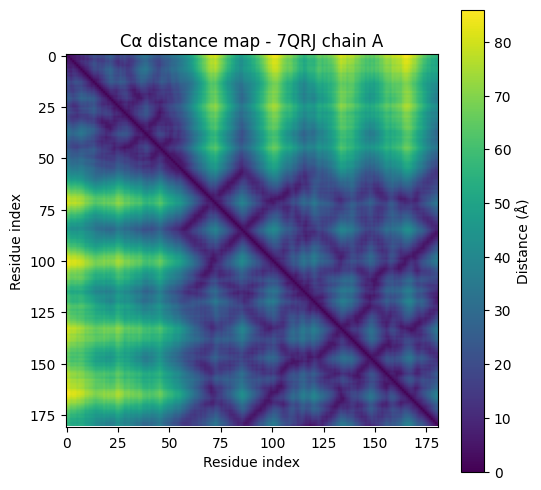

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

D = np.sqrt(((coords[:, None, :] - coords[None, :, :]) ** 2).sum(-1))

plt.figure(figsize=(6,6))
plt.imshow(D)
plt.colorbar(label="Distance (Å)")
plt.title("Cα distance map - 7QRJ chain A")
plt.xlabel("Residue index")
plt.ylabel("Residue index")
plt.show()

---

# Construir el Dataset

In [70]:
!pip install Bio

In [71]:
import json
from pathlib import Path
from typing import List, Dict, Optional, Tuple

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
from Bio.PDB.MMCIFParser import MMCIFParser
from Bio.SeqUtils import seq1
from difflib import SequenceMatcher
from Bio import Align

AA_VOCAB = {
    "-": 0,
    "A": 1, "R": 2, "N": 3, "D": 4, "C": 5,
    "Q": 6, "E": 7, "G": 8, "H": 9, "I": 10,
    "L": 11, "K": 12, "M": 13, "F": 14, "P": 15,
    "S": 16, "T": 17, "W": 18, "Y": 19, "V": 20,
    "X": 21, "B": 22, "Z": 23, "U": 24, "O": 25,
    ".": 26}

UNK_TOKEN = AA_VOCAB["X"]


def tokenize_sequence(seq: str) -> torch.Tensor:
    return torch.tensor([AA_VOCAB.get(ch.upper(), UNK_TOKEN) for ch in seq], dtype=torch.long)


def read_a3m(a3m_path: Path, max_msa_seqs: Optional[int] = None) -> List[str]:
    seqs = []
    with open(a3m_path, "r") as f:
        current_name = None
        current_seq = []
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if current_name is not None:
                    seq = "".join(current_seq)
                    seq = "".join([c for c in seq if not c.islower()])
                    seqs.append(seq)
                    if max_msa_seqs is not None and len(seqs) >= max_msa_seqs:
                        break
                current_name = line[1:]
                current_seq = []
            else:
                current_seq.append(line)

        if (max_msa_seqs is None or len(seqs) < max_msa_seqs) and current_name is not None:
            seq = "".join(current_seq)
            seq = "".join([c for c in seq if not c.islower()])
            seqs.append(seq)

    return seqs


def pad_or_crop_msa(msa_seqs: List[str], target_len: int, max_msa_seqs: int) -> List[str]:
    msa_seqs = msa_seqs[:max_msa_seqs]
    fixed = []

    for s in msa_seqs:
        if len(s) < target_len:
            s = s + "-" * (target_len - len(s))
        elif len(s) > target_len:
            s = s[:target_len]
        fixed.append(s)

    if len(fixed) == 0:
        fixed = ["-" * target_len]

    return fixed


def tokenize_msa(msa_seqs: List[str]) -> torch.Tensor:
    return torch.stack([tokenize_sequence(s) for s in msa_seqs], dim=0)


def safe_residue_to_aa(residue) -> str:
    resname = residue.get_resname().strip()
    try:
        aa = seq1(resname)
        if len(aa) == 1:
            return aa
    except Exception:
        pass
    return "X"


def extract_chain_sequences_and_backbone(cif_path: Path) -> Dict[str, Dict]:
    """
    Extract per-chain sequence plus backbone atom coordinates (N, CA, C).

    Returns
    -------
    out[chain_id] = {
        "sequence": str,
        "coords_n":  np.ndarray [L, 3],
        "coords_ca": np.ndarray [L, 3],
        "coords_c":  np.ndarray [L, 3],
    }

    Notes
    -----
    - One row per polymer residue.
    - Missing atoms are filled with NaN.
    - Hetero residues are skipped.
    """
    parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure(cif_path.stem, str(cif_path))

    out = {}
    first_model = next(structure.get_models())

    for chain in first_model:
        seq_chars = []
        coords_n = []
        coords_ca = []
        coords_c = []

        for residue in chain:
            hetflag = residue.id[0]
            if hetflag.strip() != "":
                continue

            aa = safe_residue_to_aa(residue)
            seq_chars.append(aa)

            if "N" in residue:
                coords_n.append(residue["N"].coord)
            else:
                coords_n.append([np.nan, np.nan, np.nan])

            if "CA" in residue:
                coords_ca.append(residue["CA"].coord)
            else:
                coords_ca.append([np.nan, np.nan, np.nan])

            if "C" in residue:
                coords_c.append(residue["C"].coord)
            else:
                coords_c.append([np.nan, np.nan, np.nan])

        if len(seq_chars) == 0:
            continue

        out[chain.id] = {
            "sequence": "".join(seq_chars),
            "coords_n": np.array(coords_n, dtype=np.float32),
            "coords_ca": np.array(coords_ca, dtype=np.float32),
            "coords_c": np.array(coords_c, dtype=np.float32)}

    return out



def sequence_identity(a: str, b: str) -> float:
    return SequenceMatcher(None, a, b).ratio()


def match_target_to_chain(
    target_seq: str,
    chain_data: Dict[str, Dict],
    min_identity: float = 0.85, ) -> Optional[Tuple[str, float]]:

    aligner = Align.PairwiseAligner()
    aligner.mode = 'local' # Fundamental para ignorar los gaps por missing data

    best_chain = None
    best_score = -1.0

    for chain_id, info in chain_data.items():
        chain_seq = info["sequence"]
        if len(chain_seq) == 0:
            continue

        score = aligner.score(target_seq, chain_seq)

        # Normalizamos por la longitud de la secuencia que encontramos en el CIF
        coverage = score / len(chain_seq)

        if coverage > best_score:
            best_score = coverage
            best_chain = chain_id

    if best_chain is None or best_score < min_identity:
        return None

    return best_chain, best_score


def pairwise_distances(coords: torch.Tensor) -> torch.Tensor:
    diff = coords[:, None, :] - coords[None, :, :]
    return torch.sqrt(torch.sum(diff**2, dim=-1) + 1e-8)


class FoldbenchProteinDataset(Dataset):
    def __init__(
        self,
        json_path: str,
        msa_root: str,
        cif_root: str,
        max_msa_seqs: int = 128,
        use_a3m_name: str = "cfdb_hits.a3m",
        max_samples: Optional[int] = None,
        min_identity: float = 0.90,
        verbose: bool = True,
    ):
        self.json_path = Path(json_path)
        self.msa_root = Path(msa_root)
        self.cif_root = Path(cif_root)
        self.max_msa_seqs = max_msa_seqs
        self.use_a3m_name = use_a3m_name
        self.min_identity = min_identity

        with open(self.json_path, "r") as f:
            data = json.load(f)

        rows = []
        dropped = []

        for qname, q in data["queries"].items():
            chain = q["chains"][0]
            target_seq = chain["sequence"]

            chosen_chain_for_msa = None
            for cid in chain["chain_ids"]:
                if isinstance(cid, str) and len(cid) == 1 and cid.isalpha():
                    chosen_chain_for_msa = cid
                    break

            if chosen_chain_for_msa is None:
                dropped.append((qname, "no_valid_chain_id_in_json"))
                continue

            msa_dir_name = f"{qname.lower()}_{chosen_chain_for_msa}"
            msa_file = self.msa_root / msa_dir_name / self.use_a3m_name

            cif_candidates = list(self.cif_root.glob(f"{qname.lower()}-assembly1_*.cif"))
            if len(cif_candidates) == 0:
                dropped.append((qname, "no_cif"))
                continue
            cif_file = cif_candidates[0]

            if not msa_file.exists():
                dropped.append((qname, "no_msa"))
                continue

            try:
                chain_data = extract_chain_sequences_and_backbone(cif_file)
                match = match_target_to_chain(
                    target_seq=target_seq,
                    chain_data=chain_data,
                    min_identity=self.min_identity,
                )
            except Exception as e:
                dropped.append((qname, f"parse_error:{str(e)}"))
                continue

            if match is None:
                dropped.append((qname, "no_chain_match"))
                continue

            matched_chain_id, match_identity = match
            matched_seq = chain_data[matched_chain_id]["sequence"]

            rows.append({
                "query_name": qname,
                "target_sequence": target_seq,
                "msa_chain_id": chosen_chain_for_msa,
                "matched_chain_id": matched_chain_id,
                "match_identity": match_identity,
                "matched_chain_sequence": matched_seq,
                "msa_file": str(msa_file),
                "cif_file": str(cif_file),
            })

        if max_samples is not None:
            rows = rows[:max_samples]

        self.df = pd.DataFrame(rows).reset_index(drop=True)
        self.dropped = dropped

        if verbose:
            print(f"Dataset valid examples: {len(self.df)}")
            print(f"Dropped examples: {len(self.dropped)}")
            if len(self.df) > 0:
                print(self.df[["query_name", "msa_chain_id", "matched_chain_id", "match_identity"]].head())

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]

        query_name = row["query_name"]
        target_sequence = row["target_sequence"]
        matched_chain_id = row["matched_chain_id"]
        msa_file = Path(row["msa_file"])
        cif_file = Path(row["cif_file"])

        seq_tokens = tokenize_sequence(target_sequence)

        msa_seqs = read_a3m(msa_file, max_msa_seqs=self.max_msa_seqs)
        msa_seqs = pad_or_crop_msa(
            msa_seqs,
            target_len=len(target_sequence),
            max_msa_seqs=self.max_msa_seqs
        )
        msa_tokens = tokenize_msa(msa_seqs)
        msa_mask = (msa_tokens != AA_VOCAB["-"]).float()

        chain_data = extract_chain_sequences_and_backbone(cif_file)

        coords_n_np  = chain_data[matched_chain_id]["coords_n"]
        coords_ca_np = chain_data[matched_chain_id]["coords_ca"]
        coords_c_np  = chain_data[matched_chain_id]["coords_c"]

        # máscaras antes de reemplazar NaNs
        valid_n  = ~np.isnan(coords_n_np).any(axis=1)
        valid_ca = ~np.isnan(coords_ca_np).any(axis=1)
        valid_c  = ~np.isnan(coords_c_np).any(axis=1)

        valid_res_mask = torch.tensor(valid_ca, dtype=torch.float32)
        valid_backbone_mask = torch.tensor(valid_n & valid_ca & valid_c, dtype=torch.float32)

        # reemplazar NaNs por 0 para evitar NaNs en PyTorch
        coords_n_np  = np.nan_to_num(coords_n_np, nan=0.0)
        coords_ca_np = np.nan_to_num(coords_ca_np, nan=0.0)
        coords_c_np  = np.nan_to_num(coords_c_np, nan=0.0)

        coords_n  = torch.tensor(coords_n_np, dtype=torch.float32)
        coords_ca = torch.tensor(coords_ca_np, dtype=torch.float32)
        coords_c  = torch.tensor(coords_c_np, dtype=torch.float32)

        L = min(
            len(seq_tokens),
            coords_ca.shape[0],
            coords_n.shape[0],
            coords_c.shape[0],
            msa_tokens.shape[1]
        )

        seq_tokens = seq_tokens[:L]
        msa_tokens = msa_tokens[:, :L]
        msa_mask = msa_mask[:, :L]

        coords_n = coords_n[:L]
        coords_ca = coords_ca[:L]
        coords_c = coords_c[:L]

        valid_res_mask = valid_res_mask[:L]
        valid_backbone_mask = valid_backbone_mask[:L]

        dist_map = pairwise_distances(coords_ca)

        return {
            "id": query_name,
            "msa_chain_id": row["msa_chain_id"],
            "matched_chain_id": matched_chain_id,
            "match_identity": torch.tensor(row["match_identity"], dtype=torch.float32),
            "sequence_str": target_sequence[:L],
            "seq_tokens": seq_tokens,
            "msa_tokens": msa_tokens,
            "msa_mask": msa_mask,
            "coords_n": coords_n,                       # [L,3]
            "coords_ca": coords_ca,                     # [L,3]
            "coords_c": coords_c,                       # [L,3]
            "dist_map": dist_map,                       # [L,L]
            "valid_res_mask": valid_res_mask,           # [L]
            "valid_backbone_mask": valid_backbone_mask, # [L]
        }

In [72]:
def collate_proteins(batch):
    B = len(batch)
    max_L = max(item["seq_tokens"].shape[0] for item in batch)
    max_Nmsa = max(item["msa_tokens"].shape[0] for item in batch)

    seq_pad_token = AA_VOCAB["-"]
    msa_pad_token = AA_VOCAB["-"]

    seq_tokens = torch.full((B, max_L), seq_pad_token, dtype=torch.long)
    seq_mask = torch.zeros((B, max_L), dtype=torch.float32)

    msa_tokens = torch.full((B, max_Nmsa, max_L), msa_pad_token, dtype=torch.long)
    msa_mask = torch.zeros((B, max_Nmsa, max_L), dtype=torch.float32)

    coords_n = torch.zeros((B, max_L, 3), dtype=torch.float32)
    coords_ca = torch.zeros((B, max_L, 3), dtype=torch.float32)
    coords_c = torch.zeros((B, max_L, 3), dtype=torch.float32)

    valid_res_mask = torch.zeros((B, max_L), dtype=torch.float32)
    valid_backbone_mask = torch.zeros((B, max_L), dtype=torch.float32)

    dist_map = torch.zeros((B, max_L, max_L), dtype=torch.float32)
    pair_mask = torch.zeros((B, max_L, max_L), dtype=torch.float32)
    backbone_pair_mask = torch.zeros((B, max_L, max_L), dtype=torch.float32)

    ids = []
    msa_chain_ids = []
    matched_chain_ids = []
    sequence_strs = []
    match_identity = torch.zeros(B, dtype=torch.float32)

    for i, item in enumerate(batch):
        L = item["seq_tokens"].shape[0]
        N = item["msa_tokens"].shape[0]

        seq_tokens[i, :L] = item["seq_tokens"]
        seq_mask[i, :L] = 1.0

        msa_tokens[i, :N, :L] = item["msa_tokens"]
        msa_mask[i, :N, :L] = item["msa_mask"]

        coords_n[i, :L] = item["coords_n"]
        coords_ca[i, :L] = item["coords_ca"]
        coords_c[i, :L] = item["coords_c"]

        valid_res_mask[i, :L] = item["valid_res_mask"]
        valid_backbone_mask[i, :L] = item["valid_backbone_mask"]

        dist_map[i, :L, :L] = item["dist_map"]

        # pair mask basada en residuos con CA válido
        pair_mask[i, :L, :L] = (
            item["valid_res_mask"][:, None] * item["valid_res_mask"][None, :]
        )

        # pair mask basada en residuos con backbone completo (N, CA, C)
        backbone_pair_mask[i, :L, :L] = (
            item["valid_backbone_mask"][:, None] * item["valid_backbone_mask"][None, :]
        )

        ids.append(item["id"])
        msa_chain_ids.append(item["msa_chain_id"])
        matched_chain_ids.append(item["matched_chain_id"])
        sequence_strs.append(item["sequence_str"])
        match_identity[i] = item["match_identity"]

    return {
        "id": ids,
        "msa_chain_id": msa_chain_ids,
        "matched_chain_id": matched_chain_ids,
        "match_identity": match_identity,
        "sequence_str": sequence_strs,
        "seq_tokens": seq_tokens,                     # [B, L]
        "seq_mask": seq_mask,                         # [B, L]
        "msa_tokens": msa_tokens,                     # [B, N_msa, L]
        "msa_mask": msa_mask,                         # [B, N_msa, L]
        "coords_n": coords_n,                         # [B, L, 3]
        "coords_ca": coords_ca,                       # [B, L, 3]
        "coords_c": coords_c,                         # [B, L, 3]
        "dist_map": dist_map,                         # [B, L, L]
        "valid_res_mask": valid_res_mask,             # [B, L]
        "valid_backbone_mask": valid_backbone_mask,   # [B, L]
        "pair_mask": pair_mask,                       # [B, L, L]
        "backbone_pair_mask": backbone_pair_mask,     # [B, L, L]
    }

In [73]:
dataset = FoldbenchProteinDataset(
    json_path="/content/af_subset/jsons/fb_protein.json",
    msa_root="/content/af_subset/foldbench_msas",
    cif_root="/content/af_subset/reference_structures",
    max_msa_seqs=128,
    min_identity=0.85,
    verbose=True,)

print("N ejemplos finales:", len(dataset))
print("Primeros descartados:", dataset.dropped[:10])

sample = dataset[0]
for k, v in sample.items():
    if torch.is_tensor(v):
        print(k, v.shape, v.dtype)
    else:
        print(k, type(v), v)

Dataset valid examples: 39
Dropped examples: 200
  query_name msa_chain_id matched_chain_id  match_identity
0       7QRJ            A                A        1.000000
1       7QRR            A                F        1.000000
2       7QUV            A                B        1.000000
3       7SPQ            A                A        1.000000
4       7TH0            A                A        0.953488
N ejemplos finales: 39
Primeros descartados: [('7QWE', 'no_msa'), ('7XPT', 'no_msa'), ('7XVQ', 'no_msa'), ('7Y37', 'no_chain_match'), ('7YLS', 'no_msa'), ('7YUL', 'no_msa'), ('7ZOP', 'no_msa'), ('8A51', 'no_msa'), ('8AMY', 'no_msa'), ('8AN5', 'no_msa')]
id <class 'str'> 7QRJ
msa_chain_id <class 'str'> A
matched_chain_id <class 'str'> A
match_identity torch.Size([]) torch.float32
sequence_str <class 'str'> MSISSLLEKNIYNVHNKSNTLTNVPANPTGNTNTVWSNSNFTPPHLMYGASDITQAIGNISLTTGSFSLSLSGPWASPLVQNVAYTKINNLVNLTFPPFQANATSSAVINSAIGALPADLRPTTNIQVDFEIFVIDDGNRPVNPGLITLLSNGQIVVYKDNNLGQFTTGIGGSGFNPFSIT
seq_to

In [74]:
from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_proteins)

batch = next(iter(loader))

for k, v in batch.items():
    if torch.is_tensor(v):
        print(k, v.shape, v.dtype)
    else:
        print(k, type(v))

id <class 'list'>
msa_chain_id <class 'list'>
matched_chain_id <class 'list'>
match_identity torch.Size([2]) torch.float32
sequence_str <class 'list'>
seq_tokens torch.Size([2, 194]) torch.int64
seq_mask torch.Size([2, 194]) torch.float32
msa_tokens torch.Size([2, 128, 194]) torch.int64
msa_mask torch.Size([2, 128, 194]) torch.float32
coords_n torch.Size([2, 194, 3]) torch.float32
coords_ca torch.Size([2, 194, 3]) torch.float32
coords_c torch.Size([2, 194, 3]) torch.float32
dist_map torch.Size([2, 194, 194]) torch.float32
valid_res_mask torch.Size([2, 194]) torch.float32
valid_backbone_mask torch.Size([2, 194]) torch.float32
pair_mask torch.Size([2, 194, 194]) torch.float32
backbone_pair_mask torch.Size([2, 194, 194]) torch.float32


In [18]:
dataset.df["match_identity"].describe()

,match_identity
count,39.000000
mean,0.991809
std,0.023664
min,0.875000
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


In [19]:
dataset.df[["query_name", "msa_chain_id", "matched_chain_id", "match_identity"]].head(20)

,query_name,msa_chain_id,matched_chain_id,match_identity
0,7QRJ,A,A,1.000000
1,7QRR,A,F,1.000000
2,7QUV,A,B,1.000000
3,7SPQ,A,A,1.000000
4,7TH0,A,A,0.953488
5,7TXY,A,A,1.000000
6,7UQ2,A,A,1.000000
7,7VUB,A,A,1.000000
8,7WR3,A,A,0.989924
9,7X36,A,A,1.000000


---

# Arquitectura de AlphaFold

In [75]:
import torch
import torch.nn as nn


class InputEmbedder(nn.Module):
    """
    Canonical AlphaFold2-style input embedder.

    Inputs:
        seq_tokens : [B, L]
        msa_tokens : [B, N_msa, L]
        seq_mask   : [B, L]          (optional)
        msa_mask   : [B, N_msa, L]   (optional)

    Outputs:
        m : [B, N_msa, L, c_m]       initial MSA representation
        z : [B, L, L, c_z]           initial pair representation
    """

    def __init__(
        self,
        n_tokens: int,
        c_m: int = 256,
        c_z: int = 128,
        c_s: int = 256,
        max_relpos: int = 32,
        pad_idx: int = 0):

        super().__init__()

        self.c_m = c_m
        self.c_z = c_z
        self.c_s = c_s
        self.max_relpos = max_relpos

        # Token embeddings
        self.target_embedding = nn.Embedding(n_tokens, c_s, padding_idx=pad_idx)
        self.msa_embedding = nn.Embedding(n_tokens, c_m, padding_idx=pad_idx)

        # Project target sequence into MSA channel space
        self.target_to_msa = nn.Linear(c_s, c_m)

        # Pair initialization from target sequence
        self.left_single = nn.Linear(c_s, c_z)
        self.right_single = nn.Linear(c_s, c_z)

        # Relative positional encoding for pair representation
        self.relpos_embedding = nn.Embedding(2 * max_relpos + 1, c_z)

        self.m_ln = nn.LayerNorm(c_m)
        self.z_ln = nn.LayerNorm(c_z)

    def _make_relpos(self, L: int, device: torch.device):
        idx = torch.arange(L, device=device)
        rel = idx[:, None] - idx[None, :]  # [L, L]
        rel = torch.clamp(rel, -self.max_relpos, self.max_relpos)
        rel = rel + self.max_relpos
        return rel

    def forward(
        self,
        seq_tokens: torch.Tensor,
        msa_tokens: torch.Tensor,
        seq_mask: torch.Tensor = None,
        msa_mask: torch.Tensor = None):

        B, N_msa, L = msa_tokens.shape
        device = msa_tokens.device

        # Target sequence embedding
        # s: [B, L, c_s]
        s = self.target_embedding(seq_tokens)

        # Initial MSA representation
        # m token embedding + target injection
        m = self.msa_embedding(msa_tokens)
        target_bias = self.target_to_msa(s)
        m = m + target_bias[:, None, :, :]

        m = self.m_ln(m)

        if msa_mask is not None:
            m = m * msa_mask.unsqueeze(-1)

        # Initial pair representation
        # z_ij = W_a s_i + W_b s_j + relpos(i-j)
        left = self.left_single(s)
        right = self.right_single(s)

        z = left[:, :, None, :] + right[:, None, :, :]

        relpos = self._make_relpos(L, device)
        relpos_emb = self.relpos_embedding(relpos)
        z = z + relpos_emb[None, :, :, :]

        z = self.z_ln(z)

        if seq_mask is not None:
            pair_mask = seq_mask[:, :, None] * seq_mask[:, None, :]  # [B, L, L]
            z = z * pair_mask.unsqueeze(-1)

        return m, z

In [21]:

def test_input_embedder_shapes():

    B = 2
    N_msa = 128
    L = 275
    n_tokens = 23
    pad_idx = 0

    seq_tokens = torch.randint(1, n_tokens, (B, L))
    msa_tokens = torch.randint(1, n_tokens, (B, N_msa, L))

    seq_mask = torch.ones(B, L, dtype=torch.float32)
    msa_mask = torch.ones(B, N_msa, L, dtype=torch.float32)

    # meter algunos pads para probar mask
    seq_tokens[0, -10:] = pad_idx
    seq_mask[0, -10:] = 0.0

    msa_tokens[0, :, -10:] = pad_idx
    msa_mask[0, :, -10:] = 0.0

    model = InputEmbedder(
        n_tokens=n_tokens,
        c_m=256,
        c_z=128,
        c_s=256,
        max_relpos=32,
        pad_idx=pad_idx,
        max_len=512,)

    m, z = model(
        seq_tokens=seq_tokens,
        msa_tokens=msa_tokens,
        seq_mask=seq_mask,
        msa_mask=msa_mask,)

    # --------------------------
    # shape checks
    # --------------------------
    assert m.shape == (B, N_msa, L, 256), f"m shape incorrect: {m.shape}"
    assert z.shape == (B, L, L, 128), f"z shape incorrect: {z.shape}"

    # --------------------------
    # finiteness
    # --------------------------
    assert torch.isfinite(m).all(), "m has non-finite values"
    assert torch.isfinite(z).all(), "z has non-finite values"

    # --------------------------
    # masked positions ~ zero
    # --------------------------
    assert torch.allclose(
        m[0, :, -10:, :],
        torch.zeros_like(m[0, :, -10:, :]),
        atol=1e-5
    ), "MSA masked positions are not zeroed"

    assert torch.allclose(
        z[0, -10:, :, :],
        torch.zeros_like(z[0, -10:, :, :]),
        atol=1e-5
    ), "Pair masked rows are not zeroed"

    assert torch.allclose(
        z[0, :, -10:, :],
        torch.zeros_like(z[0, :, -10:, :]),
        atol=1e-5
    ), "Pair masked cols are not zeroed"

    print("OK: InputEmbedder passed shape and mask tests.")
    print("m shape:", m.shape)
    print("z shape:", z.shape)

m shape: torch.Size([2, 128, 275, 256])
z shape: torch.Size([2, 275, 275, 128])


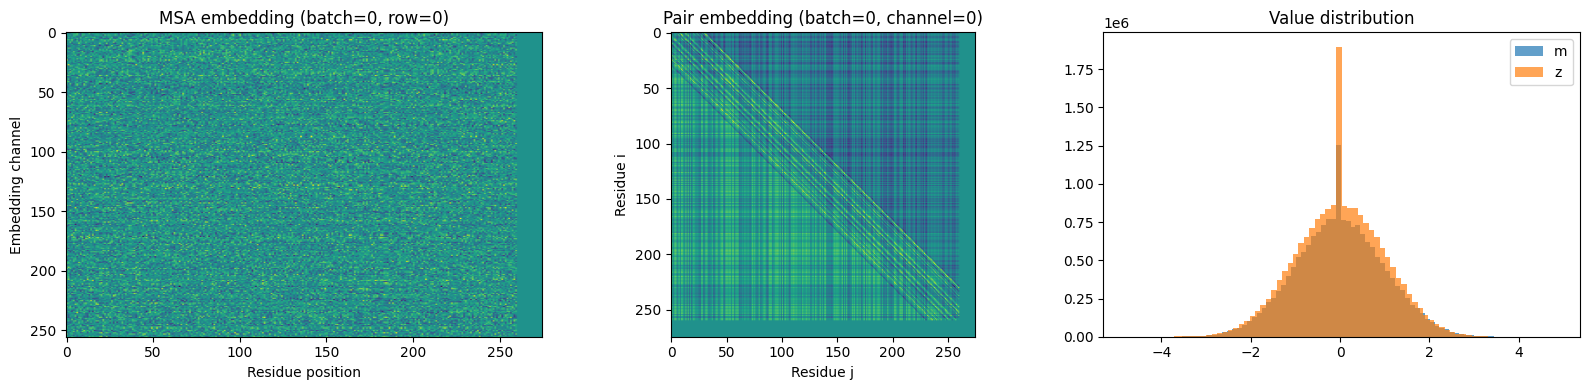

In [ ]:
import torch
import matplotlib.pyplot as plt

# -------------------------
# fake batch
# -------------------------
B = 2
N_msa = 128
L = 275
n_tokens = 23
pad_idx = 0

seq_tokens = torch.randint(1, n_tokens, (B, L))
msa_tokens = torch.randint(1, n_tokens, (B, N_msa, L))

seq_mask = torch.ones(B, L, dtype=torch.float32)
msa_mask = torch.ones(B, N_msa, L, dtype=torch.float32)

# algunos pads
seq_tokens[0, -15:] = pad_idx
seq_mask[0, -15:] = 0.0
msa_tokens[0, :, -15:] = pad_idx
msa_mask[0, :, -15:] = 0.0

model = InputEmbedder(
    n_tokens=n_tokens,
    c_m=256,
    c_z=128,
    c_s=256,
    max_relpos=32,
    pad_idx=pad_idx)

with torch.no_grad():
    m, z = model(
        seq_tokens=seq_tokens,
        msa_tokens=msa_tokens,
        seq_mask=seq_mask,
        msa_mask=msa_mask)

print("m shape:", m.shape)   # [B, N_msa, L, c_m]
print("z shape:", z.shape)   # [B, L, L, c_z]


b = 0
msa_row = 0
z_channel = 0

m_img = m[b, msa_row].cpu()          # [L, c_m]
z_img = z[b, :, :, z_channel].cpu()  # [L, L]

plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
plt.imshow(m_img.T, aspect='auto')
plt.title(f"MSA embedding (batch={b}, row={msa_row})")
plt.xlabel("Residue position")
plt.ylabel("Embedding channel")

plt.subplot(1, 3, 2)
plt.imshow(z_img)
plt.title(f"Pair embedding (batch={b}, channel={z_channel})")
plt.xlabel("Residue j")
plt.ylabel("Residue i")

plt.subplot(1, 3, 3)
plt.hist(m.flatten().cpu().numpy(), bins=80, alpha=0.7, label="m")
plt.hist(z.flatten().cpu().numpy(), bins=80, alpha=0.7, label="z")
plt.title("Value distribution")
plt.legend()

plt.tight_layout()
plt.show()

In [76]:
import torch
import torch.nn as nn

class OuterProductMean(nn.Module):
    """
    AlphaFold2-style Outer Product Mean.

    Input:
        m:        [B, N_msa, L, c_m]
        msa_mask: [B, N_msa, L]   (optional)

    Output:
        z_update: [B, L, L, c_z]
    """

    def __init__(self, c_m=256, c_hidden=32, c_z=128):
        super().__init__()

        self.layer_norm = nn.LayerNorm(c_m)

        self.linear_a = nn.Linear(c_m, c_hidden)
        self.linear_b = nn.Linear(c_m, c_hidden)

        self.output_linear = nn.Linear(c_hidden * c_hidden, c_z)

    def forward(self, m, msa_mask=None):
        """
        m: [B, N, L, c_m]
        msa_mask: [B, N, L]
        """
        B, N, L, _ = m.shape

        m = self.layer_norm(m)

        a = self.linear_a(m)   # [B, N, L, c_hidden]
        b = self.linear_b(m)   # [B, N, L, c_hidden]

        if msa_mask is not None:
            mask = msa_mask.unsqueeze(-1)   # [B, N, L, 1]
            a = a * mask
            b = b * mask

        # Outer product mean over MSA dimension N
        # result: [B, L, L, c_hidden, c_hidden]
        outer = torch.einsum('bnic,bnjd->bijcd', a, b)

        if msa_mask is not None:
            # solo promedia secuencias válidas para el par (i,j)
            pair_mask = torch.einsum('bni,bnj->bij', msa_mask, msa_mask)  # [B, L, L]
            outer = outer / (pair_mask[..., None, None] + 1e-8)
        else:
            outer = outer / N

        outer = outer.reshape(B, L, L, -1)
        z_update = self.output_linear(outer)

        return z_update

In [ ]:
B, N, L, c_m = 2, 128, 275, 256
c_hidden, c_z = 32, 128

m = torch.randn(B, N, L, c_m)
msa_mask = torch.ones(B, N, L)

opm = OuterProductMean(c_m=c_m, c_hidden=c_hidden, c_z=c_z)
z_update = opm(m, msa_mask)

print("z_update shape:", z_update.shape)  # [B, L, L, c_z]

z_update shape: torch.Size([2, 275, 275, 128])


In [ ]:
with torch.no_grad():
    m, z = model(
        seq_tokens=seq_tokens,
        msa_tokens=msa_tokens,
        seq_mask=seq_mask,
        msa_mask=msa_mask,)

opm = OuterProductMean(c_m=256, c_hidden=32, c_z=128)
z_update = opm(m, msa_mask)

print("m:", m.shape)
print("z:", z.shape)
print("z_update:", z_update.shape)

z = z + z_update
print("z after update:", z.shape)

m: torch.Size([2, 128, 275, 256])
z: torch.Size([2, 275, 275, 128])
z_update: torch.Size([2, 275, 275, 128])
z after update: torch.Size([2, 275, 275, 128])


In [77]:
import torch
import torch.nn as nn

import math
import torch
import torch.nn as nn


class TriangleMultiplicationOutgoing(nn.Module):
    """
    AlphaFold2-style Triangle Multiplicative Update (Outgoing).

    Input:
        z:         [B, L, L, c_z]
        pair_mask: [B, L, L]   (optional)

    Output:
        z_update:  [B, L, L, c_z]
    """

    def __init__(self, c_z=128, c_hidden=128, dropout=0.1, eps=1e-8):
        super().__init__()

        self.c_hidden = c_hidden
        self.eps = eps

        self.input_layer_norm = nn.LayerNorm(c_z)

        self.linear_a_p = nn.Linear(c_z, c_hidden)
        self.linear_b_p = nn.Linear(c_z, c_hidden)

        self.linear_a_g = nn.Linear(c_z, c_hidden)
        self.linear_b_g = nn.Linear(c_z, c_hidden)

        self.output_layer_norm = nn.LayerNorm(c_hidden)
        self.output_linear = nn.Linear(c_hidden, c_z)
        self.output_gate = nn.Linear(c_z, c_z)

        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(dropout)

    def forward(self, z, pair_mask=None):
        """
        z: [B, L, L, c_z]
        pair_mask: [B, L, L]
        """
        z_norm = self.input_layer_norm(z)

        a = self.linear_a_p(z_norm) * self.sigmoid(self.linear_a_g(z_norm))
        b = self.linear_b_p(z_norm) * self.sigmoid(self.linear_b_g(z_norm))

        if pair_mask is not None:
            mask = pair_mask.unsqueeze(-1).to(z.dtype)
            a = a * mask
            b = b * mask

        # outgoing: aggregate through k using (i,k) and (j,k)
        # x[b,i,j,c] = sum_k a[b,i,k,c] * b[b,j,k,c]
        x = torch.einsum("bikc,bjkc->bijc", a, b)

        # normalize by effective number of valid k's
        if pair_mask is not None:
            valid_k = torch.einsum("bik,bjk->bij", pair_mask, pair_mask).to(z.dtype)
            x = x / torch.sqrt(valid_k.unsqueeze(-1).clamp_min(1.0))
        else:
            L = z.shape[1]
            x = x / math.sqrt(L)

        x = self.output_layer_norm(x)
        x = self.output_linear(x)

        gate = self.sigmoid(self.output_gate(z_norm))
        x = x * gate
        x = self.dropout(x)

        if pair_mask is not None:
            x = x * pair_mask.unsqueeze(-1).to(z.dtype)

        return x


class TriangleMultiplicationIncoming(nn.Module):
    """
    AlphaFold2-style Triangle Multiplicative Update (Incoming).

    Input:
        z:         [B, L, L, c_z]
        pair_mask: [B, L, L]   (optional)

    Output:
        z_update:  [B, L, L, c_z]
    """

    def __init__(self, c_z=128, c_hidden=128, dropout=0.1, eps=1e-8):
        super().__init__()

        self.c_hidden = c_hidden
        self.eps = eps

        self.input_layer_norm = nn.LayerNorm(c_z)

        self.linear_a_p = nn.Linear(c_z, c_hidden)
        self.linear_b_p = nn.Linear(c_z, c_hidden)

        self.linear_a_g = nn.Linear(c_z, c_hidden)
        self.linear_b_g = nn.Linear(c_z, c_hidden)

        self.output_layer_norm = nn.LayerNorm(c_hidden)
        self.output_linear = nn.Linear(c_hidden, c_z)
        self.output_gate = nn.Linear(c_z, c_z)

        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(dropout)

    def forward(self, z, pair_mask=None):
        """
        z: [B, L, L, c_z]
        pair_mask: [B, L, L]
        """
        z_norm = self.input_layer_norm(z)

        a = self.linear_a_p(z_norm) * self.sigmoid(self.linear_a_g(z_norm))  # [B,L,L,c_h]
        b = self.linear_b_p(z_norm) * self.sigmoid(self.linear_b_g(z_norm))  # [B,L,L,c_h]

        if pair_mask is not None:
            mask = pair_mask.unsqueeze(-1).to(z.dtype)
            a = a * mask
            b = b * mask

        # incoming: aggregate through k using (k,i) and (k,j)
        # x[b,i,j,c] = sum_k a[b,k,i,c] * b[b,k,j,c]
        x = torch.einsum("bkic,bkjc->bijc", a, b)

        # normalize by effective number of valid k's
        if pair_mask is not None:
            valid_k = torch.einsum("bki,bkj->bij", pair_mask, pair_mask).to(z.dtype)
            x = x / torch.sqrt(valid_k.unsqueeze(-1).clamp_min(1.0))
        else:
            L = z.shape[1]
            x = x / math.sqrt(L)

        x = self.output_layer_norm(x)
        x = self.output_linear(x)

        gate = self.sigmoid(self.output_gate(z_norm))
        x = x * gate
        x = self.dropout(x)

        if pair_mask is not None:
            x = x * pair_mask.unsqueeze(-1).to(z.dtype)

        return x


In [ ]:
B, L, c_z = 2, 275, 128

z = torch.randn(B, L, L, c_z)
pair_mask = torch.ones(B, L, L)

tri_out = TriangleMultiplicationOutgoing(c_z=128, c_hidden=128)
z_update = tri_out(z, pair_mask)

print("z_update shape:", z_update.shape)   # [B, L, L, 128]

z_update shape: torch.Size([2, 275, 275, 128])


In [ ]:
B, L, c_z = 2, 275, 128

z = torch.randn(B, L, L, c_z)
pair_mask = torch.ones(B, L, L)

tri_in = TriangleMultiplicationIncoming(c_z=128, c_hidden=128)
z_update = tri_in(z, pair_mask)

print("z_update shape:", z_update.shape)   # [B, L, L, 128]

z_update shape: torch.Size([2, 275, 275, 128])


In [ ]:
with torch.no_grad():
    m, z = model(
        seq_tokens=seq_tokens,
        msa_tokens=msa_tokens,
        seq_mask=seq_mask,
        msa_mask=msa_mask,)

opm = OuterProductMean(c_m=256, c_hidden=32, c_z=128)
z = z + opm(m, msa_mask)

tri_out = TriangleMultiplicationOutgoing(c_z=128, c_hidden=128)
z = z + tri_out(z, pair_mask)

print("final z shape:", z.shape)

final z shape: torch.Size([2, 275, 275, 128])


# Atencion

In [78]:
import math
import torch
import torch.nn as nn


class TriangleAttentionStartingNode(nn.Module):
    """
    AlphaFold2-style Triangle Attention (Starting Node).

    Input:
        z:         [B, L, L, c_z]
        pair_mask: [B, L, L]   (optional)

    Output:
        z_update:  [B, L, L, c_z]

    Idea:
        For each fixed starting node i, attention is performed over k on z[i, k]
        to update z[i, j]. Equivalently, for each row i we do attention across
        the second residue index.
    """

    def __init__(self, c_z=128, num_heads=4, c_hidden=32):
        super().__init__()
        assert c_z == num_heads * c_hidden, "Require c_z = num_heads * c_hidden"

        self.c_z = c_z
        self.num_heads = num_heads
        self.c_hidden = c_hidden

        self.input_layer_norm = nn.LayerNorm(c_z)

        self.linear_q = nn.Linear(c_z, num_heads * c_hidden, bias=False)
        self.linear_k = nn.Linear(c_z, num_heads * c_hidden, bias=False)
        self.linear_v = nn.Linear(c_z, num_heads * c_hidden, bias=False)

        # pair bias per head
        self.linear_bias = nn.Linear(c_z, num_heads, bias=False)

        # gating
        self.linear_gate = nn.Linear(c_z, num_heads * c_hidden)

        self.output_linear = nn.Linear(num_heads * c_hidden, c_z)
        self.sigmoid = nn.Sigmoid()

    def forward(self, z, pair_mask=None):
        """
        z: [B, L, L, c_z]
        pair_mask: [B, L, L]
        """
        B, L, _, _ = z.shape
        z_norm = self.input_layer_norm(z)

        q = self.linear_q(z_norm).view(B, L, L, self.num_heads, self.c_hidden)
        k = self.linear_k(z_norm).view(B, L, L, self.num_heads, self.c_hidden)
        v = self.linear_v(z_norm).view(B, L, L, self.num_heads, self.c_hidden)

        bias = self.linear_bias(z_norm)

        # attention logits over k for each fixed (i, j)
        # q from z[i,j], keys from z[i,k]
        # result: [B, i, h, j, k]
        logits = torch.einsum("bijhc,bikhc->bihjk", q, k) / math.sqrt(self.c_hidden)

        # add pair bias from candidate key edge (i,k)
        key_bias = bias.permute(0, 1, 3, 2).unsqueeze(3)
        logits = logits + key_bias

        if pair_mask is not None:
            # key mask on (i,k)
            key_mask = pair_mask.unsqueeze(2).unsqueeze(3)
            logits = logits.masked_fill(key_mask == 0, -1e9)

        attn = torch.softmax(logits, dim=-1)  # over k

        # weighted sum of values z[i,k]
        # [B, i, j, h, c]
        out = torch.einsum("bihjk,bikhc->bijhc", attn, v)

        gate = self.sigmoid(self.linear_gate(z_norm)).view(B, L, L, self.num_heads, self.c_hidden)
        out = out * gate

        out = out.reshape(B, L, L, self.num_heads * self.c_hidden)
        out = self.output_linear(out)

        if pair_mask is not None:
            out = out * pair_mask.unsqueeze(-1)

        return out


class TriangleAttentionEndingNode(nn.Module):
    """
    AlphaFold2-style Triangle Attention (Ending Node).

    Input:
        z:         [B, L, L, c_z]
        pair_mask: [B, L, L]   (optional)

    Output:
        z_update:  [B, L, L, c_z]

    Idea:
        For each fixed ending node j, attention is performed over k on z[k, j]
        to update z[i, j].
    """

    def __init__(self, c_z=128, num_heads=4, c_hidden=32):
        super().__init__()
        assert c_z == num_heads * c_hidden, "Require c_z = num_heads * c_hidden"

        self.c_z = c_z
        self.num_heads = num_heads
        self.c_hidden = c_hidden

        self.input_layer_norm = nn.LayerNorm(c_z)

        self.linear_q = nn.Linear(c_z, num_heads * c_hidden, bias=False)
        self.linear_k = nn.Linear(c_z, num_heads * c_hidden, bias=False)
        self.linear_v = nn.Linear(c_z, num_heads * c_hidden, bias=False)

        self.linear_bias = nn.Linear(c_z, num_heads, bias=False)
        self.linear_gate = nn.Linear(c_z, num_heads * c_hidden)

        self.output_linear = nn.Linear(num_heads * c_hidden, c_z)
        self.sigmoid = nn.Sigmoid()

    def forward(self, z, pair_mask=None):
        """
        z: [B, L, L, c_z]
        pair_mask: [B, L, L]
        """
        B, L, _, _ = z.shape
        z_norm = self.input_layer_norm(z)

        q = self.linear_q(z_norm).view(B, L, L, self.num_heads, self.c_hidden)
        k = self.linear_k(z_norm).view(B, L, L, self.num_heads, self.c_hidden)
        v = self.linear_v(z_norm).view(B, L, L, self.num_heads, self.c_hidden)

        bias = self.linear_bias(z_norm)  # [B,i,j,h]

        # For each fixed j, query z[i,j] attends over keys z[k,j]
        # logits: [B, j, h, i, k]
        logits = torch.einsum("bijhc,bkjhc->bhijk", q, k) / math.sqrt(self.c_hidden)
        logits = logits.permute(0, 3, 1, 2, 4)  # [B, j, h, i, k]

        # bias from candidate key edge (k,j)
        key_bias = bias.permute(0, 2, 3, 1).unsqueeze(3)  # [B, j, h, 1, k]
        logits = logits + key_bias

        if pair_mask is not None:
            # mask over key edges (k,j)
            key_mask = pair_mask.transpose(1, 2).unsqueeze(2).unsqueeze(3)  # [B, j, 1, 1, k]
            logits = logits.masked_fill(key_mask == 0, -1e9)

        attn = torch.softmax(logits, dim=-1)  # over k

        # values are z[k,j]
        v_t = v.permute(0, 2, 1, 3, 4)  # [B, j, k, h, c]
        out = torch.einsum("bjhik,bjkhc->bijhc", attn, v_t)

        gate = self.sigmoid(self.linear_gate(z_norm)).view(B, L, L, self.num_heads, self.c_hidden)
        out = out * gate

        out = out.reshape(B, L, L, self.num_heads * self.c_hidden)
        out = self.output_linear(out)

        if pair_mask is not None:
            out = out * pair_mask.unsqueeze(-1)

        return out


In [ ]:
B, L, c_z = 2, 275, 128
z = torch.randn(B, L, L, c_z)
pair_mask = torch.ones(B, L, L)

tri_attn_start = TriangleAttentionStartingNode(c_z=128, num_heads=4, c_hidden=32)
z_update = tri_attn_start(z, pair_mask)

print("z_update shape:", z_update.shape)   # [B, L, L, 128]

z_update shape: torch.Size([2, 275, 275, 128])


In [ ]:
B, L, c_z = 2, 275, 128
z = torch.randn(B, L, L, c_z)
pair_mask = torch.ones(B, L, L)

tri_attn_end = TriangleAttentionEndingNode(c_z=128, num_heads=4, c_hidden=32)
z_update = tri_attn_end(z, pair_mask)

print("z_update shape:", z_update.shape)   # [B, L, L, 128]

z_update shape: torch.Size([2, 275, 275, 128])


In [ ]:
tri_attn_start = TriangleAttentionStartingNode(c_z=128, num_heads=4, c_hidden=32)
z = z + tri_attn_start(z, pair_mask)

print("z shape after starting-node attention:", z.shape)

z shape after starting-node attention: torch.Size([2, 275, 275, 128])


In [ ]:
tri_attn_end = TriangleAttentionEndingNode(c_z=128, num_heads=4, c_hidden=32)
z = z + tri_attn_end(z, pair_mask)

print("z shape after ending-node attention:", z.shape)

z shape after ending-node attention: torch.Size([2, 275, 275, 128])


In [79]:

class MSARowAttentionWithPairBias(nn.Module):
    """
    AlphaFold2-style MSA Row Attention with Pair Bias.

    Inputs:
        m:        [B, N, L, c_m]
        z:        [B, L, L, c_z]
        msa_mask: [B, N, L]   (optional)

    Output:
        m_update: [B, N, L, c_m]
    """

    def __init__(self, c_m=256, c_z=128, num_heads=8, c_hidden=32):
        super().__init__()
        assert c_m == num_heads * c_hidden, "Require c_m = num_heads * c_hidden"

        self.c_m = c_m
        self.c_z = c_z
        self.num_heads = num_heads
        self.c_hidden = c_hidden

        self.m_layer_norm = nn.LayerNorm(c_m)
        self.z_layer_norm = nn.LayerNorm(c_z)

        self.linear_q = nn.Linear(c_m, num_heads * c_hidden, bias=False)
        self.linear_k = nn.Linear(c_m, num_heads * c_hidden, bias=False)
        self.linear_v = nn.Linear(c_m, num_heads * c_hidden, bias=False)

        # pair bias added to logits before softmax
        self.linear_bias = nn.Linear(c_z, num_heads, bias=False)

        self.linear_gate = nn.Linear(c_m, num_heads * c_hidden)
        self.output_linear = nn.Linear(num_heads * c_hidden, c_m)

        self.sigmoid = nn.Sigmoid()

    def forward(self, m, z, msa_mask=None):
        """
        m: [B, N, L, c_m]
        z: [B, L, L, c_z]
        msa_mask: [B, N, L]
        """
        B, N, L, _ = m.shape

        m_norm = self.m_layer_norm(m)
        z_norm = self.z_layer_norm(z)

        q = self.linear_q(m_norm).view(B, N, L, self.num_heads, self.c_hidden)
        k = self.linear_k(m_norm).view(B, N, L, self.num_heads, self.c_hidden)
        v = self.linear_v(m_norm).view(B, N, L, self.num_heads, self.c_hidden)

        # [B, L, L, H]
        pair_bias = self.linear_bias(z_norm)

        # attention over residue positions j for each row n
        # logits: [B, N, H, I, J]
        logits = torch.einsum("bnihc,bnjhc->bnhij", q, k) / math.sqrt(self.c_hidden)

        # add pair bias before softmax
        logits = logits + pair_bias.permute(0, 3, 1, 2).unsqueeze(1)  # [B,1,H,I,J]

        if msa_mask is not None:
            key_mask = msa_mask.unsqueeze(2).unsqueeze(3)  # [B,N,1,1,L]
            logits = logits.masked_fill(key_mask == 0, -1e9)

        attn = torch.softmax(logits, dim=-1)

        out = torch.einsum("bnhij,bnjhc->bnihc", attn, v)

        gate = self.sigmoid(self.linear_gate(m_norm)).view(B, N, L, self.num_heads, self.c_hidden)
        out = out * gate

        out = out.reshape(B, N, L, self.num_heads * self.c_hidden)
        out = self.output_linear(out)

        if msa_mask is not None:
            out = out * msa_mask.unsqueeze(-1)

        return out


class MSAColumnAttention(nn.Module):
    """
    AlphaFold2-style MSA Column Attention.

    Inputs:
        m:        [B, N, L, c_m]
        msa_mask: [B, N, L]   (optional)

    Output:
        m_update: [B, N, L, c_m]
    """

    def __init__(self, c_m=256, num_heads=8, c_hidden=32):
        super().__init__()
        assert c_m == num_heads * c_hidden, "Require c_m = num_heads * c_hidden"

        self.c_m = c_m
        self.num_heads = num_heads
        self.c_hidden = c_hidden

        self.layer_norm = nn.LayerNorm(c_m)

        self.linear_q = nn.Linear(c_m, num_heads * c_hidden, bias=False)
        self.linear_k = nn.Linear(c_m, num_heads * c_hidden, bias=False)
        self.linear_v = nn.Linear(c_m, num_heads * c_hidden, bias=False)

        self.linear_gate = nn.Linear(c_m, num_heads * c_hidden)
        self.output_linear = nn.Linear(num_heads * c_hidden, c_m)

        self.sigmoid = nn.Sigmoid()

    def forward(self, m, msa_mask=None):
        """
        m: [B, N, L, c_m]
        msa_mask: [B, N, L]
        """
        B, N, L, _ = m.shape

        m_norm = self.layer_norm(m)

        q = self.linear_q(m_norm).view(B, N, L, self.num_heads, self.c_hidden)
        k = self.linear_k(m_norm).view(B, N, L, self.num_heads, self.c_hidden)
        v = self.linear_v(m_norm).view(B, N, L, self.num_heads, self.c_hidden)

        # attend over MSA sequences n for each residue position l
        # logits: [B, L, H, N_q, N_k]
        logits = torch.einsum("bnlhc,bmlhc->blhnm", q, k) / math.sqrt(self.c_hidden)

        if msa_mask is not None:
            key_mask = msa_mask.permute(0, 2, 1).unsqueeze(2).unsqueeze(3)  # [B,L,1,1,N]
            logits = logits.masked_fill(key_mask == 0, -1e9)

        attn = torch.softmax(logits, dim=-1)

        v_t = v.permute(0, 2, 1, 3, 4)  # [B, L, N, H, C]
        out = torch.einsum("blhnm,blmhc->bnlhc", attn, v_t)

        gate = self.sigmoid(self.linear_gate(m_norm)).view(B, N, L, self.num_heads, self.c_hidden)
        out = out * gate

        out = out.reshape(B, N, L, self.num_heads * self.c_hidden)
        out = self.output_linear(out)

        if msa_mask is not None:
            out = out * msa_mask.unsqueeze(-1)

        return out

In [ ]:
B, N, L = 2, 128, 275
c_m, c_z = 256, 128

m = torch.randn(B, N, L, c_m)
z = torch.randn(B, L, L, c_z)
msa_mask = torch.ones(B, N, L)

row_attn = MSARowAttentionWithPairBias(c_m=256, c_z=128, num_heads=8, c_hidden=32)
col_attn = MSAColumnAttention(c_m=256, num_heads=8, c_hidden=32)

m_row = row_attn(m, z, msa_mask)
m_col = col_attn(m, msa_mask)

print("m_row:", m_row.shape)  # [B, N, L, 256]
print("m_col:", m_col.shape)  # [B, N, L, 256]

m_row: torch.Size([2, 128, 275, 256])
m_col: torch.Size([2, 128, 275, 256])


# Evoformer Full


In [80]:
import torch
import torch.nn as nn


def zero_init_linear(linear: nn.Linear):
    nn.init.zeros_(linear.weight)
    if linear.bias is not None:
        nn.init.zeros_(linear.bias)


class MSATransition(nn.Module):
    def __init__(self, c_m=256, expansion=4):
        super().__init__()
        self.layer_norm = nn.LayerNorm(c_m)
        self.linear_1 = nn.Linear(c_m, expansion * c_m)
        self.act = nn.SiLU()
        self.linear_2 = nn.Linear(expansion * c_m, c_m)

        # zero-init final projection
        zero_init_linear(self.linear_2)

    def forward(self, m, msa_mask=None):
        x = self.layer_norm(m)
        x = self.linear_1(x)
        x = self.act(x)
        x = self.linear_2(x)

        if msa_mask is not None:
            x = x * msa_mask.unsqueeze(-1)
        return x

class PairTransition(nn.Module):
    def __init__(self, c_z=128, expansion=4):
        super().__init__()
        self.layer_norm = nn.LayerNorm(c_z)
        self.linear_1 = nn.Linear(c_z, expansion * c_z)
        self.act = nn.SiLU()
        self.linear_2 = nn.Linear(expansion * c_z, c_z)

        # zero-init final projection
        zero_init_linear(self.linear_2)

    def forward(self, z, pair_mask=None):
        x = self.layer_norm(z)
        x = self.linear_1(x)
        x = self.act(x)
        x = self.linear_2(x)

        if pair_mask is not None:
            x = x * pair_mask.unsqueeze(-1)
        return x


class EvoformerBlock(nn.Module):
    """
    Canonical AlphaFold2-style Evoformer block.

    Order:
      1) MSA Row Attention with Pair Bias   -> residual on m
      2) MSA Column Attention               -> residual on m
      3) MSA Transition                     -> residual on m
      4) Outer Product Mean                 -> residual on z
      5) Triangle Multiplication Outgoing   -> residual on z
      6) Triangle Multiplication Incoming   -> residual on z
      7) Triangle Attention Starting Node   -> residual on z
      8) Triangle Attention Ending Node     -> residual on z
      9) Pair Transition                    -> residual on z
    """

    def __init__(
        self,
        c_m=256,
        c_z=128,
        c_hidden_opm=32,
        c_hidden_tri_mul=128,
        num_heads_msa=8,
        num_heads_pair=4,
        c_hidden_msa_att=32,
        c_hidden_pair_att=32,
        transition_expansion=4,
        dropout=0.15):

        super().__init__()


        self.msa_row_attn = MSARowAttentionWithPairBias(
            c_m=c_m,
            c_z=c_z,
            num_heads=num_heads_msa,
            c_hidden=c_hidden_msa_att)

        self.msa_col_attn = MSAColumnAttention(
            c_m=c_m,
            num_heads=num_heads_msa,
            c_hidden=c_hidden_msa_att)

        self.msa_transition = MSATransition(
            c_m=c_m,
            expansion=transition_expansion,)

        self.outer_product_mean = OuterProductMean(
            c_m=c_m,
            c_hidden=c_hidden_opm,
            c_z=c_z,)

        self.tri_mul_out = TriangleMultiplicationOutgoing(
            c_z=c_z,
            c_hidden=c_hidden_tri_mul,)

        self.tri_mul_in = TriangleMultiplicationIncoming(
            c_z=c_z,
            c_hidden=c_hidden_tri_mul,)

        self.tri_attn_start = TriangleAttentionStartingNode(
            c_z=c_z,
            num_heads=num_heads_pair,
            c_hidden=c_hidden_pair_att,)

        self.tri_attn_end = TriangleAttentionEndingNode(
            c_z=c_z,
            num_heads=num_heads_pair,
            c_hidden=c_hidden_pair_att,)

        self.pair_transition = PairTransition(
            c_z=c_z,
            expansion=transition_expansion,)

        self.dropout = nn.Dropout(dropout)

        self._zero_init_residual_projections()

    def _zero_init_residual_projections(self):
        # final residual projections in each submodule
        zero_init_linear(self.msa_row_attn.output_linear)
        zero_init_linear(self.msa_col_attn.output_linear)
        zero_init_linear(self.outer_product_mean.output_linear)
        zero_init_linear(self.tri_mul_out.output_linear)
        zero_init_linear(self.tri_mul_in.output_linear)
        zero_init_linear(self.tri_attn_start.output_linear)
        zero_init_linear(self.tri_attn_end.output_linear)
        # msa_transition.linear_2 and pair_transition.linear_2
        # already zero-initialized in their constructors

    def forward(self, m, z, msa_mask=None, pair_mask=None):
        # ----- MSA stack -----
        m = m + self.dropout(self.msa_row_attn(m, z, msa_mask))
        m = m + self.dropout(self.msa_col_attn(m, msa_mask))
        m = m + self.dropout(self.msa_transition(m, msa_mask))

        # ----- MSA -> Pair -----
        z = z + self.dropout(self.outer_product_mean(m, msa_mask))

        # ----- Pair stack -----
        z = z + self.dropout(self.tri_mul_out(z, pair_mask))
        z = z + self.dropout(self.tri_mul_in(z, pair_mask))
        z = z + self.dropout(self.tri_attn_start(z, pair_mask))
        z = z + self.dropout(self.tri_attn_end(z, pair_mask))
        z = z + self.dropout(self.pair_transition(z, pair_mask))

        return m, z

In [ ]:
B, N, L = 2, 128, 275
c_m, c_z = 256, 128

m = torch.randn(B, N, L, c_m)
z = torch.randn(B, L, L, c_z)

msa_mask = torch.ones(B, N, L)
pair_mask = torch.ones(B, L, L)

block = EvoformerBlock(
    c_m=256,
    c_z=128,
    c_hidden_opm=32,
    c_hidden_tri_mul=128,
    num_heads_msa=8,
    num_heads_pair=4,
    c_hidden_msa_att=32,
    c_hidden_pair_att=32,
    transition_expansion=4,)

m_out, z_out = block(m, z, msa_mask, pair_mask)

print("m_out:", m_out.shape)  # [B, N, L, 256]
print("z_out:", z_out.shape)  # [B, L, L, 128]

---

# IPA = Invariant Point Attention

### Utilidades para rotaciones en R3

In [81]:

def apply_transform(R: torch.Tensor, t: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    """
    Transforma puntos del marco local al global.

    x_global = R @ x_local + t

    Args:
        R: [..., 3, 3]
        t: [..., 3]
        x: [..., 3]

    Returns:
        x_global: [..., 3]
    """
    return torch.matmul(R, x.unsqueeze(-1)).squeeze(-1) + t


def invert_apply_transform(R: torch.Tensor, t: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    """
    Transforma puntos del marco global al local.

    x_local = R^T @ (x_global - t)

    Args:
        R: [..., 3, 3]
        t: [..., 3]
        x: [..., 3]

    Returns:
        x_local: [..., 3]
    """
    x_shifted = x - t
    R_t = R.transpose(-1, -2)
    return torch.matmul(R_t, x_shifted.unsqueeze(-1)).squeeze(-1)


R = torch.eye(3).unsqueeze(0)
t = torch.tensor([[1.0, 2.0, 3.0]])
x_local = torch.tensor([[0.5, 0.5, 0.5]])

x_global = apply_transform(R, t, x_local)
x_recovered = invert_apply_transform(R, t, x_global)

print("x_global:", x_global)
print("x_recovered:", x_recovered)
print("error:", (x_local - x_recovered).abs().max())

x_global: tensor([[1.5000, 2.5000, 3.5000]])
x_recovered: tensor([[0.5000, 0.5000, 0.5000]])
error: tensor(0.)


## IPA

In [82]:
import math
import torch.nn.functional as F


class InvariantPointAttention(nn.Module):
    """
    Inputs
    ------
    s : [B, L, c_s]
    z : [B, L, L, c_z]
    R : [B, L, 3, 3]
    t : [B, L, 3]
    mask : [B, L] (optional)

    Returns
    -------
    s_update   : [B, L, c_s]
    attn       : [B, H, L, L]
    """

    def __init__(
        self,
        c_s=256,
        c_z=128,
        num_heads=8,
        c_hidden=32,
        num_qk_points=4,
        num_v_points=8,):

        super().__init__()
        assert c_s > 0 and c_z > 0

        self.c_s = c_s
        self.c_z = c_z
        self.num_heads = num_heads
        self.c_hidden = c_hidden
        self.num_qk_points = num_qk_points
        self.num_v_points = num_v_points

        self.layer_norm_s = nn.LayerNorm(c_s)
        self.layer_norm_z = nn.LayerNorm(c_z)

        # scalar qkv
        self.linear_q = nn.Linear(c_s, num_heads * c_hidden, bias=False)
        self.linear_k = nn.Linear(c_s, num_heads * c_hidden, bias=False)
        self.linear_v = nn.Linear(c_s, num_heads * c_hidden, bias=False)

        # pair bias -> per head
        self.linear_pair_bias = nn.Linear(c_z, num_heads, bias=False)

        # point q/k/v in local frames
        self.linear_q_pts = nn.Linear(c_s, num_heads * num_qk_points * 3, bias=False)
        self.linear_k_pts = nn.Linear(c_s, num_heads * num_qk_points * 3, bias=False)
        self.linear_v_pts = nn.Linear(c_s, num_heads * num_v_points * 3, bias=False)

        # trainable positive weights for spatial logits, one per head
        self.point_weights = nn.Parameter(torch.zeros(num_heads))

        # pair representation attended back into single update
        self.linear_pair_out = nn.Linear(c_z, num_heads * 4, bias=False)

        # final projection back to single representation
        out_dim = (
            num_heads * c_hidden +          # scalar attended values
            num_heads * num_v_points * 3 +  # local point outputs
            num_heads * num_v_points +      # norms of local point outputs
            num_heads * 4                   # attended pair features
        )
        self.output_linear = nn.Linear(out_dim, c_s)

    def forward(self, s, z, R, t, mask=None):
        B, L, _ = s.shape
        H = self.num_heads
        C = self.c_hidden
        Pqk = self.num_qk_points
        Pv = self.num_v_points

        s = self.layer_norm_s(s)
        z = self.layer_norm_z(z)

        # scalar q, k, v
        q = self.linear_q(s).view(B, L, H, C)
        k = self.linear_k(s).view(B, L, H, C)
        v = self.linear_v(s).view(B, L, H, C)   # [B,L,H,C]

        # scalar logits: [B,H,L,L]
        scalar_logits = torch.einsum("bihc,bjhc->bhij", q, k) / math.sqrt(C)


        # pair bias
        pair_bias = self.linear_pair_bias(z).permute(0, 3, 1, 2)   # [B,H,L,L]

        # point q, k, v in local frame
        q_pts_local = self.linear_q_pts(s).view(B, L, H, Pqk, 3)
        k_pts_local = self.linear_k_pts(s).view(B, L, H, Pqk, 3)
        v_pts_local = self.linear_v_pts(s).view(B, L, H, Pv, 3)

        # local -> global
        q_pts_global = apply_transform(R[:, :, None, None, :, :],
                                       t[:, :, None, None, :], q_pts_local)   # [B,L,H,Pqk,3]

        k_pts_global = apply_transform(R[:, :, None, None, :, :],
                                       t[:, :, None, None, :], k_pts_local)   # [B,L,H,Pqk,3]

        v_pts_global = apply_transform(R[:, :, None, None, :, :],
                                       t[:, :, None, None, :], v_pts_local)   # [B,L,H,Pv,3]


        # -------------------------
        # spatial logits
        # -------------------------
        # q_pts_global: [B,i,H,P,3]
        # k_pts_global: [B,j,H,P,3]
        diff = q_pts_global[:, :, None, :, :, :] - k_pts_global[:, None, :, :, :, :]
        # [B, i, j, H, Pqk, 3]

        sq_dist = (diff ** 2).sum(dim=-1).sum(dim=-1)   # [B, i, j, H]
        sq_dist = sq_dist.permute(0, 3, 1, 2)           # [B, H, L, L]

        point_weights = F.softplus(self.point_weights).view(1, H, 1, 1)
        spatial_logits = -0.5 * point_weights * sq_dist


        # total logits + mask
        logits = scalar_logits + pair_bias + spatial_logits

        if mask is not None:
            pair_mask = mask[:, :, None] * mask[:, None, :]   # [B,L,L]
            logits = logits.masked_fill(pair_mask[:, None, :, :] == 0, -1e9)

        attn = torch.softmax(logits, dim=-1)


        # scalar value aggregation
        scalar_out = torch.einsum("bhij,bjhc->bihc", attn, v)   # [B,L,H,C]
        scalar_out = scalar_out.reshape(B, L, H * C)


        # pair feature aggregation
        pair_v = self.linear_pair_out(z).view(B, L, L, H, 4)    # [B,i,j,H,4]
        pair_out = torch.einsum("bhij,bijhd->bihd", attn, pair_v)  # [B,L,H,4]
        pair_out = pair_out.reshape(B, L, H * 4)


        # point value aggregation in global frame
        # -------------------------
        # v_pts_global: [B,j,H,Pv,3]
        point_out_global = torch.einsum("bhij,bjhpc->bihpc", attn, v_pts_global)
        # [B,L,H,Pv,3]

        # global -> local frame of residue i
        point_out_local = invert_apply_transform(
            R[:, :, None, None, :, :], t[:, :, None, None, :],point_out_global)   # [B,L,H,Pv,3]

        point_out = point_out_local.reshape(B, L, H * Pv * 3)
        point_norms = torch.sqrt((point_out_local ** 2).sum(dim=-1) + 1e-8)
        point_norms = point_norms.reshape(B, L, H * Pv)

        # final single update
        s_update = torch.cat([scalar_out, point_out, point_norms, pair_out], dim=-1)
        s_update = self.output_linear(s_update)

        if mask is not None:
            s_update = s_update * mask.unsqueeze(-1)

        return s_update, attn

In [29]:
B, L = 2, 128
c_s, c_z = 256, 128

s = torch.randn(B, L, c_s)
z = torch.randn(B, L, L, c_z)

R = torch.eye(3).view(1, 1, 3, 3).repeat(B, L, 1, 1)
t = torch.randn(B, L, 3)

mask = torch.ones(B, L)

ipa = InvariantPointAttention(
    c_s=256,
    c_z=128,
    num_heads=8,
    c_hidden=32,
    num_qk_points=4,
    num_v_points=8,)

s_update, attn = ipa(s, z, R, t, mask)

print("s_update:", s_update.shape)  # [B,L,256]
print("attn:", attn.shape)          # [B,8,L,L]

s_update: torch.Size([2, 128, 256])
attn: torch.Size([2, 8, 128, 128])


## Backbone Updater

In [83]:


def quaternion_to_rotation_matrix(q: torch.Tensor) -> torch.Tensor:
    """
    q: [..., 4]  quaternion normalized as [a, b, c, d]
    returns R: [..., 3, 3]
    """
    a, b, c, d = q.unbind(dim=-1)

    aa, bb, cc, dd = a*a, b*b, c*c, d*d
    ab, ac, ad = a*b, a*c, a*d
    bc, bd, cd = b*c, b*d, c*d

    R = torch.stack([
        aa + bb - cc - dd,  2*(bc - ad),        2*(bd + ac),
        2*(bc + ad),        aa - bb + cc - dd,  2*(cd - ab),
        2*(bd - ac),        2*(cd + ab),        aa - bb - cc + dd], dim=-1)

    return R.reshape(q.shape[:-1] + (3, 3))


def compose_frames(R: torch.Tensor, t: torch.Tensor,
                   dR: torch.Tensor, dt: torch.Tensor):
    """
    R_new = R @ dR
    t_new = R @ dt + t

    R:  [B, L, 3, 3]
    t:  [B, L, 3]
    dR: [B, L, 3, 3]
    dt: [B, L, 3]
    """
    R_new = torch.matmul(R, dR)
    t_new = torch.matmul(R, dt.unsqueeze(-1)).squeeze(-1) + t
    return R_new, t_new


class StructureTransition(nn.Module):
    """
    3-layer MLP for single representation update.
    """
    def __init__(self, c_s=256, expansion=4, dropout=0.1):
        super().__init__()
        hidden = expansion * c_s

        self.ln = nn.LayerNorm(c_s)
        self.lin1 = nn.Linear(c_s, hidden)
        self.lin2 = nn.Linear(hidden, hidden)
        self.lin3 = nn.Linear(hidden, c_s)
        self.act = nn.SiLU()
        self.dropout = nn.Dropout(dropout)

        nn.init.zeros_(self.lin3.weight)
        nn.init.zeros_(self.lin3.bias)

    def forward(self, s, mask=None):
        x = self.ln(s)
        x = self.act(self.lin1(x))
        x = self.dropout(x)
        x = self.act(self.lin2(x))
        x = self.dropout(x)
        x = self.lin3(x)

        if mask is not None:
            x = x * mask.unsqueeze(-1)
        return x


class BackboneUpdate(nn.Module):
    """
    Predicts local frame update:
      - dt in R^3
      - quaternion q = [1, b, c, d], then normalize
    """
    def __init__(self, c_s=256):
        super().__init__()
        self.ln = nn.LayerNorm(c_s)
        self.linear = nn.Linear(c_s, 6)

        nn.init.zeros_(self.linear.weight)
        nn.init.zeros_(self.linear.bias)

    def forward(self, s, mask=None):
        """
        s: [B, L, c_s]
        returns:
          dR: [B, L, 3, 3]
          dt: [B, L, 3]
        """
        x = self.ln(s)
        out = self.linear(x)  # [B, L, 6]

        dt = out[..., :3]
        bcd = out[..., 3:]    # [B, L, 3]

        ones = torch.ones_like(bcd[..., :1])
        q = torch.cat([ones, bcd], dim=-1)  # [B, L, 4]
        q = q / torch.linalg.norm(q, dim=-1, keepdim=True).clamp_min(1e-8)

        dR = quaternion_to_rotation_matrix(q)

        if mask is not None:
            dt = dt * mask.unsqueeze(-1)
            eye = torch.eye(3, device=s.device, dtype=s.dtype).view(1, 1, 3, 3)
            dR = torch.where(mask[..., None, None].bool(), dR, eye)

        return dR, dt


In [31]:
import torch
import torch.nn as nn

# ============================================================
# TESTS for quaternion_to_rotation_matrix / compose_frames
# / StructureTransition / BackboneUpdate
# ============================================================

torch.manual_seed(42)

def assert_close(x, y, atol=1e-5, rtol=1e-5, msg=""):
    if not torch.allclose(x, y, atol=atol, rtol=rtol):
        max_err = (x - y).abs().max().item()
        raise AssertionError(f"{msg} | max_err={max_err}")


def random_unit_quaternions(*shape, device="cpu", dtype=torch.float32):
    q = torch.randn(*shape, 4, device=device, dtype=dtype)
    q = q / torch.linalg.norm(q, dim=-1, keepdim=True).clamp_min(1e-8)
    return q


def test_quaternion_to_rotation_matrix_shapes():
    q = random_unit_quaternions(2, 5, 7)
    R = quaternion_to_rotation_matrix(q)
    assert R.shape == (2, 5, 7, 3, 3), f"Shape incorrect: {R.shape}"
    assert torch.isfinite(R).all(), "R has non-finite values"
    print("OK: shape + finiteness")


def test_quaternion_identity_gives_identity():
    q = torch.zeros(4)
    q[0] = 1.0  # [1,0,0,0]
    R = quaternion_to_rotation_matrix(q)
    I = torch.eye(3)
    assert_close(R, I, atol=1e-6, msg="Identity quaternion did not give identity matrix")
    print("OK: identity quaternion -> identity matrix")


def test_quaternion_known_180deg_x():
    # 180° around x-axis:
    # q = [cos(pi/2), sin(pi/2), 0, 0] = [0,1,0,0]
    q = torch.tensor([0.0, 1.0, 0.0, 0.0])
    R = quaternion_to_rotation_matrix(q)

    R_expected = torch.tensor([
        [1.0,  0.0,  0.0],
        [0.0, -1.0,  0.0],
        [0.0,  0.0, -1.0]
    ])

    assert_close(R, R_expected, atol=1e-6, msg="180deg rotation around x failed")
    print("OK: known rotation check")


def test_rotation_matrix_orthogonality_and_det():
    q = random_unit_quaternions(4, 11)
    R = quaternion_to_rotation_matrix(q)   # [4,11,3,3]

    RtR = torch.matmul(R.transpose(-1, -2), R)
    I = torch.eye(3, device=R.device, dtype=R.dtype).expand_as(RtR)
    assert_close(RtR, I, atol=1e-5, msg="R^T R != I")

    det = torch.det(R)
    ones = torch.ones_like(det)
    assert_close(det, ones, atol=1e-5, msg="det(R) != 1")

    print("OK: orthogonality + determinant")


def test_quaternion_sign_invariance():
    q = random_unit_quaternions(3, 8)
    R1 = quaternion_to_rotation_matrix(q)
    R2 = quaternion_to_rotation_matrix(-q)
    assert_close(R1, R2, atol=1e-6, msg="q and -q should define same rotation")
    print("OK: q and -q invariance")


def test_compose_frames_identity_case():
    B, L = 2, 6
    R = torch.eye(3).view(1,1,3,3).repeat(B, L, 1, 1)
    t = torch.zeros(B, L, 3)

    dR = torch.eye(3).view(1,1,3,3).repeat(B, L, 1, 1)
    dt = torch.zeros(B, L, 3)

    R_new, t_new = compose_frames(R, t, dR, dt)

    assert_close(R_new, R, atol=1e-6, msg="compose_frames identity R failed")
    assert_close(t_new, t, atol=1e-6, msg="compose_frames identity t failed")
    print("OK: compose_frames identity case")


def test_compose_frames_matches_manual_formula():
    B, L = 2, 5
    q1 = random_unit_quaternions(B, L)
    q2 = random_unit_quaternions(B, L)

    R = quaternion_to_rotation_matrix(q1)
    dR = quaternion_to_rotation_matrix(q2)

    t = torch.randn(B, L, 3)
    dt = torch.randn(B, L, 3)

    R_new, t_new = compose_frames(R, t, dR, dt)

    R_manual = torch.matmul(R, dR)
    t_manual = torch.matmul(R, dt.unsqueeze(-1)).squeeze(-1) + t

    assert_close(R_new, R_manual, atol=1e-6, msg="R composition mismatch")
    assert_close(t_new, t_manual, atol=1e-6, msg="t composition mismatch")
    print("OK: compose_frames matches manual formula")


def test_compose_frames_preserves_valid_rotations():
    B, L = 2, 5
    q1 = random_unit_quaternions(B, L)
    q2 = random_unit_quaternions(B, L)

    R = quaternion_to_rotation_matrix(q1)
    dR = quaternion_to_rotation_matrix(q2)

    R_new, _ = compose_frames(R, torch.zeros(B, L, 3), dR, torch.zeros(B, L, 3))

    RtR = torch.matmul(R_new.transpose(-1, -2), R_new)
    I = torch.eye(3).view(1,1,3,3).expand_as(RtR)
    det = torch.det(R_new)

    assert_close(RtR, I, atol=1e-5, msg="Composed rotation is not orthogonal")
    assert_close(det, torch.ones_like(det), atol=1e-5, msg="Composed rotation det != 1")
    print("OK: compose_frames preserves SO(3)")


def test_structure_transition_shape_and_mask():
    B, L, c_s = 2, 9, 256
    s = torch.randn(B, L, c_s)
    mask = torch.ones(B, L)
    mask[0, -3:] = 0.0

    mod = StructureTransition(c_s=c_s, expansion=4, dropout=0.0)
    mod.eval()

    out = mod(s, mask=mask)

    assert out.shape == (B, L, c_s), f"Unexpected shape: {out.shape}"
    assert torch.isfinite(out).all(), "Non-finite values in StructureTransition"

    assert_close(
        out[0, -3:, :],
        torch.zeros_like(out[0, -3:, :]),
        atol=1e-6,
        msg="Masked positions in StructureTransition are not zero"
    )
    print("OK: StructureTransition shape + mask")


def test_backbone_update_zero_init_behavior():
    B, L, c_s = 2, 10, 256
    s = torch.randn(B, L, c_s)

    mod = BackboneUpdate(c_s=c_s)
    mod.eval()

    dR, dt = mod(s, mask=None)

    I = torch.eye(3).view(1,1,3,3).repeat(B, L, 1, 1)
    Z = torch.zeros(B, L, 3)

    assert dR.shape == (B, L, 3, 3), f"dR shape incorrect: {dR.shape}"
    assert dt.shape == (B, L, 3), f"dt shape incorrect: {dt.shape}"

    assert_close(dR, I, atol=1e-6, msg="BackboneUpdate should init to identity rotation")
    assert_close(dt, Z, atol=1e-6, msg="BackboneUpdate should init to zero translation")
    print("OK: BackboneUpdate zero-init behavior")


def test_backbone_update_mask_behavior():
    B, L, c_s = 2, 8, 256
    s = torch.randn(B, L, c_s)
    mask = torch.ones(B, L)
    mask[0, -2:] = 0.0

    mod = BackboneUpdate(c_s=c_s)
    mod.eval()

    dR, dt = mod(s, mask=mask)

    I = torch.eye(3, dtype=s.dtype, device=s.device)

    # masked dt should be zero
    assert_close(
        dt[0, -2:, :],
        torch.zeros_like(dt[0, -2:, :]),
        atol=1e-6,
        msg="Masked dt not zero"
    )

    # masked dR should be identity
    assert_close(
        dR[0, -2:, :, :],
        I.view(1, 3, 3).expand(2, 3, 3),
        atol=1e-6,
        msg="Masked dR not identity"
    )

    print("OK: BackboneUpdate mask behavior")


def test_backbone_update_rotation_validity():
    B, L, c_s = 2, 12, 256
    s = torch.randn(B, L, c_s)

    mod = BackboneUpdate(c_s=c_s)

    # break zero-init a little to test general case
    with torch.no_grad():
        mod.linear.weight.normal_(mean=0.0, std=0.02)
        mod.linear.bias.normal_(mean=0.0, std=0.02)

    mod.eval()
    dR, dt = mod(s)

    RtR = torch.matmul(dR.transpose(-1, -2), dR)
    I = torch.eye(3, device=dR.device, dtype=dR.dtype).view(1,1,3,3).expand_as(RtR)
    det = torch.det(dR)

    assert_close(RtR, I, atol=1e-4, msg="dR is not orthogonal")
    assert_close(det, torch.ones_like(det), atol=1e-4, msg="det(dR) != 1")
    assert torch.isfinite(dt).all(), "dt has non-finite values"

    print("OK: BackboneUpdate produces valid rotations")


def run_all_geometry_tests():
    print("Running geometry / frame tests...\n")

    test_quaternion_to_rotation_matrix_shapes()
    test_quaternion_identity_gives_identity()
    test_quaternion_known_180deg_x()
    test_rotation_matrix_orthogonality_and_det()
    test_quaternion_sign_invariance()

    test_compose_frames_identity_case()
    test_compose_frames_matches_manual_formula()
    test_compose_frames_preserves_valid_rotations()

    test_structure_transition_shape_and_mask()

    test_backbone_update_zero_init_behavior()
    test_backbone_update_mask_behavior()
    test_backbone_update_rotation_validity()

    print("\nAll tests passed.")


run_all_geometry_tests()

Running geometry / frame tests...

OK: shape + finiteness
OK: identity quaternion -> identity matrix
OK: known rotation check
OK: orthogonality + determinant
OK: q and -q invariance
OK: compose_frames identity case
OK: compose_frames matches manual formula
OK: compose_frames preserves SO(3)
OK: StructureTransition shape + mask
OK: BackboneUpdate zero-init behavior
OK: BackboneUpdate mask behavior
OK: BackboneUpdate produces valid rotations

All tests passed.


In [32]:
# ============================================================
# Quick visual / sanity diagnostics
# ============================================================

torch.manual_seed(0)

B, L, c_s = 1, 4, 256
s = torch.randn(B, L, c_s)

backbone = BackboneUpdate(c_s=c_s)
backbone.eval()

# zero-init case
dR, dt = backbone(s)

print("=== Zero-init BackboneUpdate ===")
print("dt[0]:")
print(dt[0])

print("\ndR[0]:")
print(dR[0])

print("\nMax |dt|:", dt.abs().max().item())
print("Max |dR - I|:", (dR - torch.eye(3).view(1,1,3,3)).abs().max().item())

# perturb weights a bit
with torch.no_grad():
    backbone.linear.weight.normal_(0, 0.05)
    backbone.linear.bias.normal_(0, 0.05)

dR2, dt2 = backbone(s)

print("\n=== Perturbed BackboneUpdate ===")
print("dt2 shape:", dt2.shape)
print("dR2 shape:", dR2.shape)

RtR = torch.matmul(dR2.transpose(-1, -2), dR2)
det = torch.det(dR2)

print("max |R^T R - I|:", (RtR - torch.eye(3).view(1,1,3,3)).abs().max().item())
print("det min/max:", det.min().item(), det.max().item())

=== Zero-init BackboneUpdate ===
dt[0]:
tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]], grad_fn=<SelectBackward0>)

dR[0]:
tensor([[[1., 0., 0.],
         [0., 1., 0.],
         [0., 0., 1.]],

        [[1., 0., 0.],
         [0., 1., 0.],
         [0., 0., 1.]],

        [[1., 0., 0.],
         [0., 1., 0.],
         [0., 0., 1.]],

        [[1., 0., 0.],
         [0., 1., 0.],
         [0., 0., 1.]]], grad_fn=<SelectBackward0>)

Max |dt|: 0.0
Max |dR - I|: 0.0

=== Perturbed BackboneUpdate ===
dt2 shape: torch.Size([1, 4, 3])
dR2 shape: torch.Size([1, 4, 3, 3])
max |R^T R - I|: 2.384185791015625e-07
det min/max: 0.9999996423721313 0.9999999403953552


## Full Structure Model

In [84]:

class StructureModule(nn.Module):
    """
    AF2-style structure module with optional block-specific parameters.

    Modes
    -----
    use_block_specific_params = False  (default)
        Reuses the same IPA / Transition / BackboneUpdate across all blocks.
        More memory efficient.

    use_block_specific_params = True
        Uses separate parameters per block via ModuleList.
        More canonical AF2-style.

    Notes
    -----
    - Rotation update always comes from BackboneUpdate.
    - Translation update can optionally come from separate linear heads
      when use_block_specific_params=True.
    """

    def __init__(
        self,
        c_s=256,
        c_z=128,
        num_blocks=8,
        ipa_heads=8,
        ipa_scalar_dim=32,
        ipa_qk_points=4,
        ipa_v_points=8,
        transition_expansion=4,
        dropout=0.1,
        trans_scale_factor=10.0,
        use_block_specific_params=False,
    ):
        super().__init__()

        self.num_blocks = num_blocks
        self.trans_scale_factor = trans_scale_factor
        self.use_block_specific_params = use_block_specific_params
        self.dropout = nn.Dropout(dropout)

        if self.use_block_specific_params:
            # More canonical: separate params per block
            self.ipas = nn.ModuleList([
                InvariantPointAttention(
                    c_s=c_s,
                    c_z=c_z,
                    num_heads=ipa_heads,
                    c_hidden=ipa_scalar_dim,
                    num_qk_points=ipa_qk_points,
                    num_v_points=ipa_v_points,
                )
                for _ in range(num_blocks)])

            self.transitions = nn.ModuleList([
                StructureTransition(
                    c_s=c_s,
                    expansion=transition_expansion,
                    dropout=dropout,
                )
                for _ in range(num_blocks)])

            self.backbone_updates = nn.ModuleList([
                BackboneUpdate(c_s=c_s)
                for _ in range(num_blocks)])

            # Separate translation heads per block
            self.translation_heads = nn.ModuleList([
                nn.Linear(c_s, 3)
                for _ in range(num_blocks)])

            for head in self.translation_heads:
                nn.init.zeros_(head.weight)
                nn.init.zeros_(head.bias)

        else:
            # Memory-efficient: shared params across all blocks
            self.ipa = InvariantPointAttention(
                c_s=c_s,
                c_z=c_z,
                num_heads=ipa_heads,
                c_hidden=ipa_scalar_dim,
                num_qk_points=ipa_qk_points,
                num_v_points=ipa_v_points)

            self.transition = StructureTransition(
                c_s=c_s,
                expansion=transition_expansion,
                dropout=dropout)

            self.backbone_update = BackboneUpdate(c_s=c_s)

    def forward(self, s, z, mask=None):
        """
        s: [B, L, c_s]
        z: [B, L, L, c_z]
        mask: [B, L]

        returns:
          s: [B, L, c_s]
          R: [B, L, 3, 3]
          t: [B, L, 3]
        """
        B, L, _ = s.shape
        device, dtype = s.device, s.dtype

        R = torch.eye(3, device=device, dtype=dtype).view(1, 1, 3, 3).repeat(B, L, 1, 1)
        t = torch.zeros(B, L, 3, device=device, dtype=dtype)

        for i in range(self.num_blocks):
            if self.use_block_specific_params:
                s = s + self.dropout(self.ipas[i](s, z, R, t, mask)[0])
                s = s + self.dropout(self.transitions[i](s, mask))

                # rotation update from block-specific BackboneUpdate
                dR, _ = self.backbone_updates[i](s, mask)

                # translation update from separate block-specific linear head
                dt = self.translation_heads[i](s) * self.trans_scale_factor

                if mask is not None:
                    dt = dt * mask.unsqueeze(-1)

            else:
                s = s + self.dropout(self.ipa(s, z, R, t, mask)[0])
                s = s + self.dropout(self.transition(s, mask))

                # shared BackboneUpdate returns both rotation and translation
                dR, dt = self.backbone_update(s, mask)

                if mask is not None:
                    dt = dt * mask.unsqueeze(-1)

            R, t = compose_frames(R, t, dR, dt)

        return s, R, t

In [ ]:
B, L = 2, 128
c_s, c_z = 256, 128

s = torch.randn(B, L, c_s)
z = torch.randn(B, L, L, c_z)
mask = torch.ones(B, L)

sm = StructureModule(
    c_s=256,
    c_z=128,
    num_blocks=8,
    ipa_heads=8,
    ipa_scalar_dim=32,
    ipa_qk_points=4,
    ipa_v_points=8)

s_out, R_out, t_out = sm(s, z, mask)

print("s_out:", s_out.shape)   # [B, L, 256]
print("R_out:", R_out.shape)   # [B, L, 3, 3]
print("t_out:", t_out.shape)   # [B, L, 3]

# Last Heads an AlphaFold2

In [85]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class EvoformerStack(nn.Module):
    def __init__(
        self,
        num_blocks=4,
        c_m=256,
        c_z=128,
        c_hidden_opm=32,
        c_hidden_tri_mul=128,
        num_heads_msa=8,
        num_heads_pair=4,
        c_hidden_msa_att=32,
        c_hidden_pair_att=32,
        transition_expansion=4,
        dropout=0.15):

        super().__init__()
        self.blocks = nn.ModuleList([
            EvoformerBlock(
                c_m=c_m,
                c_z=c_z,
                c_hidden_opm=c_hidden_opm,
                c_hidden_tri_mul=c_hidden_tri_mul,
                num_heads_msa=num_heads_msa,
                num_heads_pair=num_heads_pair,
                c_hidden_msa_att=c_hidden_msa_att,
                c_hidden_pair_att=c_hidden_pair_att,
                transition_expansion=transition_expansion,
                dropout=dropout,)  for _ in range(num_blocks)])

    def forward(self, m, z, msa_mask=None, pair_mask=None):
        for block in self.blocks:
            m, z = block(m, z, msa_mask, pair_mask)
        return m, z


class SingleProjection(nn.Module):
    """
    Project MSA representation to single representation.
    AF2-like simplification: use first row of MSA and project to c_s.
    """
    def __init__(self, c_m=256, c_s=256):
        super().__init__()
        self.ln = nn.LayerNorm(c_m)
        self.linear = nn.Linear(c_m, c_s)

    def forward(self, m):
        # first sequence in MSA as target row
        s = m[:, 0]                  # [B, L, c_m]
        s = self.linear(self.ln(s))  # [B, L, c_s]
        return s


class PlddtHead(nn.Module):
    def __init__(self, c_s=256, hidden=256, num_bins=50):
        super().__init__()
        self.num_bins = num_bins
        self.ln = nn.LayerNorm(c_s)
        self.mlp = nn.Sequential(
            nn.Linear(c_s, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, num_bins))

    def forward(self, s):
        logits = self.mlp(self.ln(s))                # [B, L, num_bins]
        probs = torch.softmax(logits, dim=-1)
        bin_centers = torch.linspace(
            100.0 / self.num_bins / 2,
            100.0 - 100.0 / self.num_bins / 2,
            self.num_bins,
            device=s.device,
            dtype=s.dtype)

        plddt = (probs * bin_centers).sum(dim=-1)    # [B, L]
        return logits, plddt


class DistogramHead(nn.Module):
    def __init__(self, c_z=128, num_bins=64):
        super().__init__()
        self.num_bins = num_bins
        self.ln = nn.LayerNorm(c_z)
        self.linear = nn.Linear(c_z, num_bins)

    def forward(self, z):
        z_sym = 0.5 * (z + z.transpose(1, 2))        # symmetrize
        logits = self.linear(self.ln(z_sym))         # [B, L, L, num_bins]
        return logits


class TorsionResBlock(nn.Module):
    def __init__(self, dim, dropout=0.1):
        super().__init__()
        self.ln = nn.LayerNorm(dim)
        self.lin1 = nn.Linear(dim, dim)
        self.lin2 = nn.Linear(dim, dim)
        self.act = nn.SiLU()
        self.dropout = nn.Dropout(dropout)

        nn.init.xavier_uniform_(self.lin1.weight)
        nn.init.zeros_(self.lin1.bias)
        nn.init.xavier_uniform_(self.lin2.weight)
        nn.init.zeros_(self.lin2.bias)

    def forward(self, x):
        y = self.ln(x)
        y = self.act(self.lin1(y))
        y = self.dropout(y)
        y = self.lin2(y)
        return x + y


class TorsionHead(nn.Module):
    """
    Improved AF2-like torsion head.

    Inputs:
        s_initial: [B, L, c_s]   # single repr before StructureModule
        s_final:   [B, L, c_s]   # single repr after StructureModule
        mask:      [B, L]        (optional)

    Output:
        torsions: [B, L, n_torsions, 2]
                  normalized 2D vectors, interpretable as sin/cos-like pairs
    """
    def __init__(
        self,
        c_s=256,
        hidden=256,
        n_torsions=7,
        num_res_blocks=2,
        dropout=0.1):

        super().__init__()
        self.n_torsions = n_torsions

        self.ln_initial = nn.LayerNorm(c_s)
        self.ln_final = nn.LayerNorm(c_s)

        self.input_proj = nn.Linear(2 * c_s, hidden)

        self.resblocks = nn.ModuleList([
            TorsionResBlock(hidden, dropout=dropout)
            for _ in range(num_res_blocks)])

        self.output_ln = nn.LayerNorm(hidden)
        self.output = nn.Linear(hidden, 2 * n_torsions)

        nn.init.xavier_uniform_(self.input_proj.weight)
        nn.init.zeros_(self.input_proj.bias)

        # Important for stable initialization
        nn.init.zeros_(self.output.weight)
        nn.init.zeros_(self.output.bias)

    def forward(self, s_initial, s_final, mask=None):
        x = torch.cat(
            [self.ln_initial(s_initial), self.ln_final(s_final)],
            dim=-1)  # [B, L, 2*c_s]

        x = self.input_proj(x)

        for block in self.resblocks:
            x = block(x)

        x = self.output(self.output_ln(x))  # [B, L, 2*n_torsions]
        x = x.view(*x.shape[:-1], self.n_torsions, 2)

        x = x / torch.linalg.norm(x, dim=-1, keepdim=True).clamp_min(1e-8)

        if mask is not None:
            x = x * mask.unsqueeze(-1).unsqueeze(-1)

        return x


In [35]:
import torch
import torch.nn as nn

torch.manual_seed(123)

def assert_close(x, y, atol=1e-5, rtol=1e-5, msg=""):
    if not torch.allclose(x, y, atol=atol, rtol=rtol):
        max_err = (x - y).abs().max().item()
        raise AssertionError(f"{msg} | max_err={max_err}")

def test_single_projection():
    B, N, L, c_m, c_s = 2, 16, 37, 256, 256
    m = torch.randn(B, N, L, c_m)

    mod = SingleProjection(c_m=c_m, c_s=c_s)
    mod.eval()

    s = mod(m)

    assert s.shape == (B, L, c_s), f"Bad shape: {s.shape}"
    assert torch.isfinite(s).all(), "SingleProjection has non-finite values"

    # check that it is really using first row only
    m2 = m.clone()
    m2[:, 1:] = torch.randn_like(m2[:, 1:]) * 1000.0
    s2 = mod(m2)

    assert_close(s, s2, atol=1e-5, msg="SingleProjection should depend only on first MSA row")
    print("OK: SingleProjection")


def test_plddt_head():
    B, L, c_s = 2, 51, 256
    num_bins = 50
    s = torch.randn(B, L, c_s)

    mod = PlddtHead(c_s=c_s, hidden=256, num_bins=num_bins)
    mod.eval()

    logits, plddt = mod(s)

    assert logits.shape == (B, L, num_bins), f"Bad logits shape: {logits.shape}"
    assert plddt.shape == (B, L), f"Bad plddt shape: {plddt.shape}"

    assert torch.isfinite(logits).all(), "pLDDT logits contain non-finite values"
    assert torch.isfinite(plddt).all(), "pLDDT contains non-finite values"

    # Since pLDDT is expectation over bins in [0,100], it must stay in [0,100]
    assert (plddt >= 0.0).all(), "pLDDT has values < 0"
    assert (plddt <= 100.0).all(), "pLDDT has values > 100"

    # softmax sanity
    probs = torch.softmax(logits, dim=-1)
    sums = probs.sum(dim=-1)
    assert_close(sums, torch.ones_like(sums), atol=1e-5, msg="Softmax probs do not sum to 1")

    print("OK: PlddtHead")


def test_distogram_head():
    B, L, c_z, num_bins = 2, 41, 128, 64
    z = torch.randn(B, L, L, c_z)

    mod = DistogramHead(c_z=c_z, num_bins=num_bins)
    mod.eval()

    logits = mod(z)

    assert logits.shape == (B, L, L, num_bins), f"Bad shape: {logits.shape}"
    assert torch.isfinite(logits).all(), "Distogram logits contain non-finite values"

    # symmetry check
    assert_close(
        logits,
        logits.transpose(1, 2),
        atol=1e-5,
        msg="Distogram logits should be symmetric in residue pair indices"
    )

    print("OK: DistogramHead")


def test_torsion_resblock():
    B, L, dim = 2, 29, 256
    x = torch.randn(B, L, dim)

    mod = TorsionResBlock(dim=dim, dropout=0.0)
    mod.eval()

    y = mod(x)

    assert y.shape == x.shape, f"Bad shape: {y.shape}"
    assert torch.isfinite(y).all(), "TorsionResBlock contains non-finite values"

    # residual block should not collapse everything
    diff = (y - x).abs().mean().item()
    assert diff > 0.0, "TorsionResBlock seems to produce no update"

    print("OK: TorsionResBlock")


def test_torsion_head_zero_init_behavior():
    B, L, c_s, n_torsions = 2, 33, 256, 7
    s_initial = torch.randn(B, L, c_s)
    s_final = torch.randn(B, L, c_s)

    mod = TorsionHead(
        c_s=c_s,
        hidden=256,
        n_torsions=n_torsions,
        num_res_blocks=2,
        dropout=0.0
    )
    mod.eval()

    torsions = mod(s_initial, s_final)

    assert torsions.shape == (B, L, n_torsions, 2), f"Bad shape: {torsions.shape}"
    assert torch.isfinite(torsions).all(), "TorsionHead outputs non-finite values"

    # Because final layer is zero-initialized, initial output should be exactly zero
    assert_close(
        torsions,
        torch.zeros_like(torsions),
        atol=1e-7,
        msg="TorsionHead should start near exactly zero because output layer is zero-init"
    )

    print("OK: TorsionHead zero-init behavior")


def test_torsion_head_mask():
    B, L, c_s, n_torsions = 2, 20, 256, 7
    s_initial = torch.randn(B, L, c_s)
    s_final = torch.randn(B, L, c_s)

    mask = torch.ones(B, L)
    mask[0, -4:] = 0.0

    mod = TorsionHead(
        c_s=c_s,
        hidden=256,
        n_torsions=n_torsions,
        num_res_blocks=2,
        dropout=0.0
    )
    mod.eval()

    torsions = mod(s_initial, s_final, mask=mask)

    assert torsions.shape == (B, L, n_torsions, 2), f"Bad shape: {torsions.shape}"
    assert torch.isfinite(torsions).all(), "Masked torsions contain non-finite values"

    assert_close(
        torsions[0, -4:],
        torch.zeros_like(torsions[0, -4:]),
        atol=1e-7,
        msg="Masked torsions should be zero"
    )

    print("OK: TorsionHead mask")


def test_torsion_head_norm_after_breaking_zero_init():
    B, L, c_s, n_torsions = 2, 24, 256, 7
    s_initial = torch.randn(B, L, c_s)
    s_final = torch.randn(B, L, c_s)

    mod = TorsionHead(
        c_s=c_s,
        hidden=256,
        n_torsions=n_torsions,
        num_res_blocks=2,
        dropout=0.0
    )

    # perturb final layer so output is not all zero
    with torch.no_grad():
        mod.output.weight.normal_(mean=0.0, std=0.02)
        mod.output.bias.normal_(mean=0.0, std=0.02)

    mod.eval()
    torsions = mod(s_initial, s_final)

    assert torsions.shape == (B, L, n_torsions, 2)
    assert torch.isfinite(torsions).all(), "TorsionHead outputs non-finite values"

    norms = torch.linalg.norm(torsions, dim=-1)  # [B,L,n_torsions]

    # Only check unit norm where output is actually non-zero numerically
    # after perturbing, almost all should be unit norm
    assert_close(
        norms,
        torch.ones_like(norms),
        atol=1e-4,
        msg="Torsion vectors are not normalized to unit norm"
    )

    print("OK: TorsionHead normalization")


def run_all_head_tests():
    print("Running AlphaFold head tests...\n")
    test_single_projection()
    test_plddt_head()
    test_distogram_head()
    test_torsion_resblock()
    test_torsion_head_zero_init_behavior()
    test_torsion_head_mask()
    test_torsion_head_norm_after_breaking_zero_init()
    print("\nAll head tests passed.")


run_all_head_tests()

Running AlphaFold head tests...

OK: SingleProjection
OK: PlddtHead
OK: DistogramHead
OK: TorsionResBlock
OK: TorsionHead zero-init behavior
OK: TorsionHead mask
OK: TorsionHead normalization

All head tests passed.


In [36]:
B, N, L = 2, 8, 16
c_m, c_s, c_z = 256, 256, 128

m = torch.randn(B, N, L, c_m)
s = torch.randn(B, L, c_s)
z = torch.randn(B, L, L, c_z)
mask = torch.ones(B, L)
mask[0, -3:] = 0.0

single_proj = SingleProjection(c_m=c_m, c_s=c_s)
plddt_head = PlddtHead(c_s=c_s, hidden=256, num_bins=50)
dist_head = DistogramHead(c_z=c_z, num_bins=64)
torsion_head = TorsionHead(c_s=c_s, hidden=256, n_torsions=7)

s0 = single_proj(m)
plddt_logits, plddt = plddt_head(s)
dist_logits = dist_head(z)
torsions = torsion_head(s, s, mask=mask)

print("s0:", s0.shape)
print("plddt_logits:", plddt_logits.shape)
print("plddt:", plddt.shape, "min=", plddt.min().item(), "max=", plddt.max().item())
print("dist_logits:", dist_logits.shape)
print("torsions:", torsions.shape)
print("masked torsion max abs:", torsions[0, -3:].abs().max().item())
print("distogram symmetry max error:", (dist_logits - dist_logits.transpose(1,2)).abs().max().item())

s0: torch.Size([2, 16, 256])
plddt_logits: torch.Size([2, 16, 50])
plddt: torch.Size([2, 16]) min= 49.44817352294922 max= 50.16651916503906
dist_logits: torch.Size([2, 16, 16, 64])
torsions: torch.Size([2, 16, 7, 2])
masked torsion max abs: 0.0
distogram symmetry max error: 0.0


---

# FULL ALPHAFOLD2


In [86]:
class AlphaFold2(nn.Module):
    """
    AF2-like model.

    Outputs:
      - m, z
      - single representation s
      - frames R, t
      - backbone coords from ideal local coords
      - torsion angles
      - pLDDT
      - distogram logits
    """
    def __init__(
        self,
        n_tokens,
        c_m=256,
        c_z=128,
        c_s=256,
        max_relpos=32,
        pad_idx=0,
        num_evoformer_blocks=4,
        num_structure_blocks=8,
        dist_bins=64,
        plddt_bins=50,
        n_torsions=7):

        super().__init__()


        # Tokens de Entrada
        self.input_embedder = InputEmbedder(
            n_tokens=n_tokens,
            c_m=c_m,
            c_z=c_z,
            c_s=c_s,
            max_relpos=max_relpos,
            pad_idx=pad_idx)


        # Evoformer para m y z
        self.evoformer = EvoformerStack(
            num_blocks=num_evoformer_blocks,
            c_m=c_m,
            c_z=c_z,)

        self.single_proj = SingleProjection(c_m=c_m, c_s=c_s)

        # Structure Model con IPA
        self.structure_module = StructureModule(
            c_s=c_s,
            c_z=c_z,
            num_blocks=num_structure_blocks)

        # Cabezas finales para entender el modelo
        self.plddt_head = PlddtHead(c_s=c_s, num_bins=plddt_bins)
        self.distogram_head = DistogramHead(c_z=c_z, num_bins=dist_bins)
        self.torsion_head = TorsionHead(c_s=c_s, n_torsions=n_torsions)


    def forward(
        self,
        seq_tokens,
        msa_tokens,
        seq_mask=None,
        msa_mask=None,
        ideal_backbone_local=None):
        """
        ideal_backbone_local: [A, 3] or [1,1,A,3] or [B,L,A,3]
          e.g. local ideal coordinates for backbone atoms (N, CA, C, O)

        returns dict
        """
        if seq_mask is not None:
            pair_mask = seq_mask[:, :, None] * seq_mask[:, None, :]
        else:
            pair_mask = None

        # input
        m, z = self.input_embedder(
            seq_tokens=seq_tokens,
            msa_tokens=msa_tokens,
            seq_mask=seq_mask,
            msa_mask=msa_mask)

        # evoformer
        m, z = self.evoformer(
            m,
            z,
            msa_mask=msa_mask,
            pair_mask=pair_mask,)

        # z before structure for distogram
        distogram_logits = self.distogram_head(z)


        # single repr + structure
        s0 = self.single_proj(m)
        s, R, t = self.structure_module(s0, z, mask=seq_mask)

        # backbone coordinates from ideal local atoms
        backbone_coords = None
        if ideal_backbone_local is not None:
            if ideal_backbone_local.dim() == 2:
                # [A,3] -> [1,1,A,3]
                ideal_backbone_local = ideal_backbone_local.unsqueeze(0).unsqueeze(0)
            elif ideal_backbone_local.dim() == 4:
                pass
            else:
                raise ValueError("ideal_backbone_local must have shape [A,3] or [B,L,A,3]")

            if ideal_backbone_local.shape[0] == 1 and ideal_backbone_local.shape[1] == 1:
                B, L = seq_tokens.shape
                ideal_backbone_local = ideal_backbone_local.expand(B, L, -1, -1)

            backbone_coords = apply_transform(
                R[:, :, None, :, :],     # [B,L,1,3,3]
                t[:, :, None, :],        # [B,L,1,3]
                ideal_backbone_local     # [B,L,A,3]
                  )


        # torsions and confidence
        s_initial = s0
        s_final = s
        torsions = self.torsion_head(s_initial, s_final, mask=seq_mask)
        plddt_logits, plddt = self.plddt_head(s)

        return {
            "m": m,
            "z": z,
            "s": s,
            "R": R,
            "t": t,
            "backbone_coords": backbone_coords,
            "torsions": torsions,
            "plddt_logits": plddt_logits,
            "plddt": plddt,
            "distogram_logits": distogram_logits}

In [ ]:
B, N, L = 2, 128, 275
n_tokens = 23
pad_idx = 0

seq_tokens = torch.randint(1, n_tokens, (B, L))
msa_tokens = torch.randint(1, n_tokens, (B, N, L))
seq_mask = torch.ones(B, L)
msa_mask = torch.ones(B, N, L)

# Ideal local backbone atoms: N, CA, C, O
ideal_backbone_local = torch.tensor([
    [-1.458,  0.000,  0.000],   # N
    [ 0.000,  0.000,  0.000],   # CA
    [ 0.547,  1.426,  0.000],   # C
    [ 0.224,  2.617,  0.000],   # O
], dtype=torch.float32)

model = AlphaFold2(
    n_tokens=n_tokens,
    c_m=256,
    c_z=128,
    c_s=256,
    pad_idx=pad_idx,
    num_evoformer_blocks=2,
    num_structure_blocks=4)

out = model(
    seq_tokens=seq_tokens,
    msa_tokens=msa_tokens,
    seq_mask=seq_mask,
    msa_mask=msa_mask,
    ideal_backbone_local=ideal_backbone_local)

print("backbone_coords:", out["backbone_coords"].shape if out["backbone_coords"] is not None else None)
print("torsions:", out["torsions"].shape)
print("plddt:", out["plddt"].shape)
print("distogram_logits:", out["distogram_logits"].shape)

---

# AlphaFold Loss

### Main Losses:

- Fape
- Distogram

In [87]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class FAPELoss(nn.Module):
    """
    Frame Aligned Point Error (FAPE)

    Computes the position error of atom j measured in the local frame of residue i,
    comparing predicted vs true structures.

    Inputs
    ------
    R_pred : [B, L, 3, 3]
    t_pred : [B, L, 3]
    x_pred : [B, L, 3]      predicted atom coordinates (PoC: C_alpha = t_pred)

    R_true : [B, L, 3, 3]
    t_true : [B, L, 3]
    x_true : [B, L, 3]      true atom coordinates

    mask   : [B, L]         valid residue mask

    Returns
    -------
    loss : scalar
    """

    def __init__(self, length_scale=10.0, clamp_distance=10.0, eps=1e-8):
        super().__init__()
        self.length_scale = length_scale
        self.clamp_distance = clamp_distance
        self.eps = eps

    def forward(
        self,
        R_pred, t_pred, x_pred,
        R_true, t_true, x_true,
        mask=None):

        """
        Returns scalar FAPE loss.
        """
        B, L, _ = x_pred.shape

        # --------------------------------------------------
        # Expand so that every atom x_j is evaluated in every frame T_i
        # We want:
        #   frames indexed by i   -> [B, L, 1, ...]
        #   points indexed by j   -> [B, 1, L, 3]
        # Result after inverse transform: [B, L, L, 3]
        # --------------------------------------------------
        R_pred_exp = R_pred.unsqueeze(2)   # [B, L, 1, 3, 3]
        t_pred_exp = t_pred.unsqueeze(2)   # [B, L, 1, 3]
        x_pred_exp = x_pred.unsqueeze(1)   # [B, 1, L, 3]

        R_true_exp = R_true.unsqueeze(2)   # [B, L, 1, 3, 3]
        t_true_exp = t_true.unsqueeze(2)   # [B, L, 1, 3]
        x_true_exp = x_true.unsqueeze(1)   # [B, 1, L, 3]

        # --------------------------------------------------
        # Convert all points x_j into each residue-local frame i
        # x_local[i,j] = T_i^{-1}(x_j)
        # Shape: [B, L, L, 3]
        # --------------------------------------------------
        x_pred_local = invert_apply_transform(R_pred_exp, t_pred_exp, x_pred_exp)
        x_true_local = invert_apply_transform(R_true_exp, t_true_exp, x_true_exp)

        # Pointwise local-frame error
        error = torch.sqrt(((x_pred_local - x_true_local) ** 2).sum(dim=-1) + self.eps)

        # clip distance to stabilize gradients
        error = torch.clamp(error, max=self.clamp_distance)

        # normalize, as in AF-style FAPE
        error = error / self.length_scale

        # Masking
        # Pair (i,j) is valid only if both residues are valid
        if mask is not None:
            pair_mask = mask[:, :, None] * mask[:, None, :]
            error = error * pair_mask
            denom = pair_mask.sum().clamp_min(1.0)
        else:
            denom = torch.tensor(B * L * L, device=error.device, dtype=error.dtype)

        loss = error.sum() / denom
        return loss

class DistogramLoss(nn.Module):
    """
    Distogram cross-entropy loss.

    Takes true coordinates, builds true pairwise distance matrix,
    discretizes distances into bins, and applies cross-entropy against
    distogram logits.

    Inputs
    ------
    distogram_logits : [B, L, L, num_bins]
    x_true           : [B, L, 3]
    mask             : [B, L]

    Returns
    -------
    loss : scalar
    """

    def __init__(self, num_bins=64, min_bin=2.0, max_bin=22.0, eps=1e-8):
        super().__init__()
        self.num_bins = num_bins
        self.min_bin = min_bin
        self.max_bin = max_bin
        self.eps = eps

        # num_bins-1 thresholds define num_bins classes
        boundaries = torch.linspace(min_bin, max_bin, steps=num_bins - 1)
        self.register_buffer("boundaries", boundaries)

    def forward(self, distogram_logits, x_true, mask=None):
        """
        distogram_logits: [B, L, L, num_bins]
        x_true:           [B, L, 3]
        mask:             [B, L]
        """
        B, L, _, num_bins = distogram_logits.shape
        assert num_bins == self.num_bins, (
            f"Expected num_bins={self.num_bins}, got {num_bins}")

        # True pairwise distances
        diff = x_true[:, :, None, :] - x_true[:, None, :, :]
        d_true = torch.sqrt((diff ** 2).sum(dim=-1) + self.eps)

        # Discretize distances into bin indices in [0, num_bins-1]
        # bucketize with num_bins-1 boundaries gives exactly num_bins classes
        target_bins = torch.bucketize(d_true, self.boundaries)   # [B,L,L], long



        # Flatten for cross entropy
        # logits CE expects [N, C], target [N]
        logits_flat = distogram_logits.reshape(B * L * L, self.num_bins)
        targets_flat = target_bins.reshape(B * L * L)

        per_pair_loss = F.cross_entropy(logits_flat,
            targets_flat,
            reduction="none").reshape(B, L, L)

        # Mask valid residue pairs
        if mask is not None:
            pair_mask = mask[:, :, None] * mask[:, None, :]
            per_pair_loss = per_pair_loss * pair_mask
            denom = pair_mask.sum().clamp_min(1.0)
        else:
            denom = torch.tensor(B * L * L, device=per_pair_loss.device, dtype=per_pair_loss.dtype)

        loss = per_pair_loss.sum() / denom
        return loss

In [40]:
torch.manual_seed(7)

def test_fape_loss():
    B, L = 2, 10

    # True frames
    R_true = torch.eye(3).view(1, 1, 3, 3).repeat(B, L, 1, 1)
    t_true = torch.randn(B, L, 3)

    # PoC: x_true = C_alpha coords = t_true
    x_true = t_true.clone()

    # Pred identical to true
    R_pred = R_true.clone()
    t_pred = t_true.clone()
    x_pred = x_true.clone()

    mask = torch.ones(B, L)
    mask[0, -2:] = 0.0

    loss_fn = FAPELoss(length_scale=10.0, clamp_distance=10.0)
    loss = loss_fn(R_pred, t_pred, x_pred, R_true, t_true, x_true, mask=mask)

    print("FAPE perfect-prediction loss:", loss.item())
    assert torch.isfinite(loss), "FAPE loss is not finite"
    assert loss.item() < 2e-5, "FAPE should be near 0 for perfect prediction"

    # perturb prediction
    t_pred2 = t_true + 0.5 * torch.randn(B, L, 3)
    x_pred2 = t_pred2.clone()
    loss2 = loss_fn(R_pred, t_pred2, x_pred2, R_true, t_true, x_true, mask=mask)

    print("FAPE perturbed loss:", loss2.item())
    assert loss2.item() > loss.item(), "Perturbed FAPE should be larger"


def test_distogram_loss():
    B, L, num_bins = 2, 12, 64
    x_true = torch.randn(B, L, 3)
    mask = torch.ones(B, L)
    mask[1, -3:] = 0.0

    logits = torch.randn(B, L, L, num_bins)

    loss_fn = DistogramLoss(num_bins=num_bins, min_bin=2.0, max_bin=22.0)
    loss = loss_fn(logits, x_true, mask=mask)

    print("Distogram loss:", loss.item())
    assert torch.isfinite(loss), "Distogram loss is not finite"
    assert loss.ndim == 0, "Distogram loss should be scalar"


test_fape_loss()
test_distogram_loss()
print("All loss tests passed.")

FAPE perfect-prediction loss: 9.999999747378752e-06
FAPE perturbed loss: 0.1015828549861908
Distogram loss: 4.74953031539917
All loss tests passed.


## Second Losses

- pLDDT
- Torsion Loss

In [88]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class PlddtLoss(nn.Module):
    """
    pLDDT supervision loss.

    Builds a true per-residue lDDT-like score from predicted and true coordinates,
    discretizes it into bins, and applies cross-entropy against pLDDT logits.

    Inputs
    ------
    plddt_logits : [B, L, num_bins]
    x_pred       : [B, L, 3]
    x_true       : [B, L, 3]
    mask         : [B, L]

    Returns
    -------
    loss : scalar
    """

    def __init__(
        self,
        num_bins=50,
        inclusion_radius=15.0,
        eps=1e-8):

        super().__init__()
        self.num_bins = num_bins
        self.inclusion_radius = inclusion_radius
        self.eps = eps

    def forward(self, plddt_logits, x_pred, x_true, mask=None):
        """
        plddt_logits: [B, L, num_bins]
        x_pred:       [B, L, 3]
        x_true:       [B, L, 3]
        mask:         [B, L]
        """
        B, L, num_bins = plddt_logits.shape

        assert num_bins == self.num_bins, (
            f"Expected num_bins={self.num_bins}, got {num_bins}")


        # Pairwise distances
        diff_true = x_true[:, :, None, :] - x_true[:, None, :, :]   # [B,L,L,3]
        diff_pred = x_pred[:, :, None, :] - x_pred[:, None, :, :]   # [B,L,L,3]

        d_true = torch.sqrt((diff_true ** 2).sum(dim=-1) + self.eps)  # [B,L,L]
        d_pred = torch.sqrt((diff_pred ** 2).sum(dim=-1) + self.eps)  # [B,L,L]

        dist_error = torch.abs(d_pred - d_true)  # [B,L,L]


        # --------------------------------------------------
        # Valid comparison pairs for lDDT:
        # - true distance within radius
        # - not self-pair
        # - both residues valid
        # --------------------------------------------------
        if mask is None:
            mask = torch.ones(B, L, device=x_true.device, dtype=x_true.dtype)

        pair_mask = mask[:, :, None] * mask[:, None, :]  # [B,L,L]

        not_self = 1.0 - torch.eye(L, device=x_true.device, dtype=x_true.dtype).unsqueeze(0)  # [1,L,L]
        within_radius = (d_true < self.inclusion_radius).to(x_true.dtype)

        valid_pairs = pair_mask * not_self * within_radius

        # lDDT-style agreement scores at thresholds
        s_05 = (dist_error < 0.5).to(x_true.dtype)
        s_10 = (dist_error < 1.0).to(x_true.dtype)
        s_20 = (dist_error < 2.0).to(x_true.dtype)
        s_40 = (dist_error < 4.0).to(x_true.dtype)

        pair_score = 0.25 * (s_05 + s_10 + s_20 + s_40)  # [B,L,L], in [0,1]

        # --------------------------------------------------
        # Per-residue true lDDT target
        # For each residue i, average across valid j
        # --------------------------------------------------
        numer = (pair_score * valid_pairs).sum(dim=-1)
        denom = valid_pairs.sum(dim=-1).clamp_min(1.0)

        true_lddt = numer / denom                                # [B,L] in [0,1]
        true_score = 100.0 * true_lddt                           # [B,L] in [0,100]

        # --------------------------------------------------
        # Discretize score into num_bins bins
        # Bin width = 100 / num_bins
        # Values in [0,100], cap 100 -> last bin
        # --------------------------------------------------
        bin_index = torch.floor(true_score * self.num_bins / 100.0).long()
        bin_index = torch.clamp(bin_index, min=0, max=self.num_bins - 1)  # [B,L]

        # --------------------------------------------------
        # CE over residues with valid supervision
        # A residue is supervised if:
        # - mask[i] valid
        # - it has at least one valid neighbor
        # --------------------------------------------------
        residue_valid = (mask > 0) & (valid_pairs.sum(dim=-1) > 0)   # [B,L]

        logits_flat = plddt_logits.reshape(B * L, self.num_bins)
        targets_flat = bin_index.reshape(B * L)
        valid_flat = residue_valid.reshape(B * L)

        per_res_loss = F.cross_entropy(logits_flat,
            targets_flat,
            reduction="none")  # [B*L]

        per_res_loss = per_res_loss * valid_flat.to(per_res_loss.dtype)
        denom = valid_flat.sum().clamp_min(1)

        loss = per_res_loss.sum() / denom
        return loss

In [89]:
class TorsionLoss(nn.Module):
    """
    Torsion angle loss.

    Compares predicted normalized 2D torsion vectors [sin(theta), cos(theta)]
    against true torsion vectors using squared Euclidean error (MSE-style).

    Inputs
    ------
    torsion_pred : [B, L, T, 2]
    torsion_true : [B, L, T, 2]
    torsion_mask : [B, L, T]   or broadcastable to that

    Returns
    -------
    loss : scalar
    """

    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps

    def forward(self, torsion_pred, torsion_true, torsion_mask=None):
        """
        torsion_pred: [B, L, T, 2]
        torsion_true: [B, L, T, 2]
        torsion_mask: [B, L, T]
        """
        sq_error = ((torsion_pred - torsion_true) ** 2).sum(dim=-1)   # [B,L,T]

        if torsion_mask is not None:
            sq_error = sq_error * torsion_mask
            denom = torsion_mask.sum().clamp_min(1.0)
        else:
            denom = torch.tensor(
                sq_error.numel(),
                device=sq_error.device,
                dtype=sq_error.dtype)

        loss = sq_error.sum() / denom
        return loss

## Alphafold Full Loss

In [90]:

def normalize_vec(v: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    return v / torch.linalg.norm(v, dim=-1, keepdim=True).clamp_min(eps)


def build_backbone_frames(
    coords_n: torch.Tensor,
    coords_ca: torch.Tensor,
    coords_c: torch.Tensor,
    mask: torch.Tensor = None,
    eps: float = 1e-8):
    """
    Build per-residue backbone frames from N, CA, C coordinates.

    Inputs
    ------
    coords_n  : [B, L, 3]
    coords_ca : [B, L, 3]
    coords_c  : [B, L, 3]
    mask      : [B, L] optional backbone-valid mask

    Returns
    -------
    R : [B, L, 3, 3]
        Rotation matrix whose columns are orthonormal frame axes.
    t : [B, L, 3]
        Translation = CA coordinates
    """
    # origin
    t = coords_ca  # [B, L, 3]

    # first axis: CA -> C
    e1 = coords_c - coords_ca
    e1 = normalize_vec(e1, eps=eps)

    # helper vector: CA -> N
    u2 = coords_n - coords_ca

    # Gram-Schmidt: remove projection of u2 onto e1
    proj = (u2 * e1).sum(dim=-1, keepdim=True) * e1
    e2 = u2 - proj
    e2 = normalize_vec(e2, eps=eps)

    # third axis
    e3 = torch.cross(e1, e2, dim=-1)
    e3 = normalize_vec(e3, eps=eps)

    # optional re-orthogonalization of e2 for extra numerical stability
    e2 = torch.cross(e3, e1, dim=-1)
    e2 = normalize_vec(e2, eps=eps)

    # Stack as columns: R @ x_local + t = x_global
    R = torch.stack([e1, e2, e3], dim=-1)  # [B, L, 3, 3] # R tiene los ejes ortonormales del frame local
    # x_global = R*x_local + t

    if mask is not None:
        eye = torch.eye(3, device=R.device, dtype=R.dtype).view(1, 1, 3, 3)
        R = torch.where(mask[..., None, None].bool(), R, eye)
        t = torch.where(mask[..., None].bool(), t, torch.zeros_like(t))

    return R, t

In [91]:
class AlphaFoldLoss(nn.Module):
    """
    Final AlphaFold-style loss orchestrator.

    Weighted sum:
        loss = (
            0.5  * fape_loss +
            0.3  * dist_loss +
            0.01 * plddt_loss +
            0.01 * torsion_loss
        )
    """

    def __init__(
        self,
        fape_length_scale=10.0,
        fape_clamp_distance=10.0,
        dist_num_bins=64,
        dist_min_bin=2.0,
        dist_max_bin=22.0,
        plddt_num_bins=50,
        plddt_inclusion_radius=15.0,
        w_fape=0.5,
        w_dist=0.3,
        w_plddt=0.01,
        w_torsion=0.01,):

        super().__init__()


        self.fape_loss_fn = FAPELoss(
            length_scale=fape_length_scale,
            clamp_distance=fape_clamp_distance)

        self.dist_loss_fn = DistogramLoss(
            num_bins=dist_num_bins,
            min_bin=dist_min_bin,
            max_bin=dist_max_bin,)

        self.plddt_loss_fn = PlddtLoss(
            num_bins=plddt_num_bins,
            inclusion_radius=plddt_inclusion_radius)

        self.torsion_loss_fn = TorsionLoss()

        self.w_fape = w_fape
        self.w_dist = w_dist
        self.w_plddt = w_plddt
        self.w_torsion = w_torsion

    def forward(self, out, batch):
        """
        out: dict from model forward
        batch: dict with ground truth

        Required in out:
            "R", "t", "distogram_logits", "plddt_logits", "torsions"

        Required in batch:
            "coords_n", "coords_ca", "coords_c",
            "valid_res_mask", "valid_backbone_mask"

        Optional in batch:
            "torsion_true", "torsion_mask"
        """

        # Ground truth coordinates
        coords_n = batch["coords_n"]                       # [B,L,3]
        coords_ca = batch["coords_ca"]                     # [B,L,3]
        coords_c = batch["coords_c"]                       # [B,L,3]

        res_mask = batch["valid_res_mask"]                 # [B,L]
        backbone_mask = batch["valid_backbone_mask"]       # [B,L]

        device = coords_ca.device
        dtype = coords_ca.dtype

        # Predicted structure
        R_pred = out["R"]                                  # [B,L,3,3]
        t_pred = out["t"]                                  # [B,L,3]

        # PoC: use predicted translation as predicted CA
        x_pred = t_pred                                    # [B,L,3]


        # True structure: canonical backbone frames
        R_true, t_true = build_backbone_frames(
            coords_n=coords_n,
            coords_ca=coords_ca,
            coords_c=coords_c,
            mask=backbone_mask,)

        x_true = coords_ca                                 # [B,L,3]

        # -----------------------------
        # Component losses
        # -----------------------------
        fape_loss = self.fape_loss_fn(
            R_pred=R_pred,
            t_pred=t_pred,
            x_pred=x_pred,
            R_true=R_true,
            t_true=t_true,
            x_true=x_true,
            mask=backbone_mask,)

        dist_loss = self.dist_loss_fn(
            distogram_logits=out["distogram_logits"],
            x_true=coords_ca,
            mask=res_mask)

        plddt_loss = self.plddt_loss_fn(
            plddt_logits=out["plddt_logits"],
            x_pred=x_pred,
            x_true=coords_ca,
            mask=res_mask)

        if ("torsion_true" in batch) and ("torsion_mask" in batch):
            torsion_loss = self.torsion_loss_fn(
                torsion_pred=out["torsions"],
                torsion_true=batch["torsion_true"],
                torsion_mask=batch["torsion_mask"])

        else:
            torsion_loss = torch.zeros((), device=device, dtype=dtype)


        # Weighted total
        total_loss = (
            self.w_fape * fape_loss +
            self.w_dist * dist_loss +
            self.w_plddt * plddt_loss +
            self.w_torsion * torsion_loss)

        return {
            "loss": total_loss,
            "fape_loss": fape_loss.detach(),
            "dist_loss": dist_loss.detach(),
            "plddt_loss": plddt_loss.detach(),
            "torsion_loss": torsion_loss.detach()}

---

In [58]:
torch.manual_seed(11)

def test_plddt_loss():
    B, L, num_bins = 2, 12, 50

    x_true = torch.randn(B, L, 3)
    x_pred = x_true.clone()
    mask = torch.ones(B, L)
    mask[0, -2:] = 0.0

    logits = torch.randn(B, L, num_bins)

    loss_fn = PlddtLoss(num_bins=num_bins, inclusion_radius=15.0)
    loss = loss_fn(logits, x_pred, x_true, mask=mask)

    print("PlddtLoss:", loss.item())
    assert torch.isfinite(loss), "PlddtLoss is not finite"
    assert loss.ndim == 0, "PlddtLoss should be scalar"


def test_torsion_loss():
    B, L, T = 2, 10, 7

    torsion_true = torch.randn(B, L, T, 2)
    torsion_true = torsion_true / torch.linalg.norm(
        torsion_true, dim=-1, keepdim=True
    ).clamp_min(1e-8)

    torsion_pred = torsion_true.clone()
    torsion_mask = torch.ones(B, L, T)
    torsion_mask[0, -3:, :] = 0.0

    loss_fn = TorsionLoss()
    loss = loss_fn(torsion_pred, torsion_true, torsion_mask)

    print("TorsionLoss perfect prediction:", loss.item())
    assert torch.isfinite(loss), "TorsionLoss is not finite"
    assert loss.item() < 1e-7, "TorsionLoss should be ~0 for perfect prediction"

    torsion_pred2 = torsion_pred + 0.1 * torch.randn_like(torsion_pred)
    loss2 = loss_fn(torsion_pred2, torsion_true, torsion_mask)

    print("TorsionLoss perturbed:", loss2.item())
    assert loss2.item() > loss.item(), "Perturbed torsion loss should be larger"


def random_unit_vectors(shape, device="cpu", dtype=torch.float32):
    x = torch.randn(*shape, device=device, dtype=dtype)
    x = x / torch.linalg.norm(x, dim=-1, keepdim=True).clamp_min(1e-8)
    return x


def test_alphafold_loss_orchestrator():
    B, L = 2, 16
    num_dist_bins = 64
    num_plddt_bins = 50
    T = 7

    coords_ca = torch.randn(B, L, 3)
    coords_n = coords_ca + random_unit_vectors((B, L, 3))
    coords_c = coords_ca + random_unit_vectors((B, L, 3))

    valid_res_mask = torch.ones(B, L)
    valid_backbone_mask = torch.ones(B, L)

    valid_res_mask[1, -4:] = 0.0
    valid_backbone_mask[1, -4:] = 0.0

    out = {
        "R": torch.eye(3).view(1, 1, 3, 3).repeat(B, L, 1, 1),
        "t": torch.randn(B, L, 3),
        "distogram_logits": torch.randn(B, L, L, num_dist_bins),
        "plddt_logits": torch.randn(B, L, num_plddt_bins),
        "torsions": torch.randn(B, L, T, 2),
    }

    out["torsions"] = out["torsions"] / torch.linalg.norm(
        out["torsions"], dim=-1, keepdim=True
    ).clamp_min(1e-8)

    torsion_true = torch.randn(B, L, T, 2)
    torsion_true = torsion_true / torch.linalg.norm(
        torsion_true, dim=-1, keepdim=True
    ).clamp_min(1e-8)

    torsion_mask = torch.ones(B, L, T)
    torsion_mask[0, -2:, :] = 0.0

    batch = {
        "coords_n": coords_n,
        "coords_ca": coords_ca,
        "coords_c": coords_c,
        "valid_res_mask": valid_res_mask,
        "valid_backbone_mask": valid_backbone_mask,
        "torsion_true": torsion_true,
        "torsion_mask": torsion_mask,
    }

    loss_fn = AlphaFoldLoss()
    losses = loss_fn(out, batch)

    for k, v in losses.items():
        print(k, v.item() if torch.is_tensor(v) and v.ndim == 0 else v)

    assert "loss" in losses
    assert torch.isfinite(losses["loss"]), "Total AlphaFold loss is not finite"
    assert losses["loss"].ndim == 0, "Total loss should be scalar"

    for name in ["fape_loss", "dist_loss", "plddt_loss", "torsion_loss"]:
        assert name in losses, f"Missing {name}"
        assert torch.isfinite(losses[name]), f"{name} is not finite"


test_plddt_loss()
test_torsion_loss()
test_alphafold_loss_orchestrator()
print("All new loss tests passed.")

PlddtLoss: 4.339929103851318
TorsionLoss perfect prediction: 0.0
TorsionLoss perturbed: 0.02084217220544815
loss 1.6217572689056396
fape_loss 0.3051740825176239
dist_loss 4.679376125335693
plddt_loss 4.574245929718018
torsion_loss 1.9614795446395874
All new loss tests passed.


In [57]:
batch_real = next(iter(loader))

B, L = batch_real["coords_ca"].shape[:2]
T = 7

out_fake = {
    "R": torch.eye(3).view(1, 1, 3, 3).repeat(B, L, 1, 1),
    "t": batch_real["coords_ca"].clone(),  # predicción "decente" para prueba
    "distogram_logits": torch.randn(B, L, L, 64),
    "plddt_logits": torch.randn(B, L, 50),
    "torsions": torch.randn(B, L, T, 2),
}

out_fake["torsions"] = out_fake["torsions"] / torch.linalg.norm(
    out_fake["torsions"], dim=-1, keepdim=True
).clamp_min(1e-8)

criterion = AlphaFoldLoss()
losses = criterion(out_fake, batch_real)

for k, v in losses.items():
    print(k, v.item() if torch.is_tensor(v) and v.ndim == 0 else v)

loss 1.9143257141113281
fape_loss 0.9565025568008423
dist_loss 4.639585018157959
plddt_loss 4.419900894165039
torsion_loss 0.0


---

---

# Chunk de entrenamiento

### Autocast

In [92]:
import inspect
from contextlib import contextmanager, nullcontext
from typing import Optional

import torch


DTYPE_MAP = {
    "bf16": torch.bfloat16,
    "bfloat16": torch.bfloat16,
    "fp16": torch.float16,
    "float16": torch.float16,
    "fp32": torch.float32,
    "float32": torch.float32}


def resolve_amp_dtype(
    amp_dtype: str = "bf16",
    device: str = "cuda") -> torch.dtype:

    """
    Resolve the requested AMP dtype to a torch.dtype.
    """
    amp_dtype = amp_dtype.lower()
    if amp_dtype not in DTYPE_MAP:
        raise ValueError(f"Unsupported amp dtype: {amp_dtype}")
    return DTYPE_MAP[amp_dtype]


def cuda_supports_bf16() -> bool:
    """
    Check whether current CUDA device supports bfloat16 autocast.
    """
    if not torch.cuda.is_available():
        return False

    # PyTorch exposes this helper in modern versions
    if hasattr(torch.cuda, "is_bf16_supported"):
        try:
            return torch.cuda.is_bf16_supported()
        except Exception:
            pass

    # Conservative fallback
    major, _ = torch.cuda.get_device_capability()
    return major >= 8


def get_effective_amp_dtype(
    amp_dtype: str = "bf16",
    device: str = "cuda") -> Optional[torch.dtype]:
    """
    Decide the actually usable AMP dtype on the current device.

    Returns:
        torch.dtype if AMP should be used
        None if AMP should be disabled / no-op
    """
    want = resolve_amp_dtype(amp_dtype, device=device)

    if device == "cuda":
        if not torch.cuda.is_available():
            return None

        if want == torch.bfloat16:
            return torch.bfloat16 if cuda_supports_bf16() else torch.float16

        if want == torch.float16:
            return torch.float16

        if want == torch.float32:
            return None

        return None

    if device == "cpu":
        # CPU autocast is mostly meaningful in bf16
        if want == torch.bfloat16:
            return torch.bfloat16
        return None

    return None


def should_use_grad_scaler(
    device: str = "cuda",
    amp_enabled: bool = True,
    amp_dtype: str = "bf16") -> bool:

    """
    GradScaler is useful for fp16, but usually not needed for bf16.
    """
    if not amp_enabled:
        return False

    effective_dtype = get_effective_amp_dtype(amp_dtype=amp_dtype, device=device)

    if device == "cuda" and effective_dtype == torch.float16:
        return True

    return False


def make_grad_scaler(
    device: str = "cuda",
    amp_enabled: bool = True,
    amp_dtype: str = "bf16"):
    """
    Build a GradScaler only when it is actually useful.
    """
    enabled = should_use_grad_scaler(
        device=device,
        amp_enabled=amp_enabled,
        amp_dtype=amp_dtype)

    if not enabled:
        return None

    # Newer API
    if hasattr(torch, "amp") and hasattr(torch.amp, "GradScaler"):
        try:
            sig = inspect.signature(torch.amp.GradScaler)
            if len(sig.parameters) >= 1:
                return torch.amp.GradScaler(device_type=device)
            return torch.amp.GradScaler()
        except Exception:
            pass

    # Older CUDA API
    if hasattr(torch.cuda, "amp") and hasattr(torch.cuda.amp, "GradScaler"):
        return torch.cuda.amp.GradScaler()

    return None


@contextmanager
def autocast_ctx(
    device: str = "cuda",
    enabled: bool = True,
    amp_dtype: str = "bf16",
    cache_enabled: bool = True):
    """
    Robust autocast context for AlphaFold2-like training.

    Behavior:
    - CUDA + bf16 requested:
        uses bf16 if supported, else falls back to fp16
    - CUDA + fp16 requested:
        uses fp16
    - CUDA + fp32 requested:
        disables autocast
    - CPU + bf16 requested:
        uses cpu autocast bf16 if available
    - otherwise:
        no-op
    """
    if not enabled:
        with nullcontext():
            yield
        return

    effective_dtype = get_effective_amp_dtype(
        amp_dtype=amp_dtype,
        device=device)

    if effective_dtype is None:
        with nullcontext():
            yield
        return

    if device == "cuda":
        with torch.amp.autocast(
            device_type="cuda",
            dtype=effective_dtype,
            cache_enabled=cache_enabled):

            yield
        return

    if device == "cpu":
        try:
            with torch.amp.autocast(
                device_type="cpu",
                dtype=effective_dtype,
                cache_enabled=cache_enabled):

                yield
        except Exception:
            with nullcontext():
                yield
        return

    with nullcontext():
        yield

In [93]:
def build_amp_config(
    device: str = "cuda",
    amp_enabled: bool = True,
    amp_dtype: str = "bf16"):

    effective_dtype = get_effective_amp_dtype(
        amp_dtype=amp_dtype,
        device=device)

    scaler = make_grad_scaler(
        device=device,
        amp_enabled=amp_enabled,
        amp_dtype=amp_dtype)

    return {
        "amp_enabled": amp_enabled and (effective_dtype is not None),
        "amp_dtype_requested": amp_dtype,
        "amp_dtype_effective": effective_dtype,
        "use_grad_scaler": scaler is not None,
        "scaler": scaler}

## Chepoints

In [105]:
import os
import random
from pathlib import Path
from typing import Optional, Dict, Any

import torch


def unwrap_model(model):
    return model.module if hasattr(model, "module") else model


def _safe_state_dict(obj):
    return None if obj is None else obj.state_dict()


def get_rng_state():
    state = {
        "torch": torch.get_rng_state(),
        "python": random.getstate()}

    if torch.cuda.is_available():
        state["cuda"] = torch.cuda.get_rng_state_all()
    return state


def set_rng_state(state):
    if not isinstance(state, dict):
        return
    if "torch" in state and state["torch"] is not None:
        torch.set_rng_state(state["torch"])
    if "python" in state and state["python"] is not None:
        random.setstate(state["python"])
    if torch.cuda.is_available() and "cuda" in state and state["cuda"] is not None:
        torch.cuda.set_rng_state_all(state["cuda"])


def save_checkpoint(
    path: str,
    model,
    optimizer=None,
    scheduler=None,
    scaler=None,
    ema=None,
    epoch: int = 0,
    global_step: int = 0,
    best_metric: Optional[float] = None,
    monitor_name: str = "val_loss",
    metrics: Optional[Dict[str, float]] = None,
    config: Optional[Dict[str, Any]] = None,
    save_optimizer_state: bool = True,
    save_rng_state: bool = True):

    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    model_to_save = unwrap_model(model)

    ckpt = {
        "model": model_to_save.state_dict(),
        "ema": _safe_state_dict(ema),
        "epoch": int(epoch),
        "global_step": int(global_step),
        "best_metric": None if best_metric is None else float(best_metric),
        "monitor_name": monitor_name,
        "metrics": metrics or {},
        "config": config or {},
        "rng_state": get_rng_state() if save_rng_state else None}

    if save_optimizer_state:
        ckpt["optimizer"] = _safe_state_dict(optimizer)
        ckpt["scheduler"] = _safe_state_dict(scheduler)
        ckpt["scaler"] = _safe_state_dict(scaler)
    else:
        ckpt["optimizer"] = None
        ckpt["scheduler"] = None
        ckpt["scaler"] = None

    torch.save(ckpt, str(path))


def save_weights_only_checkpoint(
    path: str,
    model,
    ema=None,
    epoch: int = 0,
    global_step: int = 0,
    metrics: Optional[Dict[str, float]] = None,
    monitor_name: str = "val_loss"):

    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    model_to_save = unwrap_model(model)

    ckpt = {
        "model": model_to_save.state_dict(),
        "ema": _safe_state_dict(ema),
        "epoch": int(epoch),
        "global_step": int(global_step),
        "metrics": metrics or {},
        "monitor_name": monitor_name}

    torch.save(ckpt, str(path))


def load_checkpoint(
    path: str,
    model,
    optimizer=None,
    scheduler=None,
    scaler=None,
    ema=None,
    map_location="cpu",
    strict: bool = True,
    load_optimizer_state: bool = True,
    restore_rng_state: bool = False):

    ckpt = torch.load(path, map_location=map_location, weights_only=False)

    model_to_load = unwrap_model(model)
    model_to_load.load_state_dict(ckpt["model"], strict=strict)

    if ema is not None and ckpt.get("ema") is not None:
        ema.load_state_dict(ckpt["ema"])

    if load_optimizer_state:
        if optimizer is not None and ckpt.get("optimizer") is not None:
            optimizer.load_state_dict(ckpt["optimizer"])
        if scheduler is not None and ckpt.get("scheduler") is not None:
            scheduler.load_state_dict(ckpt["scheduler"])
        if scaler is not None and ckpt.get("scaler") is not None:
            scaler.load_state_dict(ckpt["scaler"])

    if restore_rng_state and ckpt.get("rng_state") is not None:
        set_rng_state(ckpt["rng_state"])

    return ckpt



def get_resume_state(ckpt: Dict[str, Any]):
    """
    Extract standard resume info.
    """
    return {
        "epoch": int(ckpt.get("epoch", 0)),
        "global_step": int(ckpt.get("global_step", 0)),
        "best_metric": ckpt.get("best_metric", None),
        "monitor_name": ckpt.get("monitor_name", "val_loss"),
        "metrics": ckpt.get("metrics", {}),
        "config": ckpt.get("config", {})}


def is_better_metric(current: float, best: Optional[float], mode: str = "min") -> bool:
    if best is None:
        return True
    if mode == "min":
        return current < best
    elif mode == "max":
        return current > best
    else:
        raise ValueError(f"mode must be 'min' or 'max', got {mode}")


def maybe_save_best_and_last(
    save_dir: str,
    model,
    optimizer,
    scheduler,
    scaler,
    ema,
    epoch: int,
    global_step: int,
    current_metric: float,
    best_metric: Optional[float],
    metric_name: str,
    mode: str,
    val_metrics: Dict[str, float],
    config: Optional[Dict[str, Any]] = None):

    os.makedirs(save_dir, exist_ok=True)

    improved = is_better_metric(current_metric, best_metric, mode=mode)
    new_best_metric = current_metric if improved else best_metric

    # save LAST with the UPDATED best metric
    save_checkpoint(
        path=os.path.join(save_dir, "last.pt"),
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        scaler=scaler,
        ema=ema,
        epoch=epoch,
        global_step=global_step,
        best_metric=new_best_metric,
        monitor_name=metric_name,
        metrics=val_metrics,
        config=config,
        save_optimizer_state=True,
        save_rng_state=True)

    if improved:
        save_weights_only_checkpoint(
            path=os.path.join(save_dir, "best.pt"),
            model=model,
            ema=ema,
            epoch=epoch,
            global_step=global_step,
            metrics=val_metrics,
            monitor_name=metric_name)

    return new_best_metric, improved

## EMA

In [99]:
import copy
from contextlib import contextmanager
from typing import Optional

import torch
import torch.nn as nn


def unwrap_model(model: nn.Module) -> nn.Module:
    return model.module if hasattr(model, "module") else model


class EMA:
    """
    Exponential Moving Average over trainable model parameters.

    Features
    --------
    - stores shadow weights in fp32
    - maps by parameter name (robust across checkpointing / requires_grad changes)
    - supports optional offloading to cpu
    - can temporarily swap EMA weights into the model for evaluation

    Parameters
    ----------
    model : nn.Module
    decay : float
        Base EMA decay, e.g. 0.999 or 0.9999
    device : str | torch.device | None
        Where to store the shadow weights. Use "cpu" to save GPU memory.
    use_num_updates : bool
        If True, adapt effective decay at early steps.
    """

    def __init__(
        self,
        model: nn.Module,
        decay: float = 0.999,
        device: Optional[str | torch.device] = None,
        use_num_updates: bool = True):

        self.decay = float(decay)
        self.device = device
        self.use_num_updates = bool(use_num_updates)
        self.num_updates = 0

        model = unwrap_model(model)

        self.shadow = {}
        self.backup = {}

        for name, p in model.named_parameters():
            if p.requires_grad:
                s = p.detach().to(dtype=torch.float32).clone()
                if self.device is not None:
                    s = s.to(self.device)
                self.shadow[name] = s

    def _get_decay(self) -> float:
        """
        Optionally use a lower EMA decay early in training, then asymptote to self.decay.
        This is common and helps EMA start tracking sensibly.
        """
        if not self.use_num_updates:
            return self.decay

        # simple warmup-style schedule
        # starts lower, approaches target decay as updates grow
        self.num_updates += 1
        d = min(self.decay, (1.0 + self.num_updates) / (10.0 + self.num_updates))
        return float(d)

    @torch.no_grad()
    def update(self, model: nn.Module):
        """
        Update EMA shadow from current model parameters.
        """
        model = unwrap_model(model)
        decay = self._get_decay()

        for name, p in model.named_parameters():
            if name in self.shadow and p.requires_grad:
                s = self.shadow[name]
                p32 = p.detach().to(dtype=torch.float32)

                if s.device != p32.device:
                    p32 = p32.to(s.device)

                s.mul_(decay).add_(p32, alpha=1.0 - decay)

    @torch.no_grad()
    def copy_to(self, model: nn.Module):
        """
        Copy EMA weights into model parameters.
        """
        model = unwrap_model(model)
        for name, p in model.named_parameters():
            if name in self.shadow:
                s = self.shadow[name]
                p.data.copy_(s.to(device=p.device, dtype=p.dtype))

    @torch.no_grad()
    def store(self, model: nn.Module):
        """
        Store current model params so we can later restore them after EMA eval.
        """
        model = unwrap_model(model)
        self.backup = {}
        for name, p in model.named_parameters():
            if p.requires_grad:
                self.backup[name] = p.detach().clone()

    @torch.no_grad()
    def restore(self, model: nn.Module):
        """
        Restore model params previously saved by store().
        """
        model = unwrap_model(model)
        for name, p in model.named_parameters():
            if name in self.backup:
                p.data.copy_(self.backup[name].to(device=p.device, dtype=p.dtype))
        self.backup = {}

    @contextmanager
    def average_parameters(self, model: nn.Module):
        """
        Temporarily swap EMA weights into the model for evaluation.

        Usage:
            with ema.average_parameters(model):
                val_metrics = validate(...)
        """
        self.store(model)
        self.copy_to(model)
        try:
            yield
        finally:
            self.restore(model)

    @torch.no_grad()
    def to(self, device: str | torch.device):
        """
        Move EMA shadow weights to a new device.
        """
        self.device = device
        for name in self.shadow:
            self.shadow[name] = self.shadow[name].to(device)

    @torch.no_grad()
    def state_dict(self):
        """
        Safe checkpoint state.
        """
        return {
            "decay": self.decay,
            "device": str(self.device) if self.device is not None else None,
            "use_num_updates": self.use_num_updates,
            "num_updates": self.num_updates,
            "shadow": {name: s.detach().cpu() for name, s in self.shadow.items()}}

    @torch.no_grad()
    def load_state_dict(self, state_dict):
        """
        Restore EMA state from checkpoint.
        """
        self.decay = float(state_dict.get("decay", self.decay))
        self.use_num_updates = bool(state_dict.get("use_num_updates", self.use_num_updates))
        self.num_updates = int(state_dict.get("num_updates", self.num_updates))

        loaded_shadow = state_dict.get("shadow", {})

        for name, s in self.shadow.items():
            if name in loaded_shadow:
                s.data.copy_(loaded_shadow[name].to(device=s.device, dtype=s.dtype))
            else:
                print(f"[EMA] Warning: parameter '{name}' missing in checkpoint.")

    def __len__(self):
        return len(self.shadow)

@torch.no_grad()
def ema_health(ema: EMA, model: nn.Module, rel_tol: float = 5.0):
    """
    Basic sanity check comparing EMA weights against current model weights.

    Returns
    -------
    (ok: bool, status: str, rel_diff: float)
    """
    model = unwrap_model(model)

    def _flat(t):
        return t.detach().float().cpu().reshape(-1)

    m_params = []
    e_params = []

    for name, p in model.named_parameters():
        if name in ema.shadow:
            m_params.append(p)
            e_params.append(ema.shadow[name])

    if not m_params:
        return (False, "empty_ema", float("inf"))

    m_flat = torch.cat([_flat(p) for p in m_params], dim=0)
    e_flat = torch.cat([_flat(s) for s in e_params], dim=0)

    if not torch.isfinite(e_flat).all():
        return (False, "nan_or_inf_in_ema", float("inf"))

    m_norm = m_flat.norm().item()
    e_norm = e_flat.norm().item()

    if e_norm < 1e-12:
        return (False, "ema_zero_norm", float("inf"))
    if m_norm < 1e-12:
        return (False, "model_zero_norm", float("inf"))

    rel = (m_flat - e_flat).norm().item() / (m_norm + 1e-8)

    if rel > rel_tol:
        return (False, "large_rel_diff", rel)

    return (True, "ok", rel)


@torch.no_grad()
def ema_reinit_from_model(ema: EMA, model: nn.Module):
    """
    Hard reset EMA weights from current model weights.
    """
    model = unwrap_model(model)
    for name, p in model.named_parameters():
        if name in ema.shadow:
            s = ema.shadow[name]
            s.data.copy_(p.detach().to(dtype=torch.float32, device=s.device))


def ema_set_decay(ema: EMA, new_decay: float):
    ema.decay = float(new_decay)

In [100]:
torch.manual_seed(0)

model = nn.Sequential(
    nn.Linear(16, 32),
    nn.ReLU(),
    nn.Linear(32, 8))

ema = EMA(model, decay=0.999, device="cpu", use_num_updates=True)

# fake update
x = torch.randn(4, 16)
y = model(x).sum()
y.backward()

with torch.no_grad():
    for p in model.parameters():
        if p.grad is not None:
            p -= 0.01 * p.grad

ema.update(model)

ok, status, rel = ema_health(ema, model)
print("EMA health:", ok, status, rel)

with ema.average_parameters(model):
    out = model(torch.randn(2, 16))
    print("Eval with EMA OK:", out.shape)

EMA health: True ok 0.013004517560574457
Eval with EMA OK: torch.Size([2, 8])


## WarmUp and Scheduler

In [102]:
import math
from typing import Dict, Any, Optional, List

import torch
import torch.nn as nn


def build_alphafold_param_groups(
    model: nn.Module,
    weight_decay: float = 1e-4):

    """
    Build optimizer parameter groups for AlphaFold2-like model.

    No weight decay for:
      - biases
      - normalization params
      - embeddings
      - 1D parameters

    Returns
    -------
    List[dict]
    """
    model = model.module if hasattr(model, "module") else model

    decay_params = []
    no_decay_params = []

    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue

        name_l = name.lower()

        is_bias = name.endswith(".bias")
        is_norm = (
            "norm" in name_l or
            "layernorm" in name_l or
            ".ln" in name_l or
            "batchnorm" in name_l or
            ".bn" in name_l or
            "groupnorm" in name_l)

        is_embedding = "embedding" in name_l or "embed" in name_l
        is_1d = p.ndim <= 1

        if is_bias or is_norm or is_embedding or is_1d:
            no_decay_params.append(p)
        else:
            decay_params.append(p)

    return [
        {"params": decay_params, "weight_decay": weight_decay},
        {"params": no_decay_params, "weight_decay": 0.0}]


class WarmupCosineLR:
    """
    Linear warmup, then cosine decay to min_lr. Step-based scheduler.

    Behavior
    --------
    - steps 1..warmup_steps:
        lr increases linearly from 0 to base_lr
    - after warmup:
        cosine decay from base_lr to min_lr
    - resume-safe through state_dict / load_state_dict
    """

    def __init__(
        self,
        optimizer,
        total_steps: int,
        warmup_steps: int,
        min_lr: float = 0.0):

        if total_steps <= 0:
            raise ValueError(f"total_steps must be > 0, got {total_steps}")
        if warmup_steps < 0:
            raise ValueError(f"warmup_steps must be >= 0, got {warmup_steps}")
        if min_lr < 0:
            raise ValueError(f"min_lr must be >= 0, got {min_lr}")

        self.optimizer = optimizer
        self.total_steps = int(total_steps)
        self.warmup_steps = int(warmup_steps)
        self.min_lr = float(min_lr)

        self.base_lrs = [float(g["lr"]) for g in optimizer.param_groups]
        self.step_num = 0

    def _compute_lr(self, base_lr: float, t: int) -> float:
        # Warmup
        if self.warmup_steps > 0 and t <= self.warmup_steps:
            return base_lr * (t / max(1, self.warmup_steps))

        # Cosine phase
        if self.total_steps <= self.warmup_steps:
            # Degenerate case: just stay at min_lr after warmup region
            return self.min_lr

        tt = min(max(t, self.warmup_steps), self.total_steps)
        denom = max(1, self.total_steps - self.warmup_steps)
        progress = (tt - self.warmup_steps) / denom
        progress = min(1.0, max(0.0, progress))

        cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
        lr = self.min_lr + (base_lr - self.min_lr) * cosine
        return lr

    def _set_lr(self, t: int):
        for i, group in enumerate(self.optimizer.param_groups):
            base_lr = self.base_lrs[i]
            group["lr"] = self._compute_lr(base_lr, t)

    def step(self):
        self.step_num += 1
        self._set_lr(self.step_num)

    def get_last_lr(self):
        return [group["lr"] for group in self.optimizer.param_groups]

    def state_dict(self):
        return {
            "step_num": int(self.step_num),
            "base_lrs": list(self.base_lrs),
            "min_lr": float(self.min_lr),
            "total_steps": int(self.total_steps),
            "warmup_steps": int(self.warmup_steps)}

    def load_state_dict(self, state_dict):
        if not isinstance(state_dict, dict):
            return

        self.step_num = int(state_dict.get("step_num", 0))

        loaded_base_lrs = state_dict.get("base_lrs", None)
        if isinstance(loaded_base_lrs, (list, tuple)) and len(loaded_base_lrs) == len(self.optimizer.param_groups):
            self.base_lrs = [float(x) for x in loaded_base_lrs]

        self.min_lr = float(state_dict.get("min_lr", self.min_lr))
        self.total_steps = int(state_dict.get("total_steps", self.total_steps))
        self.warmup_steps = int(state_dict.get("warmup_steps", self.warmup_steps))

        # restore LR exactly to the resumed step
        self._set_lr(self.step_num)

In [103]:
def build_optimizer_and_scheduler(
    model: nn.Module,
    lr: float = 1e-4,
    weight_decay: float = 1e-4,
    betas=(0.9, 0.95),
    eps: float = 1e-8,
    total_steps: int = 100000,
    warmup_steps: int = 5000,
    min_lr: float = 1e-6):

    """
    Build AdamW optimizer + warmup cosine scheduler for AlphaFold2-like training.
    """
    param_groups = build_alphafold_param_groups(
        model=model,
        weight_decay=weight_decay)

    optimizer = torch.optim.AdamW(
        param_groups,
        lr=lr,
        betas=betas,
        eps=eps)

    scheduler = WarmupCosineLR(
        optimizer=optimizer,
        total_steps=total_steps,
        warmup_steps=warmup_steps,
        min_lr=min_lr)

    return optimizer, scheduler

In [104]:
def test_warmup_cosine_lr():

    model = nn.Linear(8, 4)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

    scheduler = WarmupCosineLR(
        optimizer=optimizer,
        total_steps=20,
        warmup_steps=5,
        min_lr=1e-5)

    lrs = []
    for _ in range(10):
        scheduler.step()
        lrs.append(scheduler.get_last_lr()[0])

    print("First 10 LRs:", lrs)

    # save/load
    state = scheduler.state_dict()

    scheduler2 = WarmupCosineLR(
        optimizer=optimizer,
        total_steps=20,
        warmup_steps=5,
        min_lr=1e-5)

    scheduler2.load_state_dict(state)

    assert scheduler2.step_num == scheduler.step_num, "step_num mismatch after resume"
    assert abs(scheduler2.get_last_lr()[0] - scheduler.get_last_lr()[0]) < 1e-12, "LR mismatch after resume"

    print("Scheduler resume OK")


test_warmup_cosine_lr()

First 10 LRs: [0.0002, 0.0004, 0.0006, 0.0008, 0.001, 0.0009891830623632338, 0.0009572050015330874, 0.000905463412215599, 0.0008362196501476349, 0.0007525]
Scheduler resume OK


---

## Seed

In [ ]:
import os
import random
import numpy as np
import torch


def seed_everything(seed: int = 0, deterministic: bool = False):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        torch.use_deterministic_algorithms(True)
    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True
        torch.use_deterministic_algorithms(False)

## Evaluation Metrics

In [107]:
import math
import torch
import torch.nn.functional as F


def masked_mean(x: torch.Tensor, mask: torch.Tensor, dim=None, keepdim=False, eps: float = 1e-8):
    mask = mask.to(x.dtype)
    num = (x * mask).sum(dim=dim, keepdim=keepdim)
    den = mask.sum(dim=dim, keepdim=keepdim).clamp_min(eps)
    return num / den


def center_coordinates(x: torch.Tensor, mask: torch.Tensor, eps: float = 1e-8):
    """
    x:    [B, L, 3]
    mask: [B, L]

    returns:
      x_centered: [B, L, 3]
      centroid:   [B, 1, 3]
    """
    centroid = masked_mean(x, mask[..., None], dim=1, keepdim=True, eps=eps)
    x_centered = x - centroid
    x_centered = x_centered * mask[..., None]
    return x_centered, centroid


def kabsch_align(x_pred: torch.Tensor, x_true: torch.Tensor, mask: torch.Tensor, eps: float = 1e-8):
    """
    Batched Kabsch alignment.

    Inputs
    ------
    x_pred : [B, L, 3]
    x_true : [B, L, 3]
    mask   : [B, L]

    Returns
    -------
    x_pred_aligned : [B, L, 3]
    R              : [B, 3, 3]
    t              : [B, 1, 3]
    """
    B, L, _ = x_pred.shape
    mask_f = mask.to(x_pred.dtype)

    x_pred_c, pred_centroid = center_coordinates(x_pred, mask, eps=eps)
    x_true_c, true_centroid = center_coordinates(x_true, mask, eps=eps)

    # Covariance: H = X_pred^T X_true
    H = torch.matmul((x_pred_c * mask_f[..., None]).transpose(1, 2), x_true_c)  # [B, 3, 3]

    U, S, Vh = torch.linalg.svd(H, full_matrices=False)
    V = Vh.transpose(-1, -2)

    # Reflection correction
    det = torch.det(torch.matmul(V, U.transpose(-1, -2)))
    D = torch.eye(3, device=x_pred.device, dtype=x_pred.dtype).unsqueeze(0).repeat(B, 1, 1)
    D[:, -1, -1] = torch.where(det < 0, -1.0, 1.0)

    R = torch.matmul(torch.matmul(V, D), U.transpose(-1, -2))  # [B,3,3]

    x_pred_aligned = torch.matmul(x_pred_c, R.transpose(-1, -2)) + true_centroid
    x_pred_aligned = x_pred_aligned * mask[..., None]

    t = true_centroid - torch.matmul(pred_centroid, R.transpose(-1, -2))
    return x_pred_aligned, R, t

## Structural evaluation metrics

Let $x_i^{\text{pred}} \in \mathbb{R}^3$ and $x_i^{\text{true}} \in \mathbb{R}^3$ be the predicted and true coordinates of residue $i$, for $i=1,\dots,L$.  
Let $m_i \in \{0,1\}$ be a residue mask, and define the effective length as


$$
L_{\text{eff}} = \sum_{i=1}^L m_i.
$$

Usually, these metrics are computed **after optimal rigid-body alignment** between prediction and target (e.g. Kabsch alignment), so they measure structural similarity rather than arbitrary translation/rotation differences.

---

### 1. RMSD (Root Mean Square Deviation)

$$
\text{RMSD}
=
\sqrt{
\frac{1}{L_{\text{eff}}}
\sum_{i=1}^{L}
m_i
\left\|
x_i^{\text{pred}} - x_i^{\text{true}}
\right\|^2
}.
$$

#### Interpretation
- Measures the **average geometric error** in 3D coordinates.
- Lower is better.
- Units are typically **Ångströms ($\text{\AA}$)**.
- Very intuitive, but it can be **sensitive to outliers**: a few badly placed residues can increase RMSD a lot.

#### Rule of thumb
- $\text{RMSD} \approx 0$: almost perfect match.
- Small RMSD: predicted backbone is very close to the native structure.
- Large RMSD: larger structural disagreement.

---

### 2. TM-score (Template Modeling score)

$$
\text{TM-score}
=
\frac{1}{L_{\text{eff}}}
\sum_{i=1}^{L}
m_i
\frac{1}{
1 + \left(\frac{d_i}{d_0}\right)^2
},
\qquad
d_i = \left\|x_i^{\text{pred}} - x_i^{\text{true}}\right\|.
$$

where $d_0$ is a normalization factor depending on protein length, commonly defined as

$$
d_0 = 1.24(L_{\text{eff}} - 15)^{1/3} - 1.8
$$

with practical clamping for very short proteins.

#### Interpretation
- Measures **global topological similarity** between two protein structures.
- Bounded roughly between **0 and 1**.
- Higher is better.
- Unlike RMSD, TM-score is **less dominated by local outliers** and is usually better for comparing overall folds.

#### Rule of thumb
- $\text{TM-score} \approx 1$: nearly identical structure.
- $\text{TM-score} > 0.5$: usually indicates **same overall fold**.
- $\text{TM-score} < 0.2$: often suggests unrelated structures.

---

### 3. GDT-TS (Global Distance Test - Total Score)

GDT-TS is the average of the fraction of residues that fall within several distance thresholds after alignment:

$$
\text{GDT-TS}
=
\frac{1}{4}
\left(
P_{1} + P_{2} + P_{4} + P_{8}
\right),
$$

where

$$
P_{\delta}
=
\frac{1}{L_{\text{eff}}}
\sum_{i=1}^{L}
m_i \,
\mathbf{1}\!\left(
\left\|x_i^{\text{pred}} - x_i^{\text{true}}\right\| \le \delta
\right),
\qquad
\delta \in \{1,2,4,8\}\text{ \AA}.
$$

#### Interpretation
- Evaluates what proportion of residues are predicted within increasingly relaxed distance cutoffs.
- Higher is better.
- Also bounded between **0 and 1** if expressed as a fraction, or between **0 and 100** if expressed as a percentage.
- More robust than RMSD because it focuses on **fractions of well-placed residues** instead of squaring large errors.

#### Rule of thumb
- High GDT-TS means a large fraction of the structure is geometrically correct.
- Very useful when some parts of the protein are predicted well but a few regions fail badly.

---

## Practical intuition

- **RMSD**: “On average, how far are my predicted atoms/residues from the true ones?”
- **TM-score**: “Did I recover the correct **global fold**?”
- **GDT-TS**: “What fraction of residues are placed reasonably well under different tolerances?”


In [106]:
def rmsd_metric(
    x_pred: torch.Tensor,
    x_true: torch.Tensor,
    mask: torch.Tensor,
    align: bool = True,
    eps: float = 1e-8):

    """
    RMSD per structure and mean RMSD over batch.

    Inputs
    ------
    x_pred : [B, L, 3]
    x_true : [B, L, 3]
    mask   : [B, L]

    Returns
    -------
    rmsd_per_sample : [B]
    rmsd_mean       : scalar tensor
    """
    if align:
        x_pred_use, _, _ = kabsch_align(x_pred, x_true, mask, eps=eps)
    else:
        x_pred_use = x_pred

    sq_err = ((x_pred_use - x_true) ** 2).sum(dim=-1)   # [B,L]
    mask_f = mask.to(sq_err.dtype)

    mse_per_sample = (sq_err * mask_f).sum(dim=-1) / mask_f.sum(dim=-1).clamp_min(1.0)
    rmsd_per_sample = torch.sqrt(mse_per_sample + eps)
    rmsd_mean = rmsd_per_sample.mean()

    return rmsd_per_sample, rmsd_mean

def tm_score_metric(
    x_pred: torch.Tensor,
    x_true: torch.Tensor,
    mask: torch.Tensor,
    align: bool = True,
    eps: float = 1e-8):

    """
    TM-score per structure and batch mean.

    Inputs
    ------
    x_pred : [B, L, 3]
    x_true : [B, L, 3]
    mask   : [B, L]

    Returns
    -------
    tm_per_sample : [B]
    tm_mean       : scalar tensor
    """
    if align:
        x_pred_use, _, _ = kabsch_align(x_pred, x_true, mask, eps=eps)
    else:
        x_pred_use = x_pred

    dist = torch.sqrt(((x_pred_use - x_true) ** 2).sum(dim=-1) + eps)  # [B,L]
    mask_f = mask.to(dist.dtype)

    L_eff = mask_f.sum(dim=-1).clamp_min(1.0)  # [B]

    # Standard-ish d0 formula, clamped for small proteins
    d0 = 1.24 * torch.clamp(L_eff - 15.0, min=1.0) ** (1.0 / 3.0) - 1.8
    d0 = torch.clamp(d0, min=0.5)  # avoid pathological small values

    score = 1.0 / (1.0 + (dist / d0[:, None]) ** 2)  # [B,L]
    tm_per_sample = (score * mask_f).sum(dim=-1) / L_eff
    tm_mean = tm_per_sample.mean()

    return tm_per_sample, tm_mean

def gdt_ts_metric(
    x_pred: torch.Tensor,
    x_true: torch.Tensor,
    mask: torch.Tensor,
    align: bool = True,
    thresholds=(1.0, 2.0, 4.0, 8.0),
    eps: float = 1e-8):

    """
    GDT-TS per structure and batch mean.

    Inputs
    ------
    x_pred : [B, L, 3]
    x_true : [B, L, 3]
    mask   : [B, L]

    Returns
    -------
    gdt_per_sample : [B]
    gdt_mean       : scalar tensor
    """
    if align:
        x_pred_use, _, _ = kabsch_align(x_pred, x_true, mask, eps=eps)
    else:
        x_pred_use = x_pred

    dist = torch.sqrt(((x_pred_use - x_true) ** 2).sum(dim=-1) + eps)  # [B,L]
    mask_f = mask.to(dist.dtype)
    L_eff = mask_f.sum(dim=-1).clamp_min(1.0)

    scores = []
    for thr in thresholds:
        within = (dist <= thr).to(dist.dtype)
        frac = (within * mask_f).sum(dim=-1) / L_eff
        scores.append(frac)

    gdt_per_sample = torch.stack(scores, dim=-1).mean(dim=-1)  # [B]
    gdt_mean = gdt_per_sample.mean()

    return gdt_per_sample, gdt_mean

@torch.no_grad()
def compute_structure_metrics(
    x_pred: torch.Tensor,
    x_true: torch.Tensor,
    mask: torch.Tensor,
    align: bool = True):

    """
    Compute RMSD, TM-score, GDT-TS.

    Returns
    -------
    metrics : dict
    """
    rmsd_per_sample, rmsd_mean = rmsd_metric(x_pred, x_true, mask, align=align)
    tm_per_sample, tm_mean = tm_score_metric(x_pred, x_true, mask, align=align)
    gdt_per_sample, gdt_mean = gdt_ts_metric(x_pred, x_true, mask, align=align)

    return {
        "rmsd_per_sample": rmsd_per_sample,
        "tm_per_sample": tm_per_sample,
        "gdt_ts_per_sample": gdt_per_sample,
        "rmsd": rmsd_mean,
        "tm_score": tm_mean,
        "gdt_ts": gdt_mean}

In [108]:
torch.manual_seed(0)

def test_structure_metrics():
    B, L = 2, 20
    x_true = torch.randn(B, L, 3)
    mask = torch.ones(B, L)

    # perfect prediction
    x_pred = x_true.clone()
    metrics = compute_structure_metrics(x_pred, x_true, mask, align=True)

    print("Perfect prediction:")
    print("RMSD:", metrics["rmsd"].item())
    print("TM-score:", metrics["tm_score"].item())
    print("GDT-TS:", metrics["gdt_ts"].item())

    assert metrics["rmsd"].item() < 1e-3, "RMSD should be ~0"
    assert metrics["tm_score"].item() > 0.999, "TM-score should be ~1"
    assert metrics["gdt_ts"].item() > 0.999, "GDT-TS should be ~1"

    # perturbed prediction
    x_pred2 = x_true + 0.8 * torch.randn_like(x_true)
    metrics2 = compute_structure_metrics(x_pred2, x_true, mask, align=True)

    print("\nPerturbed prediction:")
    print("RMSD:", metrics2["rmsd"].item())
    print("TM-score:", metrics2["tm_score"].item())
    print("GDT-TS:", metrics2["gdt_ts"].item())

    assert metrics2["rmsd"].item() > metrics["rmsd"].item(), "RMSD should worsen"
    assert metrics2["tm_score"].item() < metrics["tm_score"].item(), "TM-score should worsen"
    assert metrics2["gdt_ts"].item() < metrics["gdt_ts"].item(), "GDT-TS should worsen"

    print("\nAll metric tests passed.")

test_structure_metrics()

Perfect prediction:
RMSD: 0.00010000061593018472
TM-score: 1.0
GDT-TS: 1.0

Perturbed prediction:
RMSD: 1.3836026191711426
TM-score: 0.19477766752243042
GDT-TS: 0.8312499523162842

All metric tests passed.


## **Train One Epoch**

In [ ]:
import time
import torch
import torch.nn as nn


def move_batch_to_device(batch, device: str):
    out = {}
    for k, v in batch.items():
        if torch.is_tensor(v):
            out[k] = v.to(device, non_blocking=True)
        else:
            out[k] = v
    return out

def compute_grad_norm(model) -> float:
    total = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total += float(p.grad.detach().pow(2).sum().item())
    return total ** 0.5

def gpu_mem_mb(device="cuda"):
    if torch.cuda.is_available() and device == "cuda":
        alloc = torch.cuda.memory_allocated() / (1024**2)
        reserv = torch.cuda.memory_reserved() / (1024**2)
        return alloc, reserv
    return 0.0, 0.0

def train_one_epoch(
    model,
    dataloader,
    optimizer,
    criterion,                      # AlphaFoldLoss
    *,
    device: str = "cuda",
    amp_enabled: bool = True,
    amp_dtype: str = "bf16",
    scaler=None,
    scheduler=None,
    ema=None,
    ema_target=None,
    grad_clip: float | None = 1.0,
    grad_accum_steps: int = 1,
    max_batches: int | None = None,
    log_every: int = 10,
    log_grad_norm: bool = True,
    log_mem: bool = False,
    on_oom: str = "skip",
    global_step: int = 0,
    ideal_backbone_local: torch.Tensor | None = None):

    """
    Train one epoch for AlphaFold2-like model.

    Returns
    -------
    epoch_stats : dict
    global_step : int
    """
    model.train()

    if ema_target is None:
        ema_target = model

    grad_accum_steps = max(1, int(grad_accum_steps))
    optimizer.zero_grad(set_to_none=True)

    running = {
        "loss": 0.0,
        "fape_loss": 0.0,
        "dist_loss": 0.0,
        "plddt_loss": 0.0,
        "torsion_loss": 0.0,
        "rmsd": 0.0,
        "tm_score": 0.0,
        "gdt_ts": 0.0}

    n_seen_batches = 0
    n_optimizer_steps = 0
    n_seen_samples = 0

    # header bonito
    if log_every:
        print("┆ In-epoch statistics (AlphaFold2-like)")
        print("┆   {:>8} | {:>8} | {:>9} | {:>9} | {:>9} | {:>8} | {:>8} | {:>8}{}".format(
            "step", "batch", "loss", "fape", "dist", "rmsd", "tm", "gdt",
            (" | grad_norm | mem(MB)" if (log_grad_norm or log_mem) else "")))
        print("┆   " + "─" * 110)

    for i, batch in enumerate(dataloader):
        if (max_batches is not None) and (i >= max_batches):
            break

        try:
            t0 = time.perf_counter()

            batch = move_batch_to_device(batch, device)
            B = batch["seq_tokens"].shape[0]
            n_seen_samples += B

            with autocast_ctx( device=device, enabled=amp_enabled, amp_dtype=amp_dtype,):

                out = model(
                    seq_tokens=batch["seq_tokens"],
                    msa_tokens=batch["msa_tokens"],
                    seq_mask=batch["seq_mask"],
                    msa_mask=batch["msa_mask"],
                    ideal_backbone_local=ideal_backbone_local,)

                loss_dict = criterion(out, batch)
                loss = loss_dict["loss"] / grad_accum_steps

            # -------------------------
            # backward
            # -------------------------
            if scaler is not None:
                scaler.scale(loss).backward()
            else:
                loss.backward()

            step_now = ((i + 1) % grad_accum_steps) == 0
            grad_norm = None

            if step_now:
                did_unscale = False

                if log_grad_norm:
                    if scaler is not None:
                        scaler.unscale_(optimizer)
                        did_unscale = True
                    grad_norm = compute_grad_norm(model)

                if grad_clip is not None:
                    if scaler is not None and (not did_unscale):
                        scaler.unscale_(optimizer)
                        did_unscale = True

                    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

                if scaler is not None:
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    optimizer.step()

                optimizer.zero_grad(set_to_none=True)

                if scheduler is not None:
                    scheduler.step()

                if ema is not None:
                    ema.update(ema_target)

                global_step += 1
                n_optimizer_steps += 1

            # -------------------------
            # métricas estructurales
            # -------------------------
            with torch.no_grad():
                x_true = batch["coords_ca"]
                mask = batch["valid_res_mask"]

                if out.get("backbone_coords", None) is not None:
                    # ideal_backbone_local = [N, CA, C, O], entonces CA índice 1
                    x_pred = out["backbone_coords"][:, :, 1, :]
                else:
                    x_pred = out["t"]

                metrics = compute_structure_metrics(
                    x_pred=x_pred,
                    x_true=x_true,
                    mask=mask,
                    align=True,
                )

            # -------------------------
            # acumular stats
            # -------------------------
            loss_val = float(loss_dict["loss"].detach().item())
            running["loss"] += loss_val
            running["fape_loss"] += float(loss_dict["fape_loss"].item())
            running["dist_loss"] += float(loss_dict["dist_loss"].item())
            running["plddt_loss"] += float(loss_dict["plddt_loss"].item())
            running["torsion_loss"] += float(loss_dict["torsion_loss"].item())
            running["rmsd"] += float(metrics["rmsd"].item())
            running["tm_score"] += float(metrics["tm_score"].item())
            running["gdt_ts"] += float(metrics["gdt_ts"].item())

            n_seen_batches += 1

            # -------------------------
            # logging
            # -------------------------
            if log_every and step_now and (global_step % log_every == 0):
                dt_ms = (time.perf_counter() - t0) * 1000.0

                mem_msg = ""
                if log_mem:
                    alloc, reserv = gpu_mem_mb(device)
                    mem_msg = f"{alloc:.0f}/{reserv:.0f}"
                else:
                    mem_msg = "—"

                gn_str = f"{grad_norm:.2e}" if grad_norm is not None else "—"

                print(
                    "┆   {:8d} | {:8d} | {:9.4f} | {:9.4f} | {:9.4f} | {:8.3f} | {:8.3f} | {:8.3f} | {:>9} | {:>9} | {:7.1f}ms".format(
                        global_step,
                        i + 1,
                        loss_val,
                        float(loss_dict["fape_loss"].item()),
                        float(loss_dict["dist_loss"].item()),
                        float(metrics["rmsd"].item()),
                        float(metrics["tm_score"].item()),
                        float(metrics["gdt_ts"].item()),
                        gn_str,
                        mem_msg,
                        dt_ms))

        except RuntimeError as e:
            if ("CUDA out of memory" in str(e)) and (on_oom == "skip"):
                import gc
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
                print(f"[WARN][OOM] Batch {i} omitido. Limpié cache y sigo.")
                optimizer.zero_grad(set_to_none=True)
                continue
            else:
                raise

    # -------------------------
    # promedios de epoch
    # -------------------------
    denom = max(1, n_seen_batches)
    epoch_stats = {
        "loss": running["loss"] / denom,
        "fape_loss": running["fape_loss"] / denom,
        "dist_loss": running["dist_loss"] / denom,
        "plddt_loss": running["plddt_loss"] / denom,
        "torsion_loss": running["torsion_loss"] / denom,
        "rmsd": running["rmsd"] / denom,
        "tm_score": running["tm_score"] / denom,
        "gdt_ts": running["gdt_ts"] / denom,
        "n_seen_batches": n_seen_batches,
        "n_optimizer_steps": n_optimizer_steps,
        "n_seen_samples": n_seen_samples}

    return epoch_stats, global_step

# **Train AlphaFold**

In [ ]:
import os
import sys
import shutil
import time


def _fmt_hms(sec: float) -> str:
    m, s = divmod(int(sec), 60)
    h, m = divmod(m, 60)
    return f"{h:d}:{m:02d}:{s:02d}"


def _rule(w=110, ch="─"):
    return ch * w


def _is_colab():
    return "google.colab" in sys.modules


def _ensure_drive_mounted():
    if _is_colab():
        drive_root = "/content/drive"
        if not os.path.isdir(drive_root):
            try:
                from google.colab import drive
                drive.mount(drive_root, force_remount=False)
            except Exception as e:
                print(f"[DRIVE] No se pudo montar automáticamente: {e}")


def _copy_ckpt_to_drive_fixed(src_path: str, drive_dir: str, fixed_name: str = "latest_alphafold2.pt"):
    try:
        if not drive_dir:
            return
        if drive_dir.startswith("/content/drive"):
            _ensure_drive_mounted()
        os.makedirs(drive_dir, exist_ok=True)
        dst_path = os.path.join(drive_dir, fixed_name)
        if os.path.exists(dst_path):
            os.remove(dst_path)
        shutil.copy2(src_path, dst_path)
        print(f"└─ [DRIVE] copiado → {dst_path}")
    except Exception as e:
        print(f"└─ [DRIVE] ERROR al copiar a Drive: {e}")

In [ ]:
def train_alphafold2(
    *,
    model,
    train_loader,
    optimizer,
    criterion,
    scheduler=None,
    ema=None,
    scaler=None,
    device: str = "cuda",
    epochs: int = 10,
    start_epoch: int = 0,
    global_step: int = 0,
    amp_enabled: bool = True,
    amp_dtype: str = "bf16",
    grad_clip: float | None = 1.0,
    grad_accum_steps: int = 1,
    log_every: int = 10,
    log_grad_norm: bool = True,
    log_mem: bool = False,
    max_batches: int | None = None,
    on_oom: str = "skip",
    ideal_backbone_local: torch.Tensor | None = None,

    # checkpoint / monitoring
    ckpt_dir: str = "checkpoints",
    run_name: str = "alphafold2",
    save_every: int = 1,
    save_last: bool = True,
    monitor_name: str = "loss",        # e.g. "loss", "rmsd", "tm_score", "gdt_ts"
    monitor_mode: str = "min",         # "min" for loss/rmsd, "max" for tm/gdt
    best_metric: float | None = None,
    config: dict | None = None,

    # optional resume
    resume_path: str | None = None,
    strict_resume: bool = True,
    restore_rng_state: bool = False,

    # drive mirror
    drive_ckpt_dir: str | None = None,
    copy_fixed_to_drive: bool = True,
    fixed_drive_name: str = "latest_alphafold2.pt"):

    """
    High-level training orchestrator for AlphaFold2-like model.

    Assumes model / optimizer / scheduler / ema / scaler / criterion are already created externally.
    """
    os.makedirs(ckpt_dir, exist_ok=True)


    # Optional resume
    if resume_path is not None and os.path.exists(resume_path):
        ckpt = load_checkpoint(
            path=resume_path,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
            ema=ema,
            map_location=device,
            strict=strict_resume,
            load_optimizer_state=True,
            restore_rng_state=restore_rng_state)

        resume_state = get_resume_state(ckpt)
        start_epoch = int(resume_state["epoch"]) + 1
        global_step = int(resume_state["global_step"])
        best_metric = resume_state["best_metric"]

        print(f"[RESUME] {resume_path}")
        print(f"[RESUME] start_epoch={start_epoch} | global_step={global_step} | best_metric={best_metric}")


    # Header
    ema_decay_val = getattr(ema, "decay", None)
    ema_str = f"{ema_decay_val:.6f}" if isinstance(ema_decay_val, (float, int)) else ("on" if ema is not None else "off")

    lr_now = optimizer.param_groups[0]["lr"]

    print(_rule())
    print(f"AlphaFold2-like run: {run_name}")
    print(
        f"Device: {device} | AMP: {amp_enabled}({amp_dtype}) | EMA: {ema_str} | "
        f"epochs: {epochs} | lr_now: {lr_now:.2e} | grad_clip: {grad_clip}")

    print(
        f"Monitor: {monitor_name} ({monitor_mode}) | "
        f"start_epoch: {start_epoch} | global_step: {global_step}")
    print(_rule())
    print(
        f"{'ep':>3} | {'step':>8} | {'loss':>10} | {'fape':>10} | {'dist':>10} | "
        f"{'plddt':>10} | {'tors':>10} | {'rmsd':>8} | {'tm':>8} | {'gdt':>8} | {'lr':>9} | {'time':>8}")
    print(_rule())


    # --------------------------------------------------
    # Train loop
    # --------------------------------------------------
    total_time = 0.0

    for epoch in range(start_epoch, epochs):
        t0 = time.time()

        train_stats, global_step = train_one_epoch(
            model=model,
            dataloader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device,
            amp_enabled=amp_enabled,
            amp_dtype=amp_dtype,
            scaler=scaler,
            scheduler=scheduler,
            ema=ema,
            ema_target=model,
            grad_clip=grad_clip,
            grad_accum_steps=grad_accum_steps,
            max_batches=max_batches,
            log_every=log_every,
            log_grad_norm=log_grad_norm,
            log_mem=log_mem,
            on_oom=on_oom,
            global_step=global_step,
            ideal_backbone_local=ideal_backbone_local)

        sec = time.time() - t0
        total_time += sec
        lr_now = optimizer.param_groups[0]["lr"]

        print(
            f"{epoch:3d} | {global_step:8d} | "
            f"{train_stats['loss']:10.5f} | {train_stats['fape_loss']:10.5f} | {train_stats['dist_loss']:10.5f} | "
            f"{train_stats['plddt_loss']:10.5f} | {train_stats['torsion_loss']:10.5f} | "
            f"{train_stats['rmsd']:8.3f} | {train_stats['tm_score']:8.3f} | {train_stats['gdt_ts']:8.3f} | "
            f"{lr_now:9.2e} | {_fmt_hms(sec):>8}")



        # Checkpointing
        current_metric = float(train_stats[monitor_name])

        best_metric, improved = maybe_save_best_and_last(
            save_dir=ckpt_dir,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
            ema=ema,
            epoch=epoch,
            global_step=global_step,
            current_metric=current_metric,
            best_metric=best_metric,
            metric_name=monitor_name,
            mode=monitor_mode,
            val_metrics=train_stats,   # aquí son train_stats; se puede pasar val_stats
            config=config,)

        if improved:
            print(f"└─ [BEST] improved {monitor_name} -> {best_metric:.6f}")

        # optional periodic named snapshots
        if (save_every is not None) and (save_every > 0) and ((epoch % save_every == 0) or (epoch == epochs - 1)):
            ckpt_path = os.path.join(ckpt_dir, f"{run_name}_e{epoch:03d}.pt")
            save_checkpoint(
                path=ckpt_path,
                model=model,
                optimizer=optimizer,
                scheduler=scheduler,
                scaler=scaler,
                ema=ema,
                epoch=epoch,
                global_step=global_step,
                best_metric=best_metric,
                monitor_name=monitor_name,
                metrics=train_stats,
                config=config,
                save_optimizer_state=True,
                save_rng_state=True)

            print(f"└─ [CKPT] saved → {ckpt_path}")

            if copy_fixed_to_drive and drive_ckpt_dir:
                _copy_ckpt_to_drive_fixed(
                    src_path=ckpt_path,
                    drive_dir=drive_ckpt_dir,
                    fixed_name=fixed_drive_name)


    # Final save_last
    if save_last:
        ckpt_path = os.path.join(ckpt_dir, f"{run_name}_last_manual.pt")
        save_checkpoint(
            path=ckpt_path,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
            ema=ema,
            epoch=epochs - 1,
            global_step=global_step,
            best_metric=best_metric,
            monitor_name=monitor_name,
            metrics=train_stats,
            config=config,
            save_optimizer_state=True,
            save_rng_state=True,)
        print(f"└─ [CKPT] final saved → {ckpt_path}")

        if copy_fixed_to_drive and drive_ckpt_dir:
            _copy_ckpt_to_drive_fixed(
                src_path=ckpt_path,
                drive_dir=drive_ckpt_dir,
                fixed_name=fixed_drive_name)

    print(_rule())
    print(f"Entrenamiento finalizado en {_fmt_hms(total_time)}")
    print(_rule())

    return {
        "global_step": global_step,
        "best_metric": best_metric,
        "last_train_stats": train_stats}

---

In [ ]:
amp_cfg = build_amp_config(
    device=device,
    amp_enabled=True,
    amp_dtype="bf16")

scaler = amp_cfg["scaler"]

result = train_alphafold2(
    model=model,
    train_loader=loader,
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    ema=ema,
    scaler=scaler,
    device=device,
    epochs=20,
    start_epoch=0,
    global_step=0,
    amp_enabled=amp_cfg["amp_enabled"],
    amp_dtype=amp_cfg["amp_dtype_requested"],
    grad_clip=1.0,
    grad_accum_steps=1,
    log_every=5,
    log_grad_norm=True,
    log_mem=True,
    monitor_name="loss",      # luego puedes cambiar a "rmsd" o "tm_score"
    monitor_mode="min",
    best_metric=None,
    ckpt_dir="checkpoints_af2",
    run_name="af2_poc",
    save_every=1,
    save_last=True,
    resume_path=None,
    ideal_backbone_local=ideal_backbone_local.to(device) if ideal_backbone_local is not None else None,
    drive_ckpt_dir="/content/drive/MyDrive/af2_ckpts" if _is_colab() else None,
    copy_fixed_to_drive=True,
    fixed_drive_name="latest_af2.pt",
    config={
        "amp_dtype": amp_cfg["amp_dtype_requested"],
        "grad_clip": 1.0,
        "epochs": 20,
    },
)

print(result)